# Baseline Comparison: PROMISE vs 16 Baselines

Statistical comparison of the pricing-driven resource allocation optimiser (PROMISE)
against 16 heuristic baselines derived from three papers: RAOM4CC (9 variants),
EdgeWiseCR (6 variants), and MS-GD-P (1 variant, genetic algorithm).

**Timing note:** PROMISE execution times use server-side solver time
(`completed_at - started_at`), excluding HTTP overhead (~1.4% of wall clock).

**Cost note:** Cost comparison is excluded because baselines model only 6/12
constraint types. Solutions from baselines may violate provider exclusions,
feature requirements, and other constraints that PROMISE enforces.

**Per-application analysis:** All results are disaggregated by application type
(CCTV, LiDAR, Robot, VR), as PROMISE's performance varies by up to two orders of
magnitude depending on workload characteristics.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from datetime import datetime
import json, os, ast, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
RESULTS_DIR = 'results'
TOPO_DIR = 'synthetic-dataset/synthetic-topologies'

FAMILY_COLORS = {'PROMISE': '#3498db', 'RAOM4CC': '#e74c3c', 'EdgeWiseCR': '#2ecc71', 'MSGDP': '#9b59b6'}
APP_NAMES = {'cctv': 'CCTV', 'lidar': 'LiDAR', 'robot': 'Robot', 'vr': 'VR'}
APP_ORDER = ['cctv', 'lidar', 'robot', 'vr']
APP_COLORS = {'cctv': '#e74c3c', 'lidar': '#9b59b6', 'robot': '#f39c12', 'vr': '#3498db'}

def tech_color(tech):
    for fam, c in FAMILY_COLORS.items():
        if tech.startswith(fam): return c
    return '#95a5a6'

def short_tech(t):
    return t.replace('RAOM4CC_', 'RAOM. ').replace('EdgeWiseCR_', 'EW. ').replace('MSGDP', 'MS-GD-P')

## 1. Data Loading and Cleaning

In [39]:
# --- Load raw CSVs ---
prime_raw = pd.read_csv(f'{RESULTS_DIR}/results.csv')
raom_raw  = pd.read_csv(f'{RESULTS_DIR}/raom4cc_benchmark_results.csv')
ew_raw    = pd.read_csv(f'{RESULTS_DIR}/edgewisecr_results.csv')
msgdp_raw = pd.read_csv(f'{RESULTS_DIR}/msgdp_benchmark_results.csv')

# --- Parse PROMISE (server-side solver time) ---
def compute_solver_time(row):
    try:
        sta = datetime.fromisoformat(row['started_at'].replace('Z', '+00:00'))
        com = datetime.fromisoformat(row['completed_at'].replace('Z', '+00:00'))
        return (com - sta).total_seconds()
    except:
        return float(row['time_seconds'])

prime = pd.DataFrame({
    'scenario_id': prime_raw['scenario_id'], 'technique': 'PROMISE',
    'time_s': prime_raw.apply(compute_solver_time, axis=1),
    'feasible': (prime_raw['status'] == 'COMPLETED'),
    'nodes': prime_raw['add_ons'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0),
    'family': 'PROMISE',
})

raom = pd.DataFrame({
    'scenario_id': raom_raw['scenario_id'], 'technique': 'RAOM4CC_' + raom_raw['algorithm'],
    'time_s': raom_raw['time_seconds'].astype(float),
    'feasible': (raom_raw['feasible'].astype(str) == 'True'),
    'nodes': raom_raw['selected_node'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0),
    'family': 'RAOM4CC',
})

ew = pd.DataFrame({
    'scenario_id': ew_raw['scenario_id'], 'technique': 'EdgeWiseCR_' + ew_raw['algorithm'],
    'time_s': ew_raw['time_seconds'].astype(float),
    'feasible': ew_raw['feasible'].astype(str) == 'True',
    'nodes': ew_raw['bins'].astype(int), 'family': 'EdgeWiseCR',
})

msgdp = pd.DataFrame({
    'scenario_id': msgdp_raw['scenario_id'], 'technique': 'MSGDP',
    'time_s': msgdp_raw['time_seconds'].astype(float),
    'feasible': (msgdp_raw['feasible'].astype(str) == 'True'),
    'nodes': msgdp_raw['selected_nodes'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0),
    'family': 'MSGDP',
})

all_data = pd.concat([prime, raom, ew, msgdp], ignore_index=True)

# --- Extract scenario metadata ---
meta = all_data['scenario_id'].apply(lambda sid: pd.Series(dict(zip(
    ['scale', 'vary', 'app'], sid.split('_')[:3]))))
all_data = pd.concat([all_data, meta], axis=1)
all_data['app_name'] = all_data['app'].map(APP_NAMES)

# --- Load device counts from topology metadata ---
topo_to_devices = {}
for tid in os.listdir(TOPO_DIR):
    meta_path = os.path.join(TOPO_DIR, tid, 'metadata.json')
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            m = json.load(f)
        topo_to_devices[tid] = m['num_devices']

raom_topo = dict(zip(raom_raw['scenario_id'], raom_raw['topology_id']))
ew_topo = dict(zip(ew_raw['scenario_id'], ew_raw['topology_id']))
msgdp_topo = dict(zip(msgdp_raw['scenario_id'], msgdp_raw['topology_id']))

all_data['topology_id'] = all_data['scenario_id'].map(
    lambda sid: raom_topo.get(sid, ew_topo.get(sid, msgdp_topo.get(sid, ''))))
all_data['num_devices'] = all_data['topology_id'].map(topo_to_devices).fillna(0).astype(int)

feasible_data = all_data[all_data['feasible']].copy()
feasible_all = feasible_data.copy()

print(f'Total rows: {len(all_data):,}')
print(f'Techniques: {all_data["technique"].nunique()}')
print(f'Scenarios: {all_data["scenario_id"].nunique()}')
print(f'Applications: {list(APP_NAMES.values())}')
print(f'Scenario counts per app:')
print(all_data.groupby('app_name')['scenario_id'].nunique().to_string())

Total rows: 163,200
Techniques: 17
Scenarios: 9600
Applications: ['CCTV', 'LiDAR', 'Robot', 'VR']
Scenario counts per app:
app_name
CCTV     2400
LiDAR    2400
Robot    2400
VR       2400


## 2. Summary Statistics by Application Type

In [40]:
# Overall summary
summary = all_data.groupby('technique').agg(
    feasible_pct=('feasible', lambda x: 100 * x.mean()),
    time_median=('time_s', 'median'),
    nodes_mean=('nodes', 'mean'),
    family=('family', 'first'),
).sort_values('family')
print('=== Overall (all apps) ===')
print(summary[['family', 'feasible_pct', 'time_median', 'nodes_mean']].to_string())

print()
print('=== Per-application feasibility (%) ===')
feas_app = all_data.groupby(['technique', 'app_name'])['feasible'].mean() * 100
print(feas_app.unstack('app_name')[[APP_NAMES[a] for a in APP_ORDER]].round(1).to_string())

print()
print('=== Per-application median time (s, feasible only) ===')
time_app = feasible_data.groupby(['technique', 'app_name'])['time_s'].median()
print(time_app.unstack('app_name')[[APP_NAMES[a] for a in APP_ORDER]].round(6).to_string())

=== Overall (all apps) ===
                                     family  feasible_pct  time_median  nodes_mean
technique                                                                         
EdgeWiseCR_edgewise              EdgeWiseCR    100.000000     0.002354    5.354167
EdgeWiseCR_edgewise_cr           EdgeWiseCR    100.000000     0.002234    5.354167
EdgeWiseCR_edgewise_num          EdgeWiseCR    100.000000     0.002575    5.770833
EdgeWiseCR_prolog                EdgeWiseCR    100.000000     0.000628    1.031250
EdgeWiseCR_prolog_cr             EdgeWiseCR    100.000000     0.000592    1.031250
EdgeWiseCR_prolog_num            EdgeWiseCR    100.000000     0.000587    1.031250
MSGDP                                 MSGDP     98.281250     0.006848   25.850729
PROMISE                             PROMISE    100.000000     0.103000    3.281250
RAOM4CC_one_layer_edge              RAOM4CC    100.000000     0.000096    1.062500
RAOM4CC_one_layer_cloud             RAOM4CC     72.916667   

## 3. Feasibility Analysis

Feasibility rates disaggregated by application type reveal that certain single-layer
heuristics fail **completely** for specific workloads (0 % feasibility), while
multi-layer and feasibility-aware variants maintain 100 % across all four apps.

### 3.1 Feasibility Heatmap (Technique × Application)

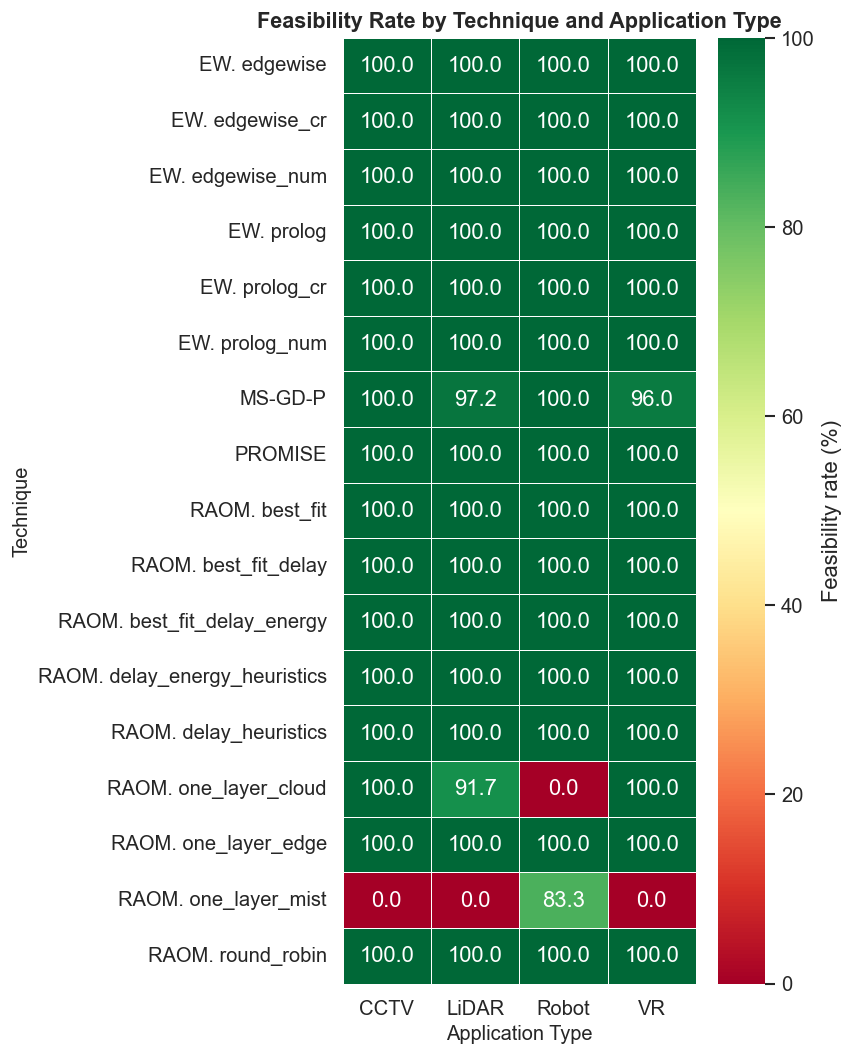

In [41]:
feas_pivot = all_data.groupby(['technique', 'app_name'])['feasible'].mean() * 100
feas_pivot = feas_pivot.unstack('app_name')
feas_pivot = feas_pivot[[APP_NAMES[a] for a in APP_ORDER]]
feas_pivot.index = [short_tech(t) for t in feas_pivot.index]
feas_pivot = feas_pivot.sort_index()

fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(feas_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Feasibility rate (%)'},
            linewidths=0.5, linecolor='white')
ax.set_title('Feasibility Rate by Technique and Application Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Application Type', fontsize=12)
ax.set_ylabel('Technique', fontsize=12)
plt.tight_layout()
plt.savefig('results/figures/feasibility_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Feasibility Bar Charts per Application

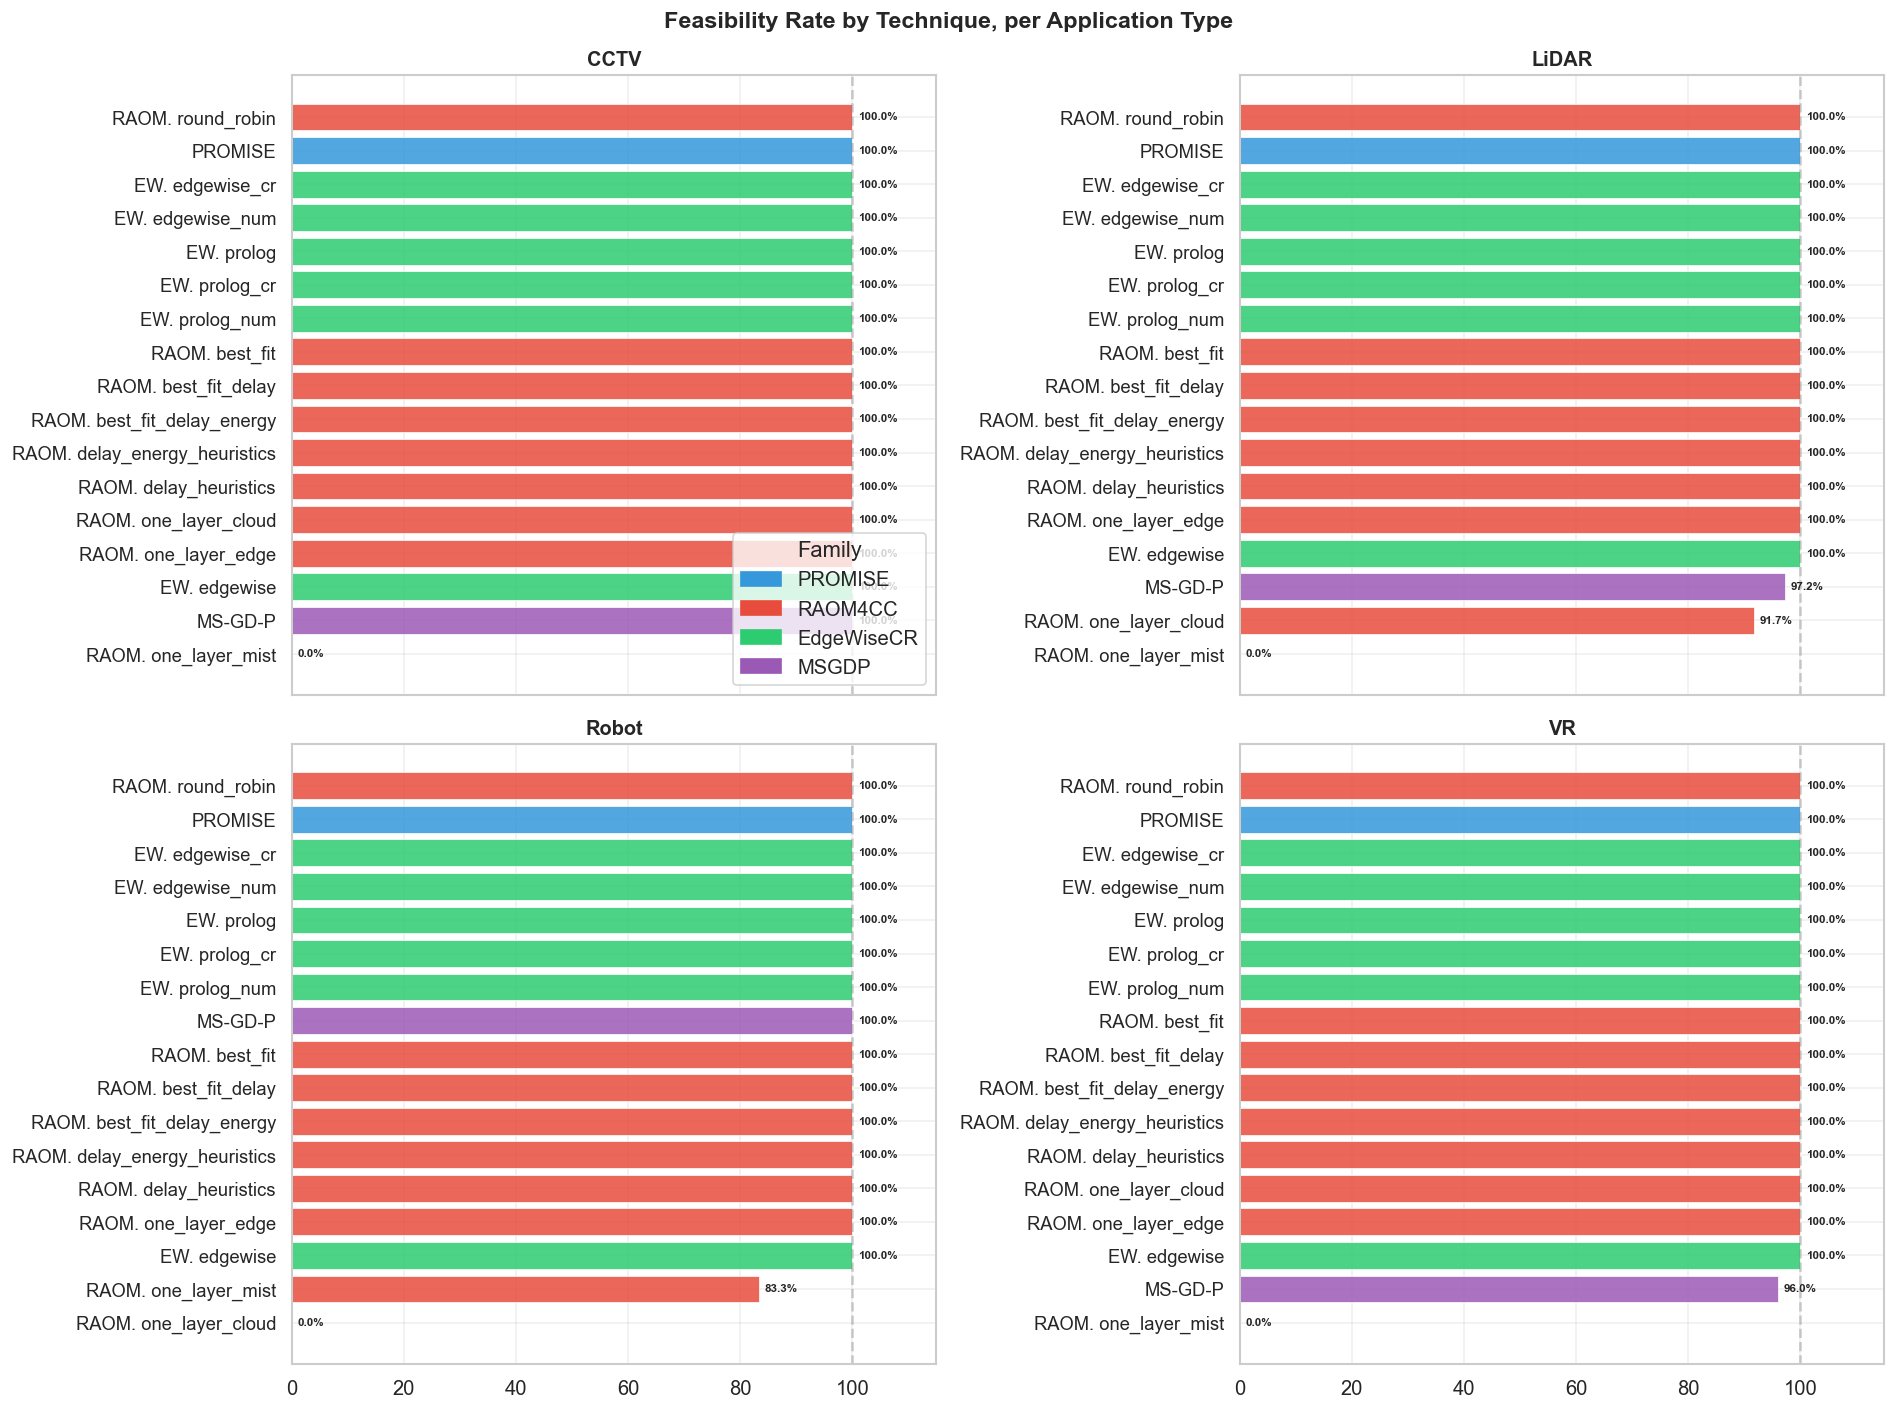

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = all_data[all_data['app'] == app]
    feas = sub.groupby('technique')['feasible'].mean().sort_values() * 100
    colors = [tech_color(t) for t in feas.index]
    ax.barh(range(len(feas)), feas.values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(feas)))
    ax.set_yticklabels([short_tech(t) for t in feas.index], fontsize=11)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    ax.axvline(100, color='grey', ls='--', alpha=0.4)
    ax.set_xlim(0, 115)
    for i, v in enumerate(feas.values):
        ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=7, fontweight='bold')
    if ax == axes[0, 0]:
        patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
        ax.legend(handles=patches, loc='lower right', title='Family')
fig.suptitle('Feasibility Rate by Technique, per Application Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/feasibility_faceted.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Feasibility under the Full Constraint Set

The feasibility rates above reflect each technique's own constraint model.
PROMISE enforces six additional hard constraints the baselines ignore, of which
two are amenable to post-hoc validation from the result CSVs: provider
co-deployment exclusions (OPTUS/TELSTRA, declared in
`config/experiment_configuration.yml`) and the device-type filter
(`devices_types_required` per application). The cell below recomputes
feasibility under three progressively stricter readings:

1. **excl.** — demand + provider exclusion only.
2. **+critical type** — adds coverage of the application's critical sensor
   type (CCTV/VR → CAMERA, LiDAR/Robot → SENSOR).
3. **+all types** — adds coverage of *all* required device types.

PROMISE retains 100 % under all three; the baselines drop sharply once
single-node solutions are required to match the device-type coverage a
multi-node PROMISE deployment provides.

In [43]:
import os

REQUIRED_DEVICE_TYPES = {
    'vr':    {'CAMERA', 'SENSOR', 'NETWORK_NODE', 'DATA_CENTER'},
    'robot': {'SENSOR', 'COMPUTER', 'NETWORK_NODE'},
    'lidar': {'SENSOR', 'NETWORK_NODE', 'DATA_CENTER'},
    'cctv':  {'CAMERA', 'NETWORK_NODE', 'DATA_CENTER'},
}
CRITICAL_DEVICE_TYPE = {'cctv': 'CAMERA', 'vr': 'CAMERA', 'lidar': 'SENSOR', 'robot': 'SENSOR'}
EXCLUSION_PAIRS = [('OPTUS', 'TELSTRA')]

_topo_cache = {}
def _provider_map(topo_id):
    if topo_id in _topo_cache: return _topo_cache[topo_id]
    p = os.path.join(TOPO_DIR, topo_id, 'devices.csv')
    m = {} if not os.path.exists(p) else dict(zip(
        pd.read_csv(p)['device_id'].astype(str), pd.read_csv(p)['provider'].astype(str)))
    _topo_cache[topo_id] = m; return m

_dtype_cache = {}
def _dtype_map(topo_id):
    if topo_id in _dtype_cache: return _dtype_cache[topo_id]
    p = os.path.join(TOPO_DIR, topo_id, 'devices.csv')
    m = {} if not os.path.exists(p) else dict(zip(
        pd.read_csv(p)['device_id'].astype(str), pd.read_csv(p)['device_type'].astype(str)))
    _dtype_cache[topo_id] = m; return m

def _parse_ids(x):
    if pd.isna(x): return []
    try: return [str(i) for i in ast.literal_eval(x)]
    except Exception: return []

def _parse_set(x):
    if pd.isna(x): return set()
    try: return set(ast.literal_eval(x))
    except Exception: return set()

def _violates_exclusion(provs):
    ps = set(provs)
    return any(a in ps and b in ps for a, b in EXCLUSION_PAIRS)

def _recheck(df, mode):
    out = []
    for _, r in df.iterrows():
        if not r['feasible']: out.append(False); continue
        ids = _parse_ids(r.get('selected_node'))
        provs = [p for p in (_provider_map(r['topology_id']).get(i, '') for i in ids) if p]
        if provs and _violates_exclusion(provs): out.append(False); continue
        if mode == 'excl': out.append(True); continue
        st = _parse_set(r['selected_features'])
        if mode == 'critical':
            out.append(CRITICAL_DEVICE_TYPE.get(r['app']) in st)
        elif mode == 'all':
            out.append(REQUIRED_DEVICE_TYPES.get(r['app'], set()).issubset(st))
        else:
            out.append(True)
    return out

raom_re = raom_raw.copy(); raom_re['technique'] = 'RAOM4CC_' + raom_re['algorithm']
raom_re['feasible'] = raom_re['feasible'].astype(str) == 'True'
raom_re['app'] = raom_re['scenario_id'].apply(lambda s: s.split('_')[2])
raom_re['selected_node'] = raom_re['selected_node']
raom_re['feas_excl']  = _recheck(raom_re, 'excl')
raom_re['feas_crit']  = _recheck(raom_re, 'critical')
raom_re['feas_all']   = _recheck(raom_re, 'all')

ew_re = ew_raw.copy(); ew_re['technique'] = 'EdgeWiseCR_' + ew_re['algorithm']
ew_re['feasible'] = ew_re['feasible'].astype(str) == 'True'
ew_re['app'] = ew_re['scenario_id'].apply(lambda s: s.split('_')[2])
ew_re['feas_excl']  = _recheck(ew_re, 'excl')
ew_re['feas_crit']  = _recheck(ew_re, 'critical')
ew_re['feas_all']   = _recheck(ew_re, 'all')

msgdp_re = msgdp_raw.copy(); msgdp_re['technique'] = 'MSGDP'
msgdp_re['feasible'] = msgdp_re['feasible'].astype(str) == 'True'
msgdp_re['app'] = msgdp_re['scenario_id'].apply(lambda s: s.split('_')[2])
msgdp_re['selected_node'] = msgdp_re['selected_nodes'].apply(
    lambda x: str([nid.split('_', 1)[1] if '_' in str(nid) else nid
                    for nid in (ast.literal_eval(x) if pd.notna(x) else [])])
    if pd.notna(x) else x)
msgdp_re['feas_excl']  = _recheck(msgdp_re, 'excl')
msgdp_re['feas_all']   = _recheck(msgdp_re, 'all')
def _msgdp_crit(r):
    if not r['feas_excl']: return False
    st = _parse_set(r['selected_features'])
    if CRITICAL_DEVICE_TYPE.get(r['app']) in st: return True
    ids = _parse_ids(r['selected_node'])
    if len(ids) <= 4:
        pm = _provider_map(r['topology_id'])
        dtm = _dtype_map(r['topology_id'])
        sel_provs = {pm.get(i, '') for i in ids}
        ct = CRITICAL_DEVICE_TYPE.get(r['app'])
        return any(dtm.get(d, '') == ct and pm.get(d, '') in sel_provs for d in pm)
    return False
msgdp_re['feas_crit']  = msgdp_re.apply(_msgdp_crit, axis=1)

prime_re = prime_raw.copy(); prime_re['technique'] = 'PROMISE'
prime_re['feasible'] = prime_re['status'] == 'COMPLETED'
prime_re['app'] = prime_re['scenario_id'].apply(lambda s: s.split('_')[2])
prime_re['feas_excl'] = prime_re['feasible']
prime_re['feas_crit'] = prime_re['feasible']
prime_re['feas_all']  = prime_re['feasible']

all_re = pd.concat([raom_re, ew_re, msgdp_re, prime_re], ignore_index=True)
all_re['app_name'] = all_re['app'].map(APP_NAMES)

overview = pd.DataFrame({
    'Excl. only':      all_re.groupby('technique')['feas_excl'].mean() * 100,
    '+ Critical type': all_re.groupby('technique')['feas_crit'].mean() * 100,
    '+ All types':     all_re.groupby('technique')['feas_all'].mean() * 100,
}).round(1).sort_index()
print('=== Overall feasibility (%) under progressively stricter constraint readings ===')
print(overview.to_string())

=== Overall feasibility (%) under progressively stricter constraint readings ===
                                 Excl. only  + Critical type  + All types
technique                                                                
EdgeWiseCR_edgewise                    26.0              3.1          2.1
EdgeWiseCR_edgewise_cr                 26.0              3.1          2.1
EdgeWiseCR_edgewise_num                40.6              9.4          0.0
EdgeWiseCR_prolog                     100.0              0.0          0.0
EdgeWiseCR_prolog_cr                  100.0              0.0          0.0
EdgeWiseCR_prolog_num                 100.0              0.0          0.0
MSGDP                                  11.4             10.1          2.1
PROMISE                               100.0            100.0        100.0
RAOM4CC_best_fit                      100.0              0.0          0.0
RAOM4CC_best_fit_delay                100.0              0.0          0.0
RAOM4CC_best_fit_delay_energy  

## 4. Execution Time Analysis

PROMISE's solver time varies by up to two orders of magnitude across application types,
whereas baseline execution times remain largely app-agnostic. We examine this divergence
through four complementary views.

### 4.1 Execution Time Distribution per Application (median + IQR)

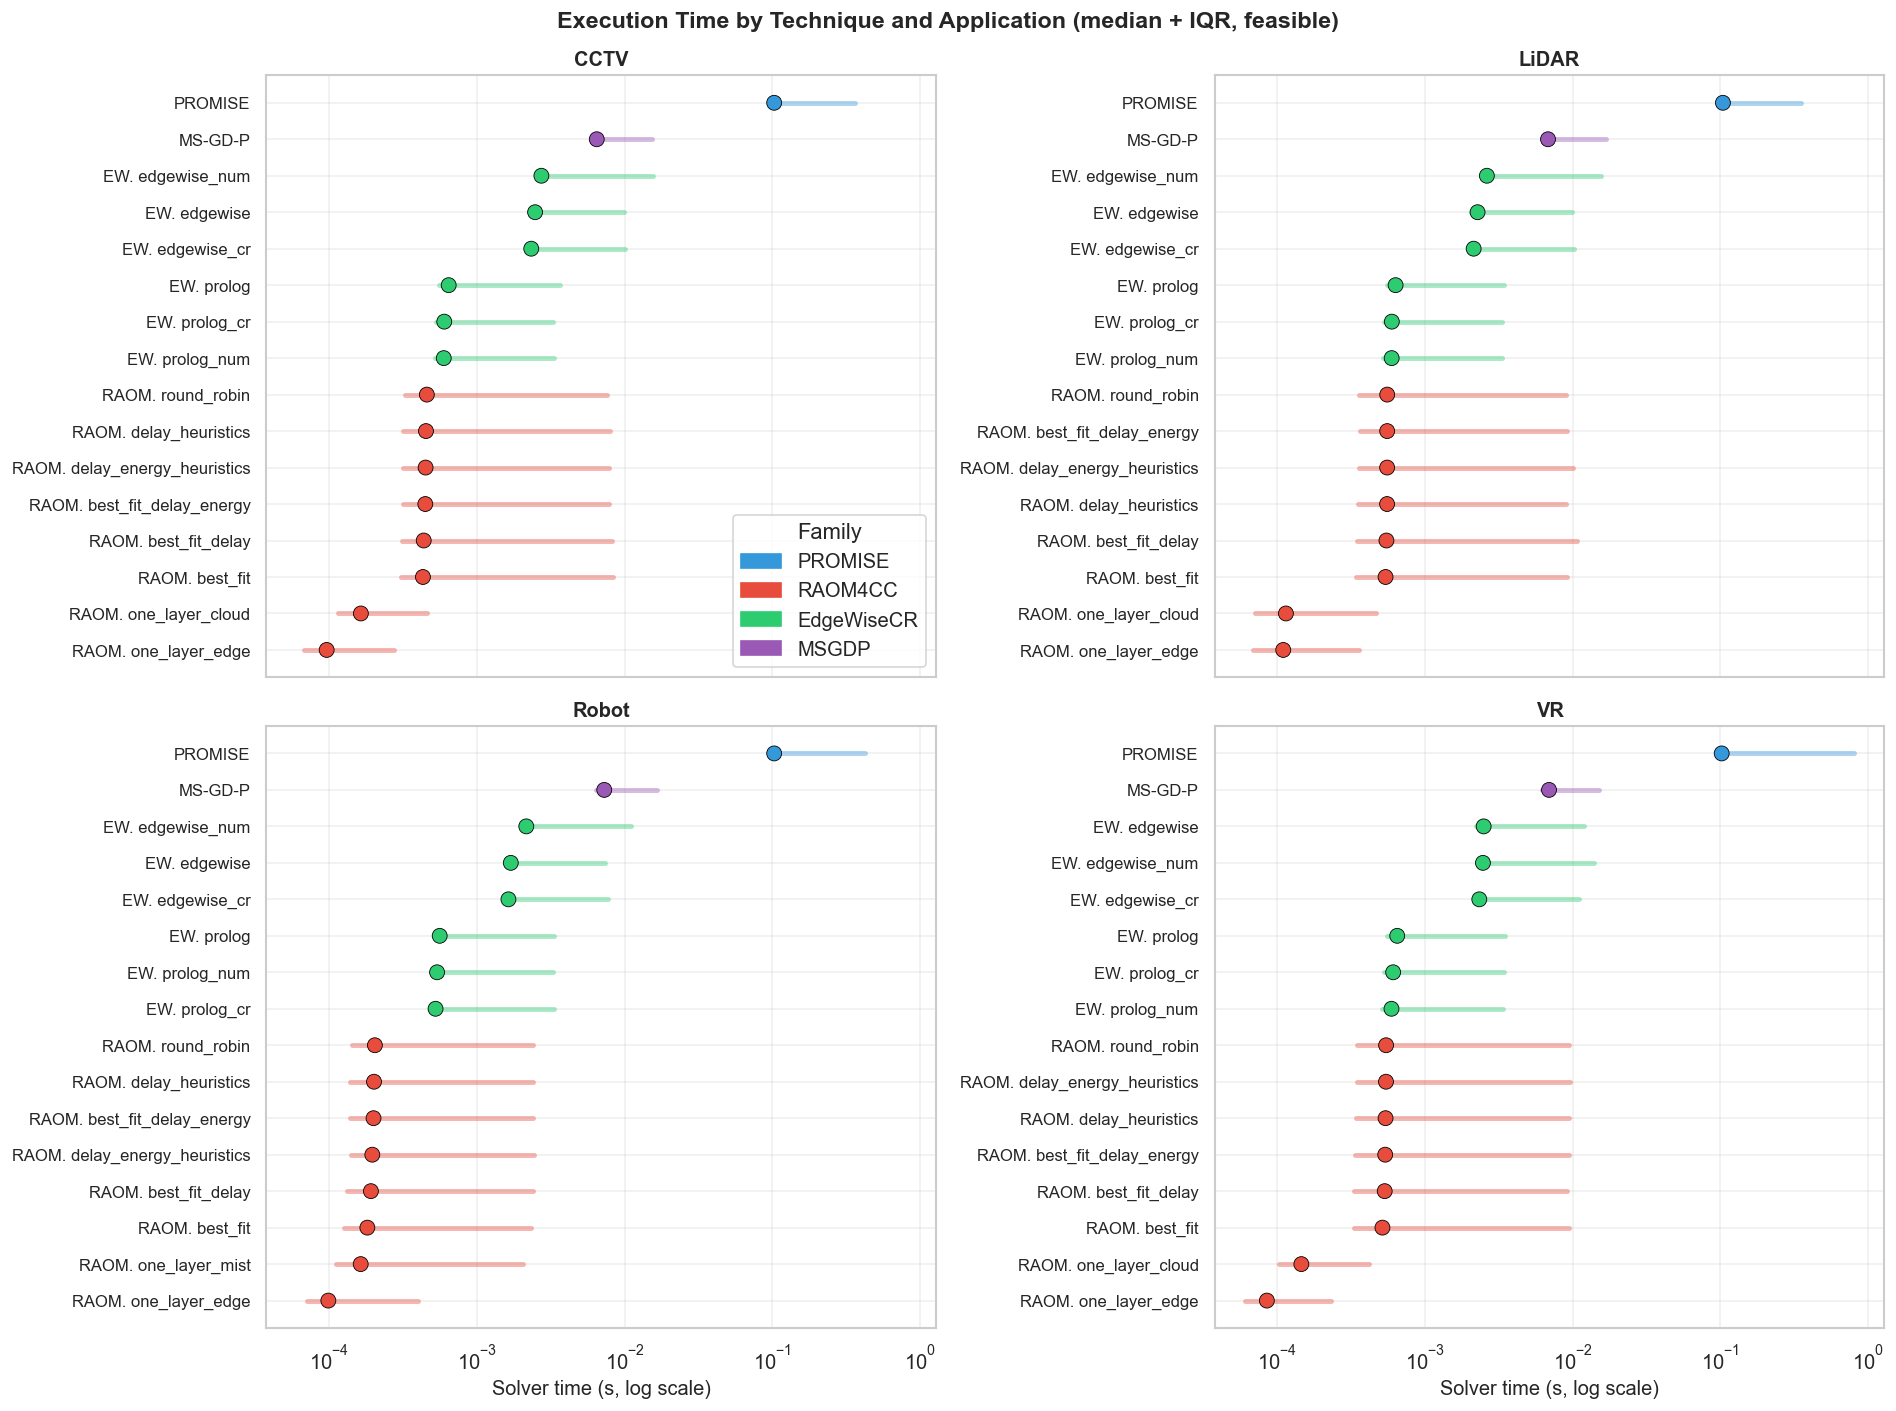

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[feasible_data['app'] == app]
    ts = sub.groupby('technique').agg(
        median=('time_s', 'median'),
        q25=('time_s', lambda x: x.quantile(0.25)),
        q75=('time_s', lambda x: x.quantile(0.75)),
    ).sort_values('median')
    colors = [tech_color(t) for t in ts.index]
    for i, (tech, row) in enumerate(ts.iterrows()):
        ax.plot([row['q25'], row['q75']], [i, i], color=colors[i], linewidth=3, alpha=0.4)
    ax.scatter(ts['median'], range(len(ts)), c=colors, s=80, zorder=5,
               edgecolors='black', linewidth=0.5)
    ax.set_yticks(range(len(ts)))
    ax.set_yticklabels([short_tech(t) for t in ts.index], fontsize=10)
    ax.set_xscale('log')
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Solver time (s, log scale)', fontsize=12)
    if ax == axes[0, 0]:
        patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
        ax.legend(handles=patches, loc='lower right', title='Family')
fig.suptitle('Execution Time by Technique and Application (median + IQR, feasible)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/time_distribution_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 PROMISE Scalability: Execution Time vs Infrastructure Size

This view corresponds to the key scalability finding: PROMISE's solver time grows at
vastly different rates depending on the application. VR is the most computationally
demanding workload (up to ~84 s at 500 nodes), while LiDAR scales best (< 1 s even
at 168 nodes).

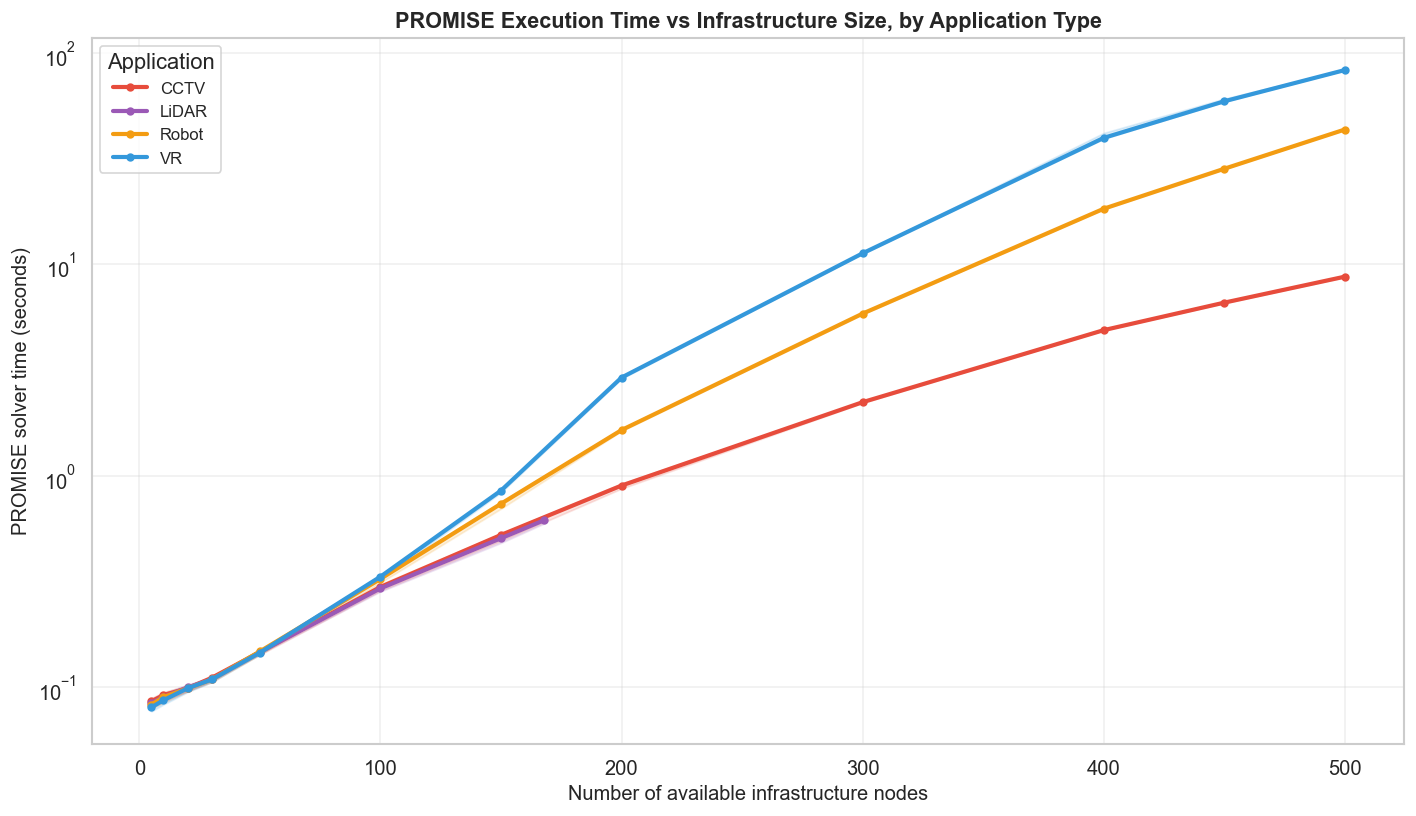

In [45]:
prime_feas = feasible_data[feasible_data['technique'] == 'PROMISE'].copy()
prime_agg = prime_feas.groupby(['app', 'num_devices']).agg(
    median_time=('time_s', 'median'),
    q25=('time_s', lambda x: x.quantile(0.25)),
    q75=('time_s', lambda x: x.quantile(0.75)),
    n=('time_s', 'count'),
).reset_index()
# Filter out bins with too few data points
prime_agg = prime_agg[prime_agg['n'] >= 3]

fig, ax = plt.subplots(figsize=(12, 7))
for app in APP_ORDER:
    subset = prime_agg[prime_agg['app'] == app].sort_values('num_devices')
    c = APP_COLORS[app]
    ax.fill_between(subset['num_devices'], subset['q25'], subset['q75'],
                    alpha=0.15, color=c)
    ax.plot(subset['num_devices'], subset['median_time'],
            marker='o', markersize=4, linewidth=2.5, color=c, label=APP_NAMES[app])

ax.set_xlabel('Number of available infrastructure nodes', fontsize=12)
ax.set_ylabel('PROMISE solver time (seconds)', fontsize=12)
ax.set_yscale('log')
ax.set_title('PROMISE Execution Time vs Infrastructure Size, by Application Type',
             fontsize=13, fontweight='bold')
ax.legend(title='Application', fontsize=10)
plt.tight_layout()
plt.savefig('results/figures/prime_time_vs_devices_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 All Techniques: Time vs Infrastructure Size per Application

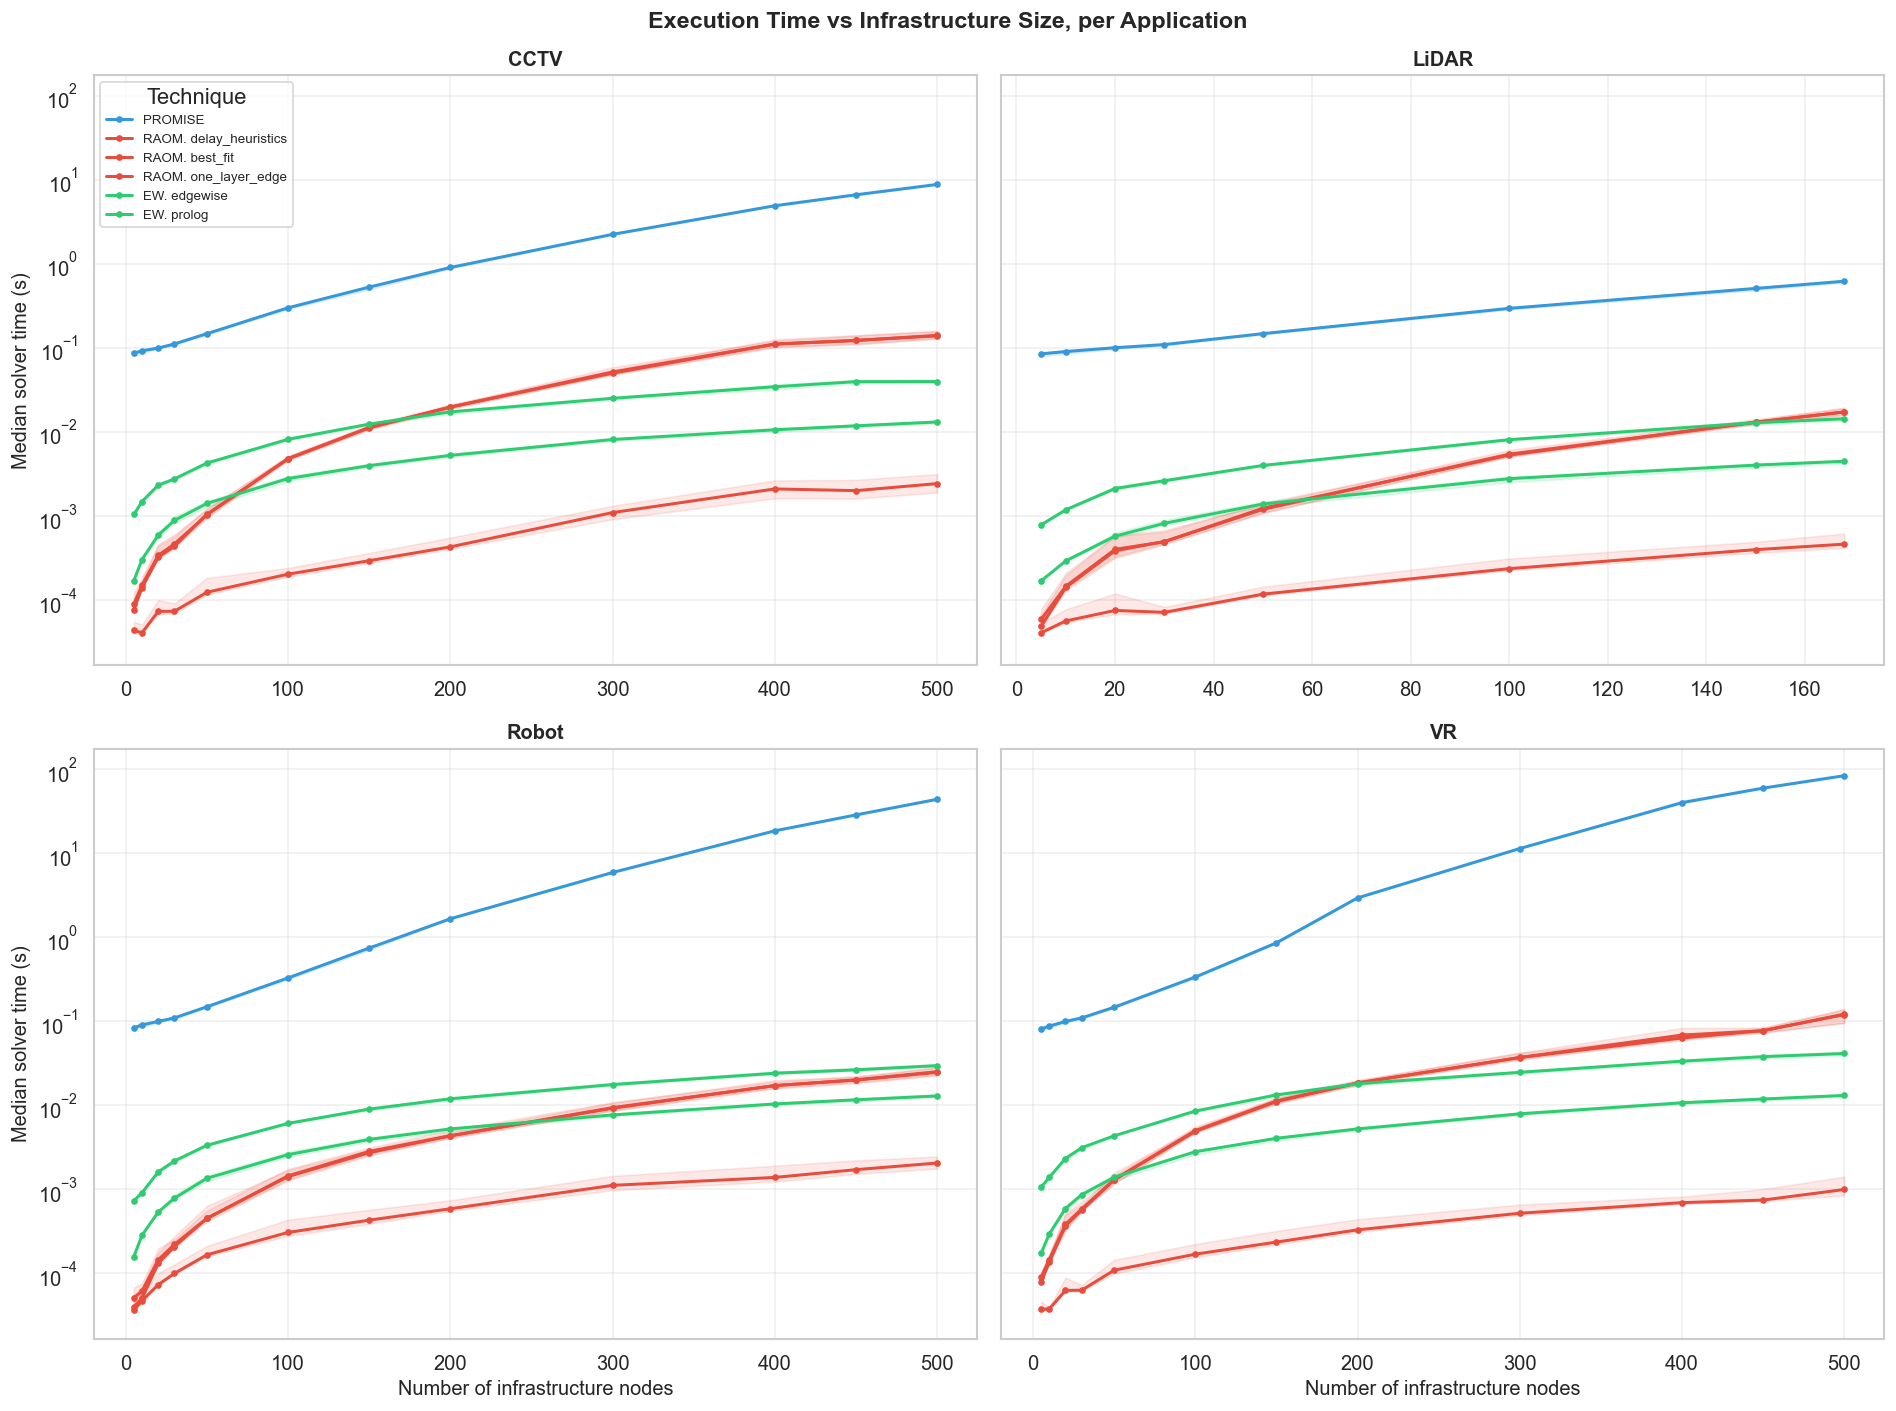

In [46]:
key_techs = ['PROMISE', 'RAOM4CC_delay_heuristics', 'RAOM4CC_best_fit',
             'RAOM4CC_one_layer_edge', 'EdgeWiseCR_edgewise', 'EdgeWiseCR_prolog']

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[(feasible_data['app'] == app) &
                        (feasible_data['technique'].isin(key_techs))]
    agg = sub.groupby(['technique', 'num_devices']).agg(
        median_time=('time_s', 'median'),
        q25=('time_s', lambda x: x.quantile(0.25)),
        q75=('time_s', lambda x: x.quantile(0.75)),
        n=('time_s', 'count'),
    ).reset_index()
    agg = agg[agg['n'] >= 3]
    for tech in key_techs:
        subset = agg[agg['technique'] == tech].sort_values('num_devices')
        if len(subset) == 0:
            continue
        c = tech_color(tech)
        ax.fill_between(subset['num_devices'], subset['q25'], subset['q75'],
                        alpha=0.12, color=c)
        ax.plot(subset['num_devices'], subset['median_time'],
                marker='o', markersize=3, linewidth=1.8, color=c,
                label=short_tech(tech))
    ax.set_yscale('log')
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Number of infrastructure nodes', fontsize=12)
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Median solver time (s)', fontsize=12)
    if ax == axes[0, 0]:
        ax.legend(title='Technique', fontsize=8, loc='upper left')
fig.suptitle('Execution Time vs Infrastructure Size, per Application',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/time_vs_devices_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Statistical Tests per Application Type

In [47]:
print('Kruskal-Wallis (all techniques, per app):')
print(f'{"App":<10s} {"H stat":>10s} {"p-value":>14s}')
print('-' * 36)
for app in APP_ORDER:
    sub = feasible_data[feasible_data['app'] == app]
    groups = [g['time_s'].values for _, g in sub.groupby('technique')]
    kw_stat, kw_p = stats.kruskal(*groups)
    print(f'{APP_NAMES[app]:<10s} {kw_stat:>10.2f} {kw_p:>14.2e}')

print(f'\nPairwise Mann-Whitney U (PROMISE vs each baseline, per app):')
for app in APP_ORDER:
    sub = feasible_data[feasible_data['app'] == app]
    prime_times = sub[sub['technique'] == 'PROMISE']['time_s'].values
    print(f'\n--- {APP_NAMES[app]} ---')
    print(f'{"Baseline":<35s} {"U":>10s} {"p":>12s} {"r":>8s}')
    print('-' * 67)
    for tech in sorted(sub['technique'].unique()):
        if tech == 'PROMISE':
            continue
        tt = sub[sub['technique'] == tech]['time_s'].values
        if len(tt) == 0:
            print(f'{tech:<35s} {"N/A":>10s}')
            continue
        u, p = stats.mannwhitneyu(prime_times, tt, alternative='two-sided')
        z = stats.norm.ppf(1 - p / 2)
        r = abs(z) / np.sqrt(len(prime_times) + len(tt))
        print(f'{tech:<35s} {u:>10.0f} {p:>12.2e} {r:>8.3f}')

Kruskal-Wallis (all techniques, per app):
App            H stat        p-value
------------------------------------
CCTV         16746.51       0.00e+00
LiDAR        19114.85       0.00e+00
Robot        17484.58       0.00e+00
VR           17953.80       0.00e+00

Pairwise Mann-Whitney U (PROMISE vs each baseline, per app):

--- CCTV ---
Baseline                                     U            p        r
-------------------------------------------------------------------
EdgeWiseCR_edgewise                    5760000     0.00e+00      inf
EdgeWiseCR_edgewise_cr                 5760000     0.00e+00      inf
EdgeWiseCR_edgewise_num                5760000     0.00e+00      inf
EdgeWiseCR_prolog                      5760000     0.00e+00      inf
EdgeWiseCR_prolog_cr                   5760000     0.00e+00      inf
EdgeWiseCR_prolog_num                  5760000     0.00e+00      inf
MSGDP                                  5749007     0.00e+00      inf
RAOM4CC_best_fit                       5

### 4.5 Execution Time by Scenario Scale, per Application

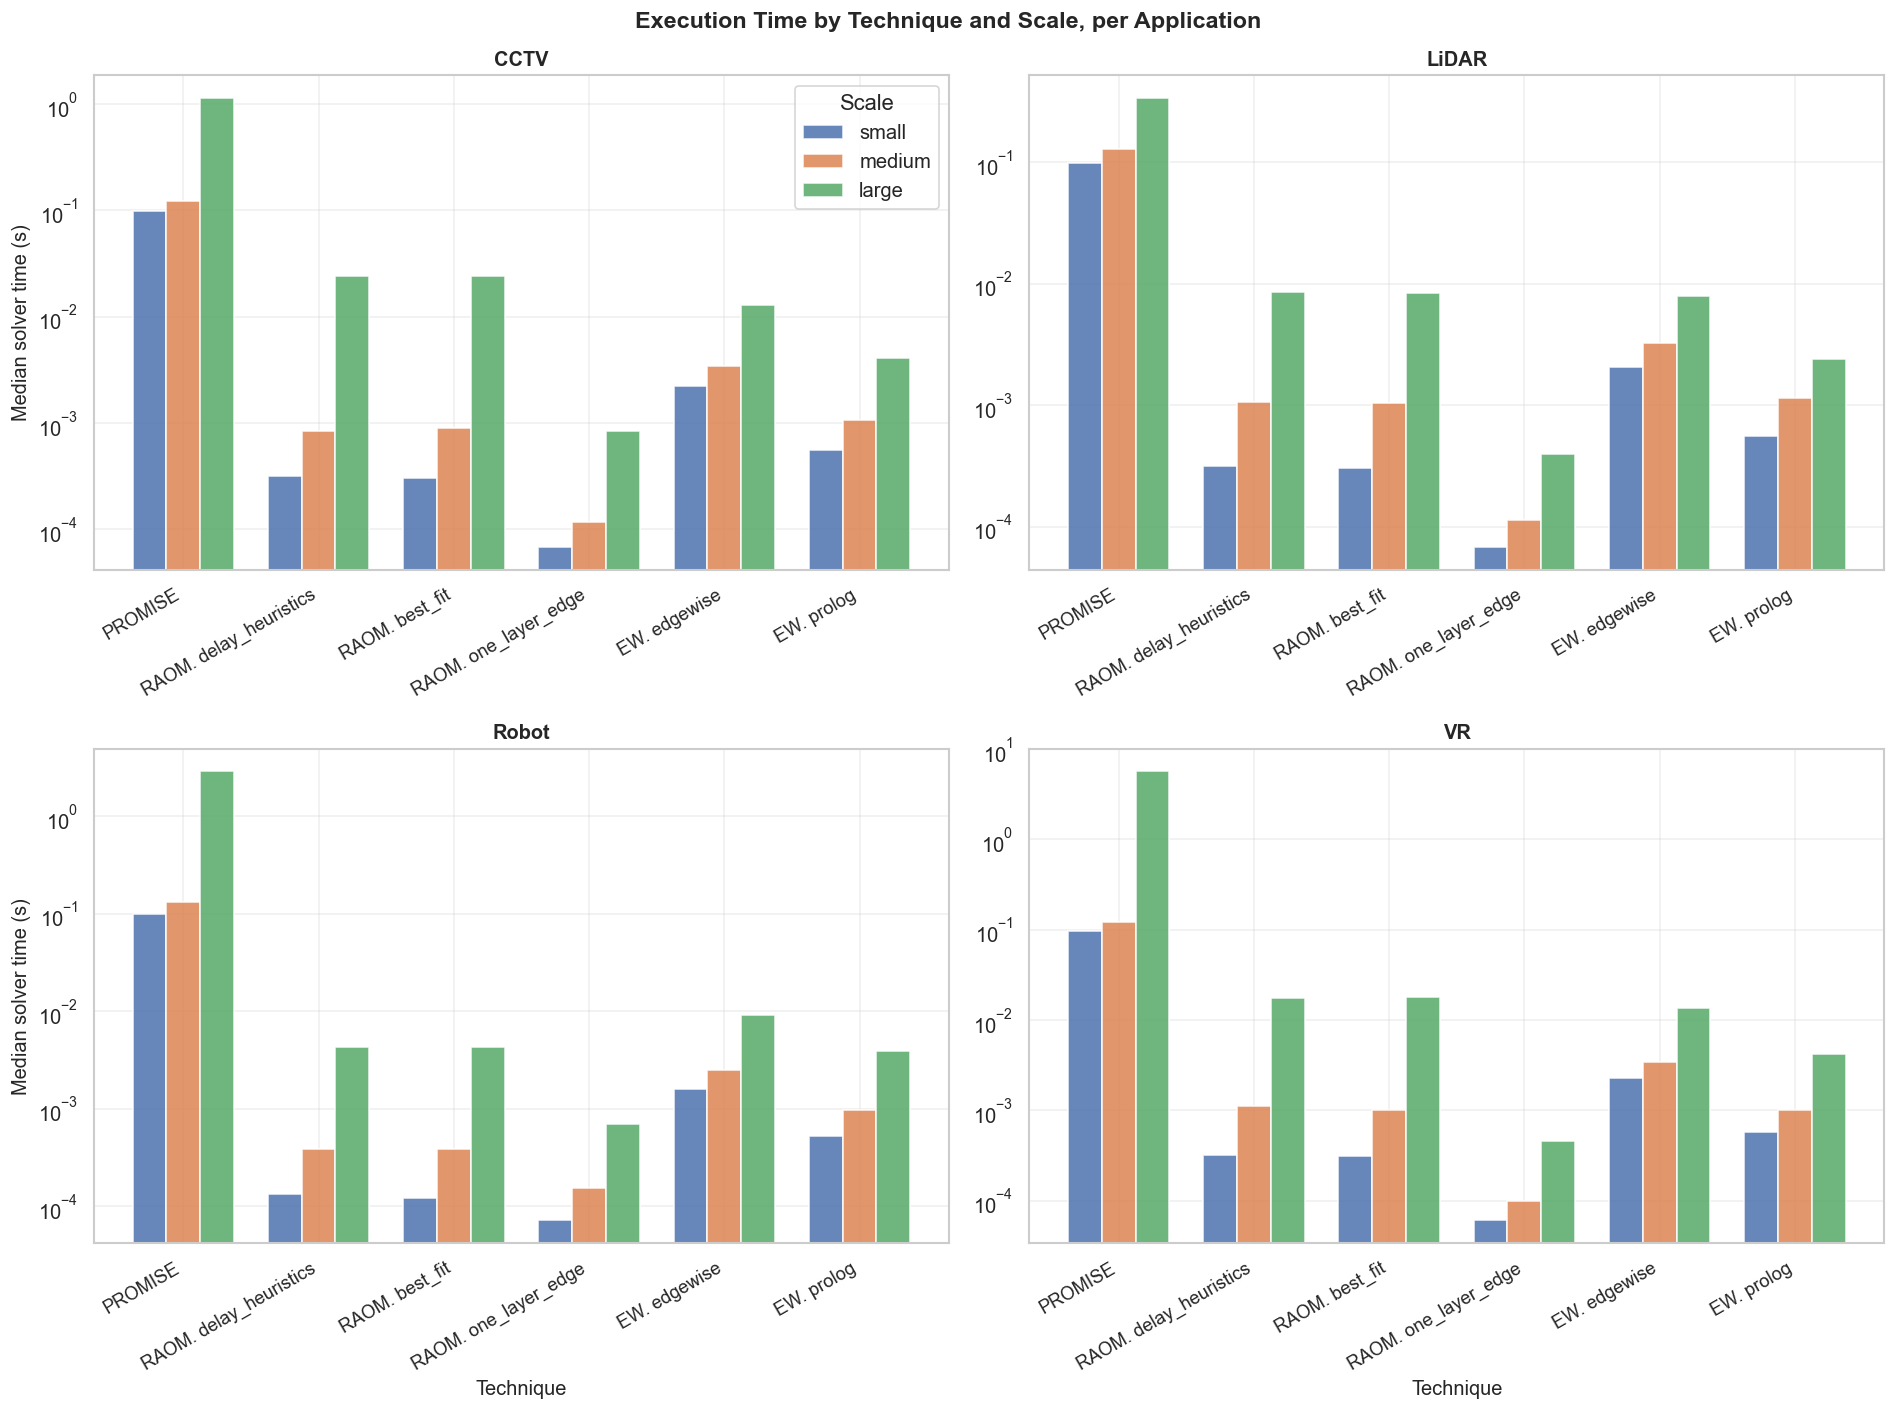

In [48]:
scale_order = ['small', 'medium', 'large']
key_techs_scale = ['PROMISE', 'RAOM4CC_delay_heuristics', 'RAOM4CC_best_fit',
                   'RAOM4CC_one_layer_edge', 'EdgeWiseCR_edgewise', 'EdgeWiseCR_prolog']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[(feasible_data['app'] == app) &
                        (feasible_data['technique'].isin(key_techs_scale))]
    st = sub.groupby(['technique', 'scale'])['time_s'].median().unstack('scale')
    st = st.reindex(columns=scale_order)
    st = st.loc[[t for t in key_techs_scale if t in st.index]]
    x = np.arange(len(st))
    width = 0.25
    for i, scale in enumerate(scale_order):
        ax.bar(x + i * width, st[scale].values, width, label=scale, alpha=0.85, edgecolor='white')
    ax.set_xticks(x + width)
    ax.set_xticklabels([short_tech(t) for t in st.index], rotation=30, ha='right', fontsize=11)
    ax.set_yscale('log')
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Technique', fontsize=12)
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Median solver time (s)', fontsize=12)
    if ax == axes[0, 0]:
        ax.legend(title='Scale')
fig.suptitle('Execution Time by Technique and Scale, per Application',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/time_by_scale_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Node Selection Analysis

The number of nodes selected by each technique varies modestly by application type.
PROMISE and EdgeWiseCR MILP select more nodes for VR and CCTV (higher resource demands),
while greedy heuristics consistently select a single node regardless of workload.

### 5.1 Median Node Count Heatmap (Technique × Application)

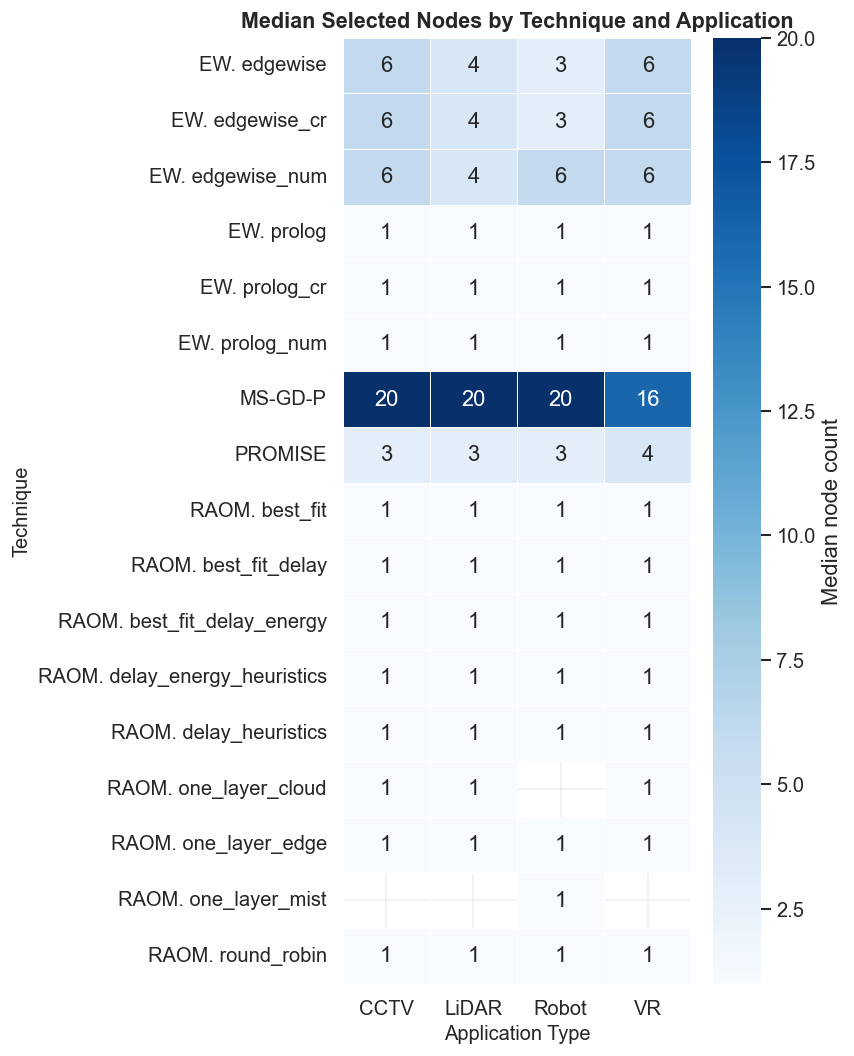

In [49]:
nodes_pivot = (feasible_data.groupby(['technique', 'app_name'])['nodes'].median()
               .unstack('app_name'))
nodes_pivot = nodes_pivot[[APP_NAMES[a] for a in APP_ORDER]]
nodes_pivot.index = [short_tech(t) for t in nodes_pivot.index]
nodes_pivot = nodes_pivot.sort_index()

fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(nodes_pivot, annot=True, fmt='.0f', cmap='Blues',
            ax=ax, cbar_kws={'label': 'Median node count'},
            linewidths=0.5, linecolor='white')
ax.set_title('Median Selected Nodes by Technique and Application', fontsize=13, fontweight='bold')
ax.set_xlabel('Application Type', fontsize=12)
ax.set_ylabel('Technique', fontsize=12)
plt.tight_layout()
plt.savefig('results/figures/nodes_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Node Count Distribution per Application (median + IQR)

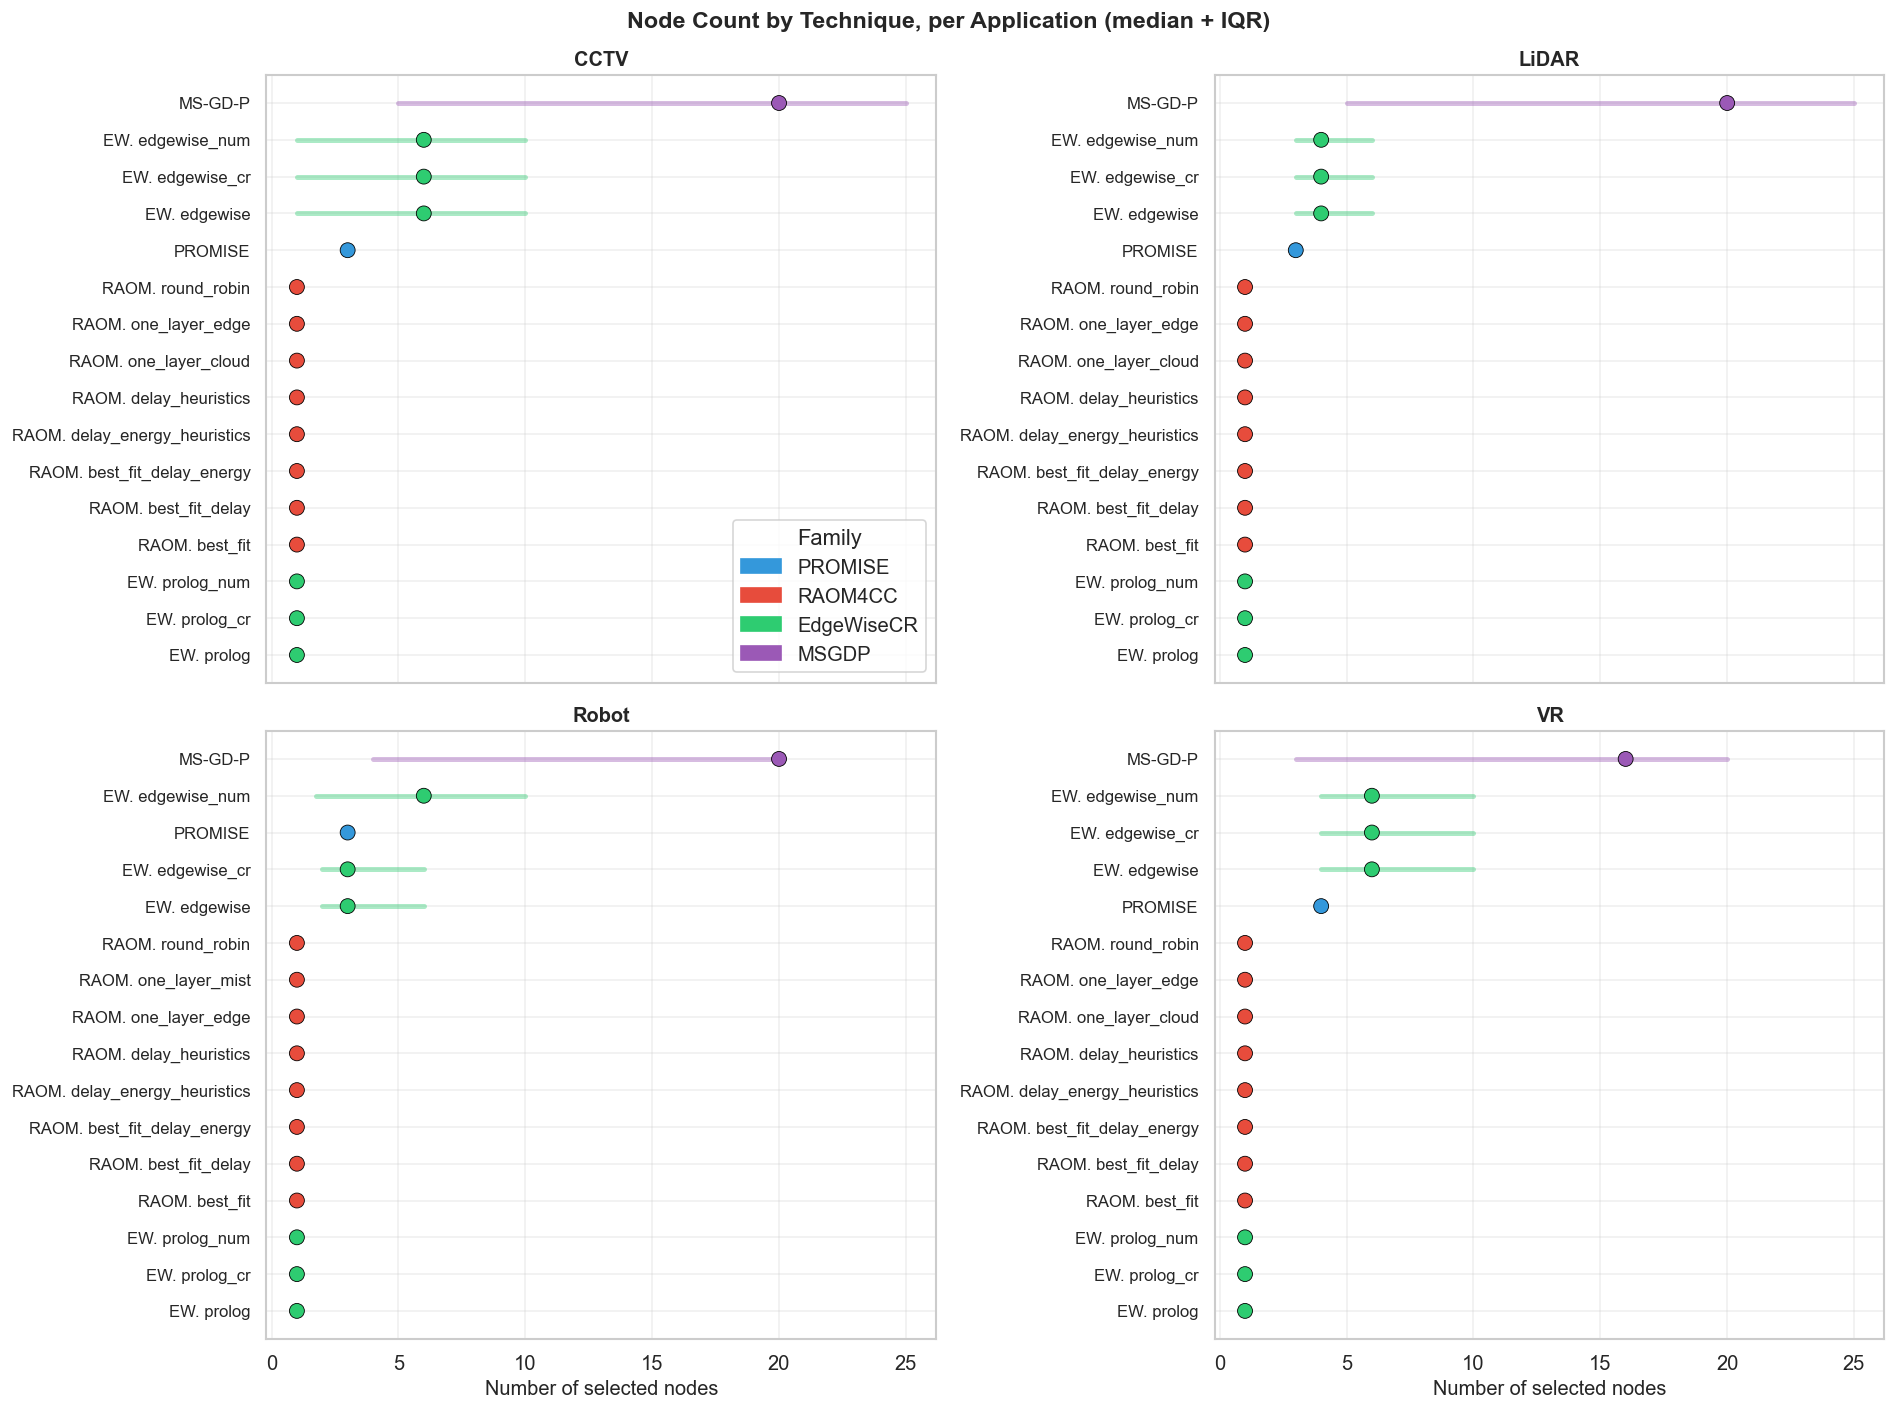

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[feasible_data['app'] == app]
    ns = sub.groupby('technique').agg(
        median=('nodes', 'median'),
        q25=('nodes', lambda x: x.quantile(0.25)),
        q75=('nodes', lambda x: x.quantile(0.75)),
    ).sort_values('median')
    colors = [tech_color(t) for t in ns.index]
    for i, (tech, row) in enumerate(ns.iterrows()):
        ax.plot([row['q25'], row['q75']], [i, i], color=colors[i], linewidth=3, alpha=0.4)
    ax.scatter(ns['median'], range(len(ns)), c=colors, s=80, zorder=5,
               edgecolors='black', linewidth=0.5)
    ax.set_yticks(range(len(ns)))
    ax.set_yticklabels([short_tech(t) for t in ns.index], fontsize=10)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Number of selected nodes', fontsize=12)
    if ax == axes[0, 0]:
        patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
        ax.legend(handles=patches, loc='lower right', title='Family')
fig.suptitle('Node Count by Technique, per Application (median + IQR)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/nodes_distribution_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cost Analysis

The raw cost figures are not directly comparable across techniques because the baselines
ignore 6 of 12 hard constraint types. We report them here to expose the structural
mechanism by which the baselines achieve their apparent cost advantage: constraint
relaxation, single-node selection, and a simplified pricing model.


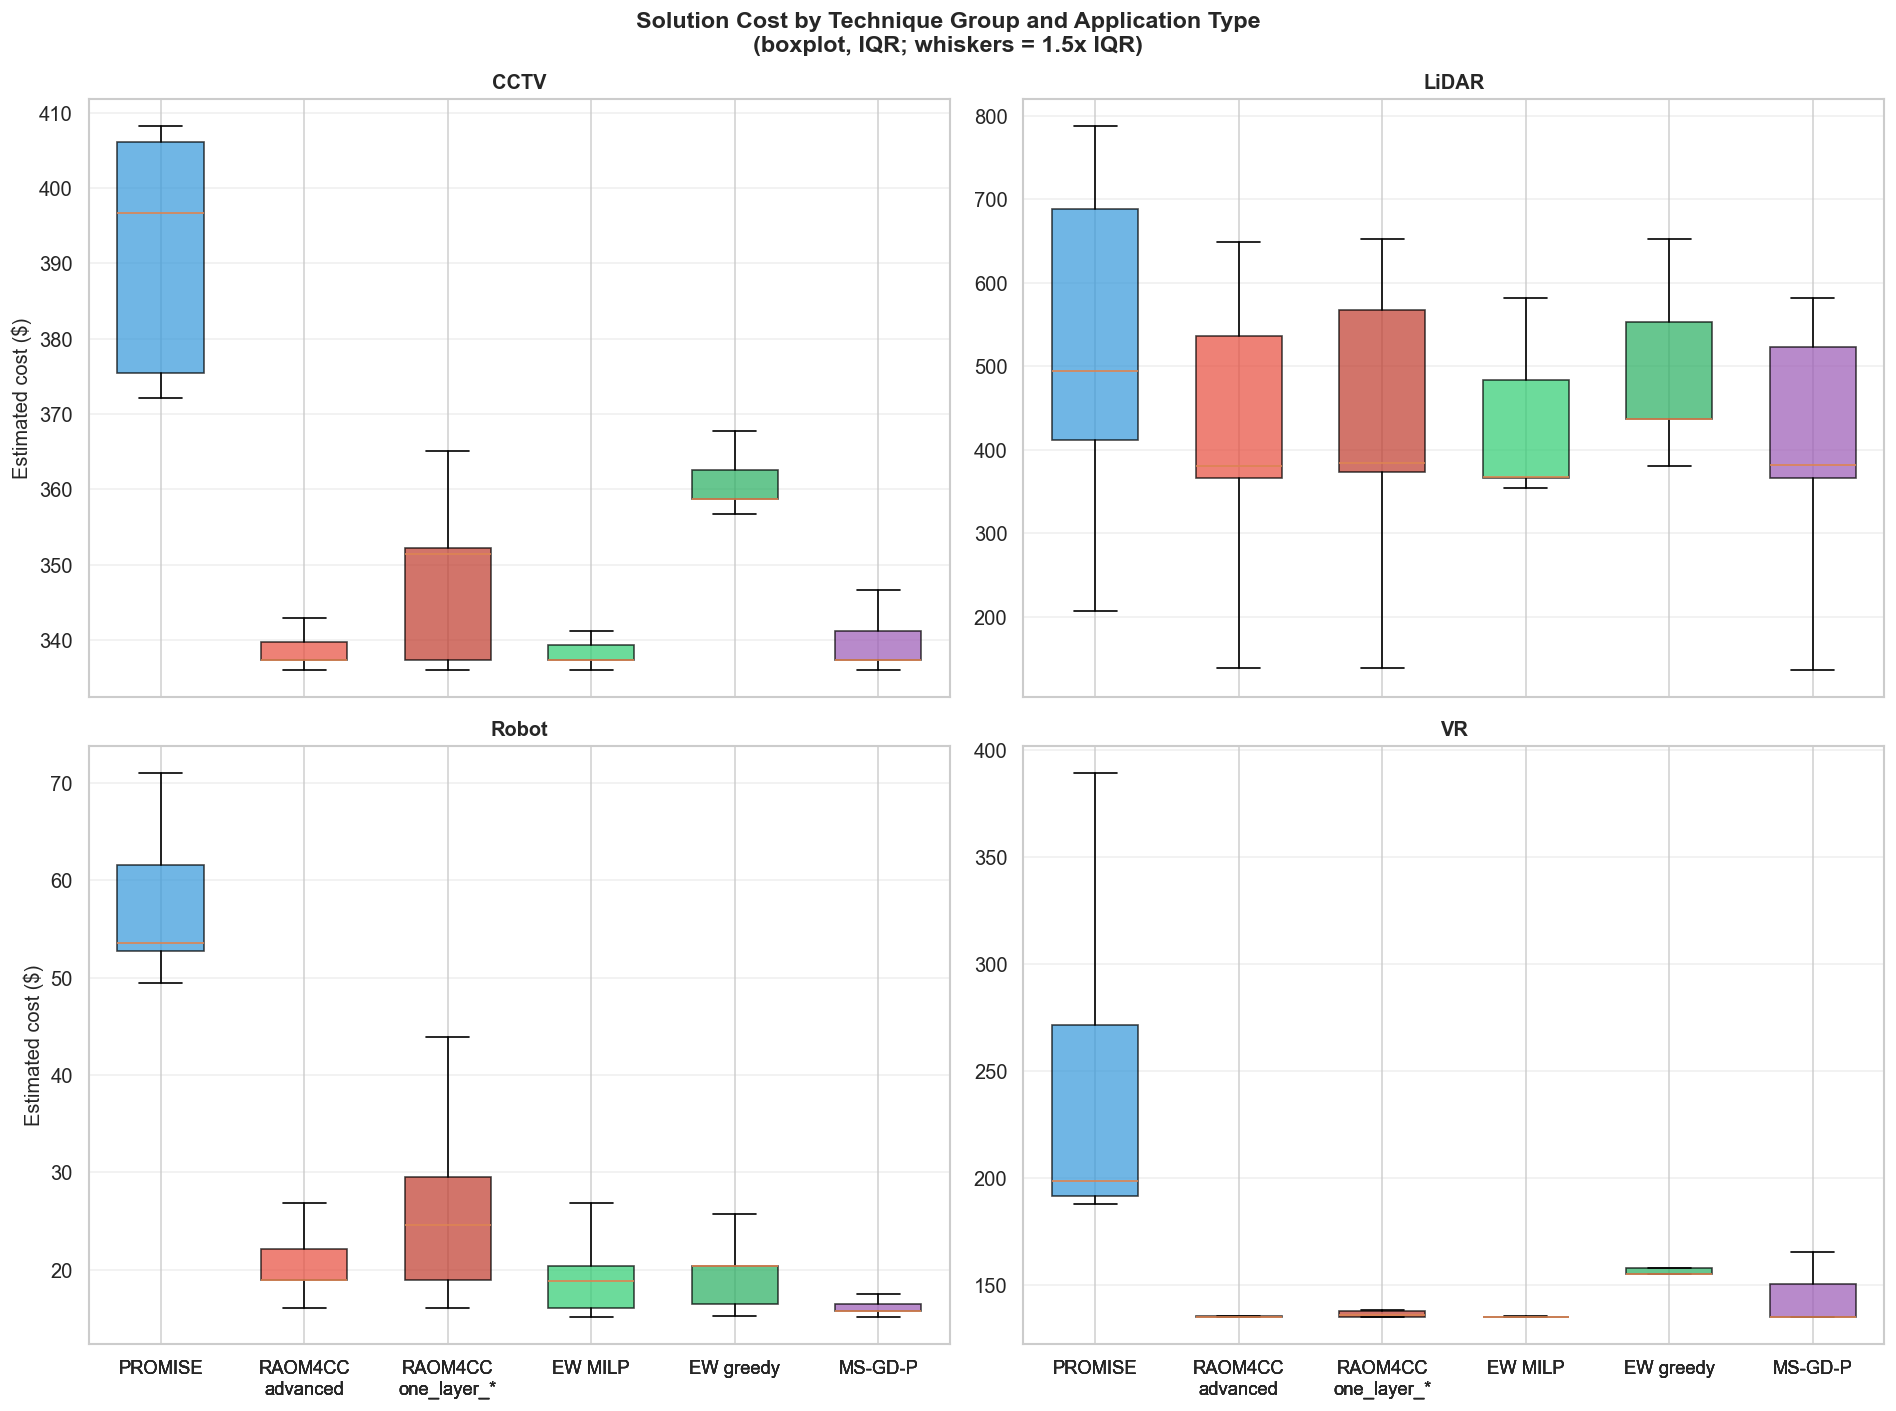

Median cost ($) by group and app:
                       CCTV   LiDAR  Robot      VR
group                                             
PROMISE              396.67  493.91  53.62  198.70
RAOM4CC advanced     337.35  381.20  18.90  135.15
RAOM4CC one_layer_*  351.38  384.56  24.57  136.20
EdgeWiseCR MILP      337.35  367.31  18.87  135.15
EdgeWiseCR greedy    358.78  437.31  20.43  155.26
MS-GD-P              337.35  382.26  15.75  135.25


In [51]:
# --- Build unified cost dataframe ---
prime_raw['cost_num'] = prime_raw['cost'].astype(str).str.replace(' $', '').astype(float)
raom_raw['cost_num'] = raom_raw['estimated_cost'].astype(float)
ew_raw['cost_num'] = ew_raw['estimated_cost'].astype(float)
msgdp_raw['cost_num'] = msgdp_raw['estimated_cost'].astype(float)

def raom_cost_group(alg):
    if 'one_layer' in alg: return 'RAOM4CC one_layer_*'
    return 'RAOM4CC advanced'
def ew_cost_group(alg):
    if 'prolog' in alg: return 'EdgeWiseCR greedy'
    return 'EdgeWiseCR MILP'

rows = []
for _, r in prime_raw[prime_raw['status'] == 'COMPLETED'].iterrows():
    rows.append({'app': r['scenario_id'].split('_')[2], 'group': 'PROMISE',
                 'cost': r['cost_num'],
                 'nodes': len(ast.literal_eval(r['add_ons'])) if pd.notna(r['add_ons']) else 0})
for _, r in raom_raw[raom_raw['feasible'].astype(str) == 'True'].iterrows():
    rows.append({'app': r['scenario_id'].split('_')[2], 'group': raom_cost_group(r['algorithm']),
                 'cost': r['cost_num'],
                 'nodes': len(ast.literal_eval(r['selected_node'])) if pd.notna(r['selected_node']) else 0})
for _, r in ew_raw[ew_raw['feasible'].astype(str) == 'True'].iterrows():
    rows.append({'app': r['scenario_id'].split('_')[2], 'group': ew_cost_group(r['algorithm']),
                 'cost': r['cost_num'], 'nodes': r['bins']})

for _, r in msgdp_raw[msgdp_raw['feasible'].astype(str) == 'True'].iterrows():
    rows.append({'app': r['scenario_id'].split('_')[2], 'group': 'MS-GD-P',
                 'cost': r['cost_num'],
                 'nodes': len(ast.literal_eval(r['selected_nodes'])) if pd.notna(r['selected_nodes']) else 0})

cost_df = pd.DataFrame(rows)
GROUP_ORDER = ['PROMISE', 'RAOM4CC advanced', 'RAOM4CC one_layer_*',
               'EdgeWiseCR MILP', 'EdgeWiseCR greedy', 'MS-GD-P']
GROUP_COLORS = {'PROMISE': '#3498db', 'RAOM4CC advanced': '#e74c3c',
                'RAOM4CC one_layer_*': '#c0392b',
                'EdgeWiseCR MILP': '#2ecc71', 'EdgeWiseCR greedy': '#27ae60',
                'MS-GD-P': '#9b59b6'}
GROUP_LABELS = ['PROMISE', 'RAOM4CC\nadvanced', 'RAOM4CC\none_layer_*',
                'EW MILP', 'EW greedy', 'MS-GD-P']

# Boxplot: cost by group, faceted by app
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = cost_df[cost_df['app'] == app]
    box_data = [sub[sub['group'] == g]['cost'].values for g in GROUP_ORDER]
    bp = ax.boxplot(box_data, tick_labels=GROUP_LABELS,
                    patch_artist=True, showfliers=False, widths=0.6)
    for patch, g in zip(bp['boxes'], GROUP_ORDER):
        patch.set_facecolor(GROUP_COLORS[g])
        patch.set_alpha(0.7)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Estimated cost ($)', fontsize=12)
    ax.tick_params(axis='x', labelsize=11)
fig.suptitle('Solution Cost by Technique Group and Application Type\n(boxplot, IQR; whiskers = 1.5x IQR)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/cost_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

# Print median cost table
med = cost_df.groupby(['group', 'app'])['cost'].median().unstack('app')
med = med.reindex(index=GROUP_ORDER)[APP_ORDER]
med.columns = [APP_NAMES[a] for a in APP_ORDER]
print('Median cost ($) by group and app:')
print(med.round(2).to_string())


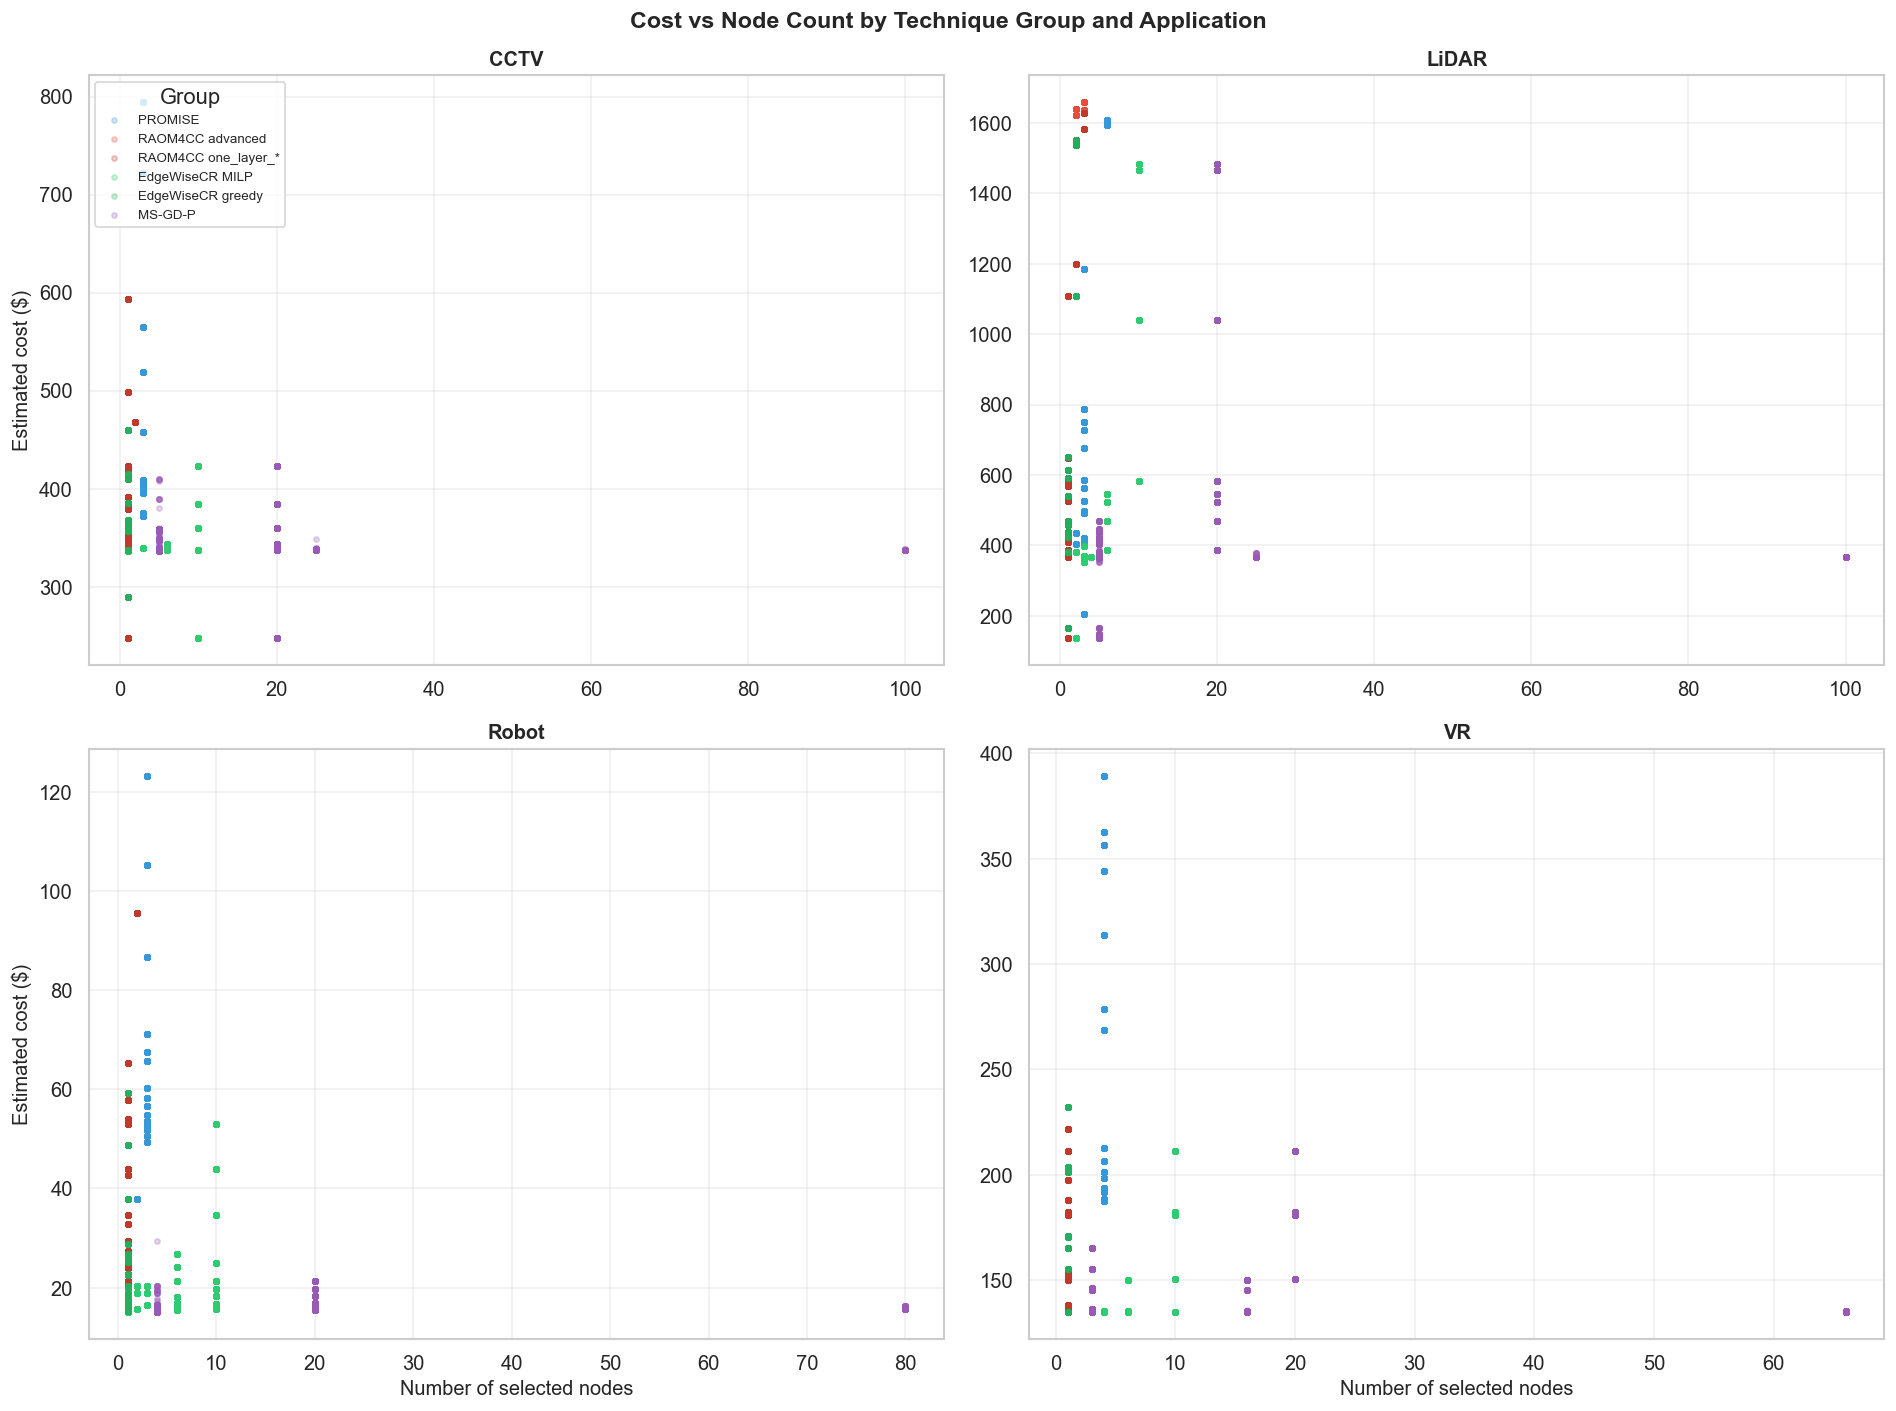

In [52]:
# Cost vs node count scatter, faceted by app
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, app in zip(axes.flat, APP_ORDER):
    sub = cost_df[cost_df['app'] == app]
    for g in GROUP_ORDER:
        gsub = sub[sub['group'] == g]
        if len(gsub) == 0:
            continue
        ax.scatter(gsub['nodes'], gsub['cost'], c=GROUP_COLORS[g], alpha=0.25, s=10, label=g)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Number of selected nodes', fontsize=12)
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Estimated cost ($)', fontsize=12)
    if ax == axes[0, 0]:
        ax.legend(title='Group', fontsize=8, loc='upper left')
fig.suptitle('Cost vs Node Count by Technique Group and Application',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/cost_vs_nodes_by_app.png', dpi=150, bbox_inches='tight')
plt.show()


In [53]:
# Cost comparability analysis
print('=' * 80)
print('COST ANALYSIS SUMMARY')
print('=' * 80)
print()
print('PROMISE reports the highest median cost on every application because it enforces')
print('12 hard constraint types (vs 6 in baselines) and selects 3-4 nodes (vs 1 in')
print('single-node baselines). The cost difference is the price of deployability.')
print()
print('Median cost ratio (baseline / PROMISE):')
for app in APP_ORDER:
    p_cost = cost_df[(cost_df['app'] == app) & (cost_df['group'] == 'PROMISE')]['cost'].median()
    sn = cost_df[(cost_df['app'] == app) & (cost_df['group'].isin(['RAOM4CC advanced', 'EdgeWiseCR greedy']))]['cost'].median()
    print(f'  {APP_NAMES[app]:<8s}: single-node baselines = {sn/p_cost:.1%} of PROMISE cost')
print()
print('Conclusion: costs are NOT comparable. Baselines solve a relaxed problem.')
print('PROMISE\'s higher cost reflects the true cost of a deployable solution.')


COST ANALYSIS SUMMARY

PROMISE reports the highest median cost on every application because it enforces
12 hard constraint types (vs 6 in baselines) and selects 3-4 nodes (vs 1 in
single-node baselines). The cost difference is the price of deployability.

Median cost ratio (baseline / PROMISE):
  CCTV    : single-node baselines = 85.3% of PROMISE cost
  LiDAR   : single-node baselines = 83.6% of PROMISE cost
  Robot   : single-node baselines = 35.2% of PROMISE cost
  VR      : single-node baselines = 68.1% of PROMISE cost

Conclusion: costs are NOT comparable. Baselines solve a relaxed problem.
PROMISE's higher cost reflects the true cost of a deployable solution.


## 7. Key Findings by Application Type

In [54]:
print('=' * 90)
print('KEY FINDINGS BY APPLICATION TYPE')
print('=' * 90)

for app in APP_ORDER:
    sub_all = all_data[all_data['app'] == app]
    sub_feas = feasible_data[feasible_data['app'] == app]
    print(f'\n--- {APP_NAMES[app]} ---')

    # Feasibility
    feas_rates = sub_all.groupby('technique')['feasible'].mean() * 100
    perfect = feas_rates[feas_rates == 100].index.tolist()
    failed = feas_rates[feas_rates == 0].index.tolist()
    partial = feas_rates[(feas_rates > 0) & (feas_rates < 100)]
    print(f'  100% feasibility: {len(perfect)}/{len(feas_rates)} techniques')
    if failed:
        print(f'  0% feasibility: {failed}')
    if len(partial) > 0:
        for t, v in partial.sort_values().items():
            print(f'  Partial: {t} = {v:.1f}%')

    # PROMISE time
    prime_t = sub_feas[sub_feas['technique'] == 'PROMISE']['time_s']
    print(f'  PROMISE time: median={prime_t.median():.3f}s, max={prime_t.max():.2f}s')
    prime_large = sub_feas[(sub_feas['technique'] == 'PROMISE') & (sub_feas['scale'] == 'large')]['time_s']
    if len(prime_large) > 0:
        print(f'  PROMISE large-scale: median={prime_large.median():.3f}s, max={prime_large.max():.2f}s')

    # Fastest baseline
    base_t = sub_feas[sub_feas['technique'] != 'PROMISE'].groupby('technique')['time_s'].median()
    fastest = base_t.min()
    speedup = prime_t.median() / fastest
    print(f'  Fastest baseline: {fastest:.6f}s ({speedup:.0f}x faster than PROMISE median)')

    # Node count
    prime_nodes = sub_feas[sub_feas['technique'] == 'PROMISE']['nodes'].median()
    ew_milp_nodes = sub_feas[sub_feas['technique'].str.startswith('EdgeWiseCR_edgewise')]['nodes'].median()
    print(f'  Nodes: PROMISE={prime_nodes:.0f}, EW.MILP={ew_milp_nodes:.0f}')

print(f'\n--- CROSS-APP COMPARISON ---')
print(f'PROMISE max time by app (large scale):')
for app in APP_ORDER:
    sub = feasible_data[(feasible_data['app'] == app) & (feasible_data['technique'] == 'PROMISE') & (feasible_data['scale'] == 'large')]
    print(f'  {APP_NAMES[app]:<8s}: median={sub["time_s"].median():.2f}s, max={sub["time_s"].max():.2f}s')

KEY FINDINGS BY APPLICATION TYPE

--- CCTV ---
  100% feasibility: 15/17 techniques
  0% feasibility: ['RAOM4CC_one_layer_mist']
  Partial: MSGDP = 100.0%
  PROMISE time: median=0.103s, max=8.88s
  PROMISE large-scale: median=1.145s, max=8.88s
  Fastest baseline: 0.000096s (1072x faster than PROMISE median)
  Nodes: PROMISE=3, EW.MILP=6

--- LiDAR ---
  100% feasibility: 14/17 techniques
  0% feasibility: ['RAOM4CC_one_layer_mist']
  Partial: RAOM4CC_one_layer_cloud = 91.7%
  Partial: MSGDP = 97.2%
  PROMISE time: median=0.104s, max=0.67s
  PROMISE large-scale: median=0.338s, max=0.66s
  Fastest baseline: 0.000110s (949x faster than PROMISE median)
  Nodes: PROMISE=3, EW.MILP=4

--- Robot ---
  100% feasibility: 15/17 techniques
  0% feasibility: ['RAOM4CC_one_layer_cloud']
  Partial: RAOM4CC_one_layer_mist = 83.3%
  PROMISE time: median=0.103s, max=43.80s
  PROMISE large-scale: median=2.882s, max=43.80s
  Fastest baseline: 0.000099s (1045x faster than PROMISE median)
  Nodes: PROMISE=

## 10. Ungrouped Figures (All 17 Techniques)

This section generates figures that show all 17 techniques individually, without grouping.
These figures are used in the ungrouped results discussion document.

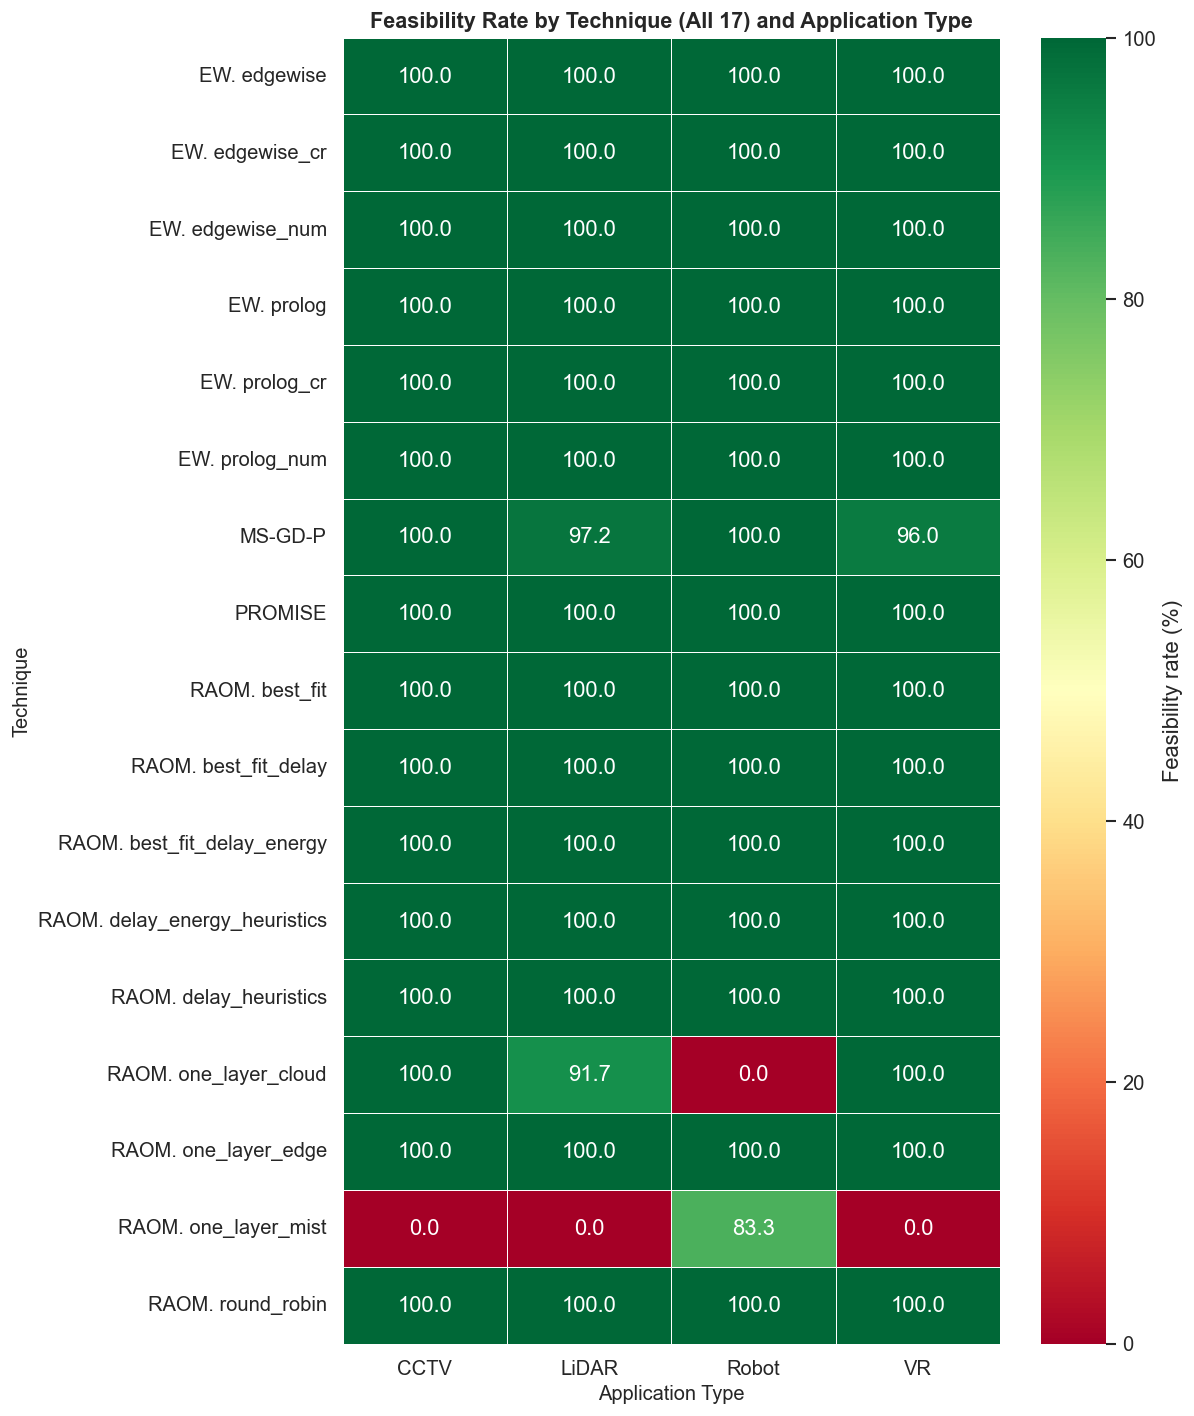

In [55]:
# Ungrouped feasibility heatmap - all 17 techniques
feas_pivot_ungrouped = all_data.groupby(['technique', 'app_name'])['feasible'].mean() * 100
feas_pivot_ungrouped = feas_pivot_ungrouped.unstack('app_name')
feas_pivot_ungrouped = feas_pivot_ungrouped[[APP_NAMES[a] for a in APP_ORDER]]
feas_pivot_ungrouped.index = [short_tech(t) for t in feas_pivot_ungrouped.index]
feas_pivot_ungrouped = feas_pivot_ungrouped.sort_index()

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(feas_pivot_ungrouped, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Feasibility rate (%)'},
            linewidths=0.5, linecolor='white')
ax.set_title('Feasibility Rate by Technique (All 17) and Application Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Application Type', fontsize=12)
ax.set_ylabel('Technique', fontsize=12)
plt.tight_layout()
plt.savefig('results/figures/ungrouped_feasibility_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

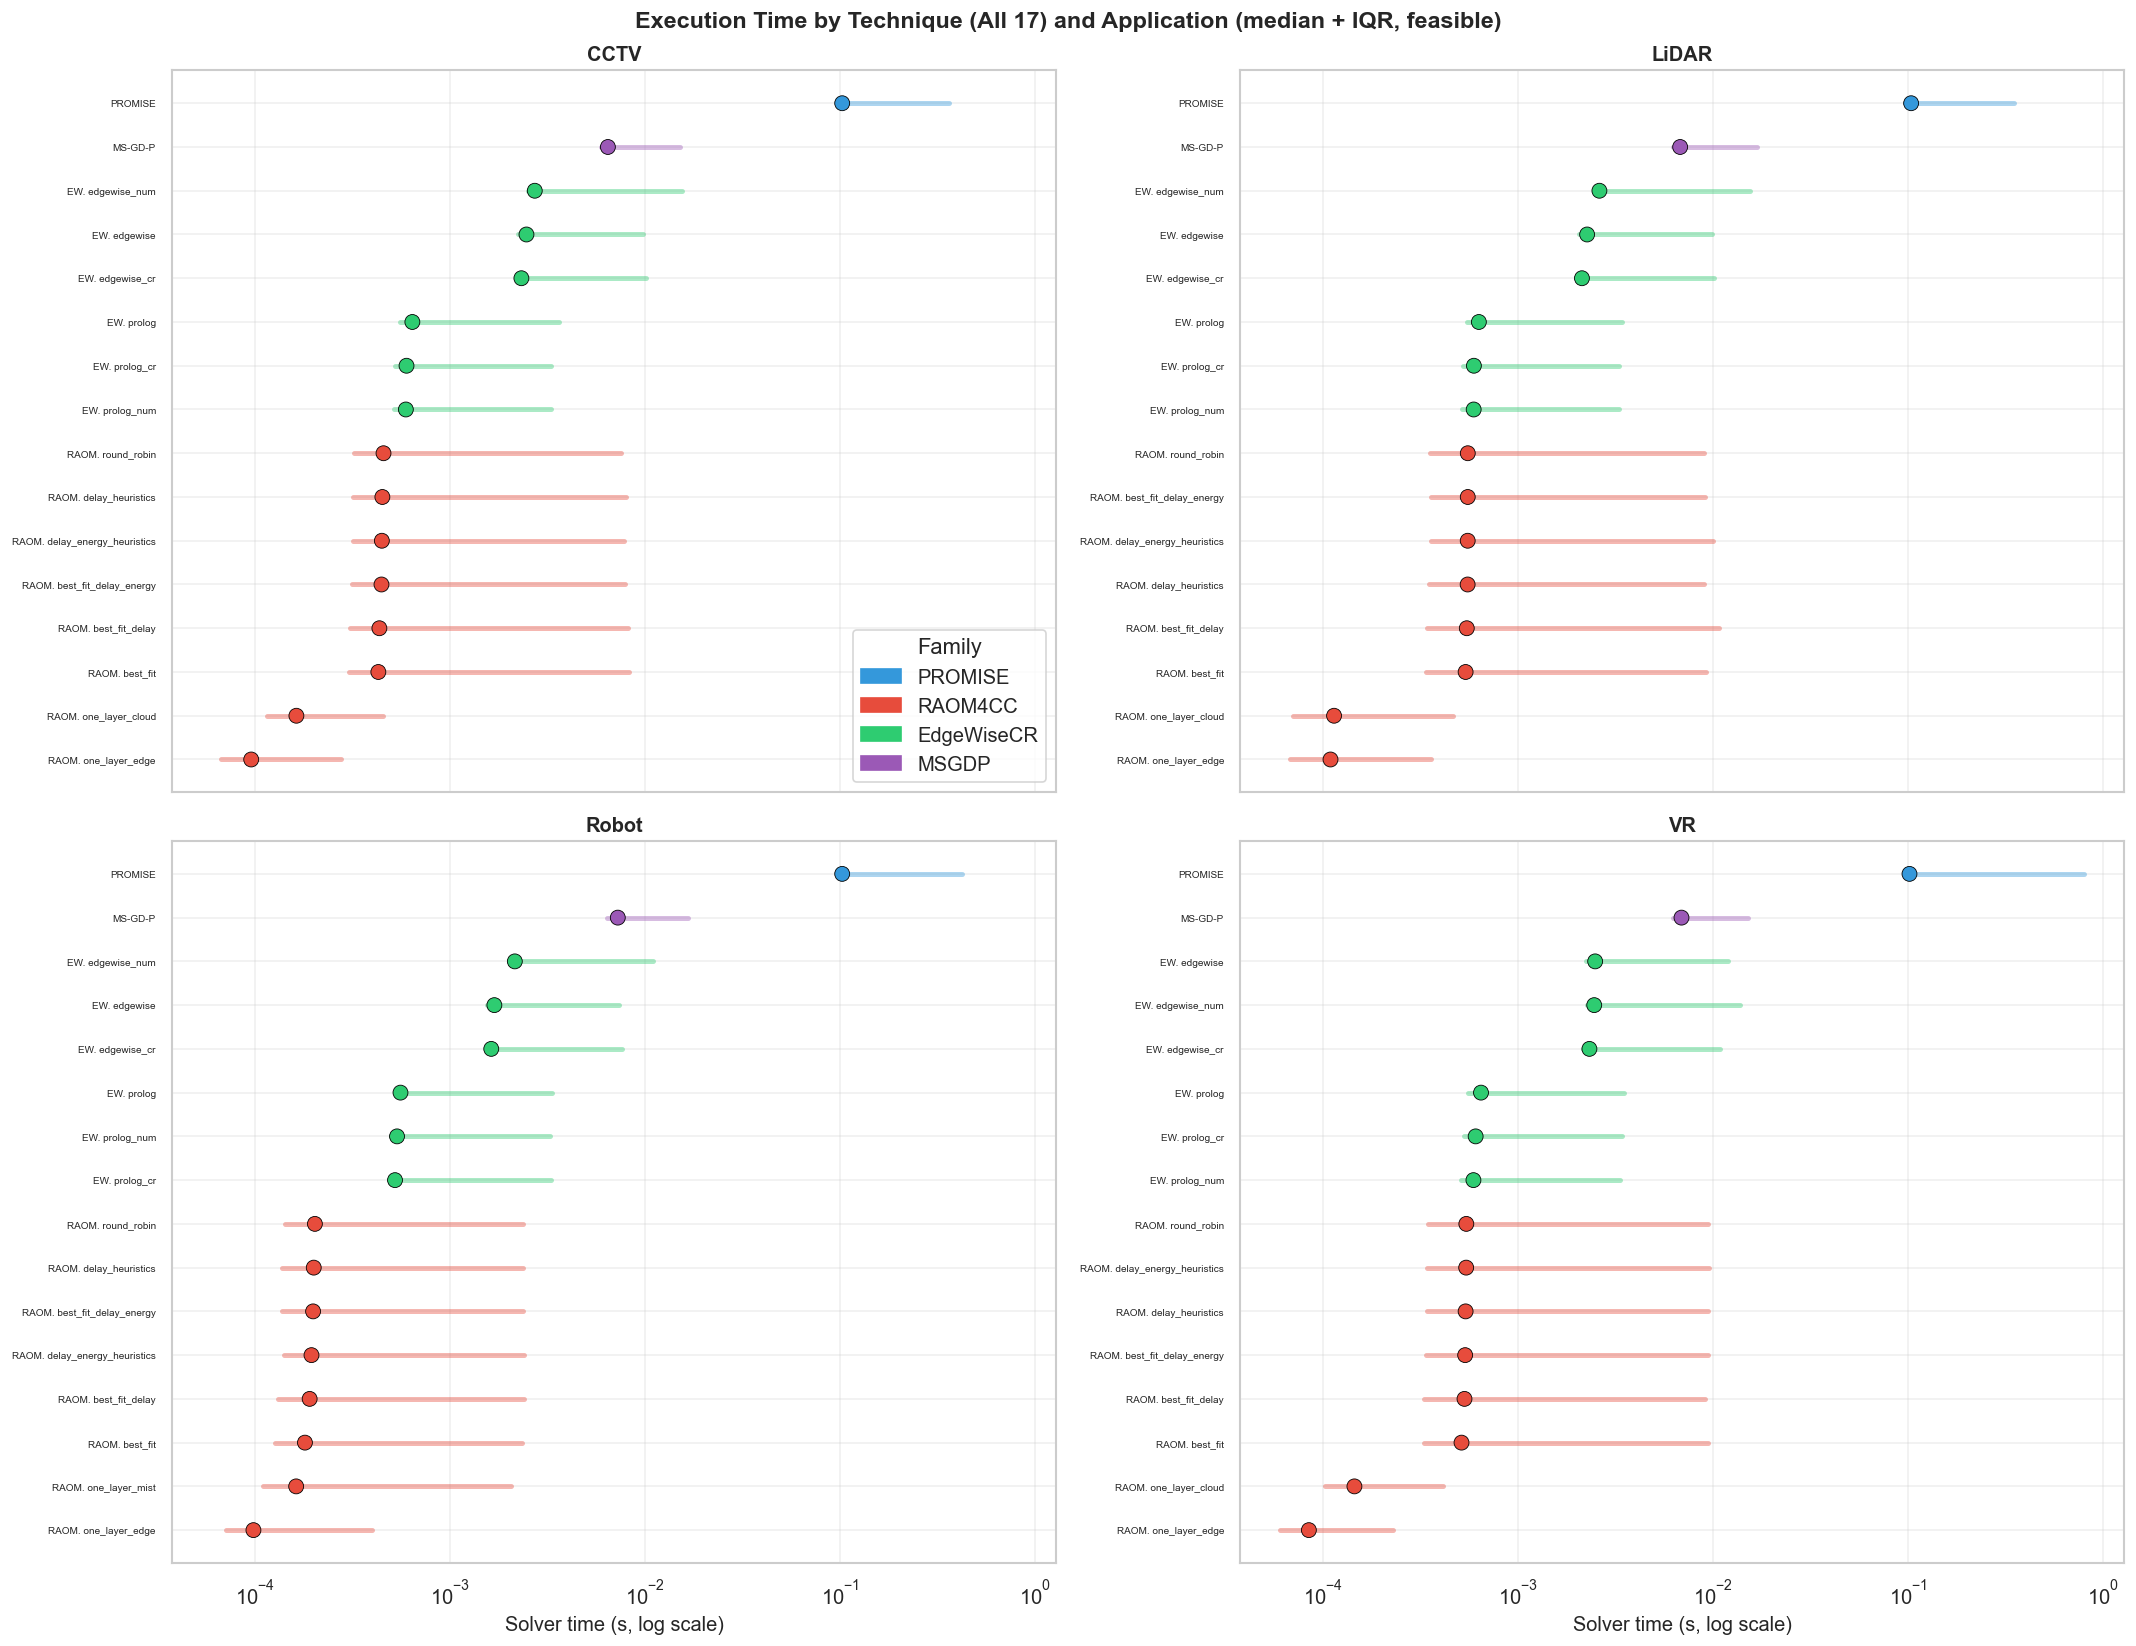

In [56]:
# Ungrouped execution time distribution - all 17 techniques
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[feasible_data['app'] == app]
    ts = sub.groupby('technique').agg(
        median=('time_s', 'median'),
        q25=('time_s', lambda x: x.quantile(0.25)),
        q75=('time_s', lambda x: x.quantile(0.75)),
    ).sort_values('median')
    colors = [tech_color(t) for t in ts.index]
    for i, (tech, row) in enumerate(ts.iterrows()):
        ax.plot([row['q25'], row['q75']], [i, i], color=colors[i], linewidth=3, alpha=0.4)
    ax.scatter(ts['median'], range(len(ts)), c=colors, s=80, zorder=5,
               edgecolors='black', linewidth=0.5)
    ax.set_yticks(range(len(ts)))
    ax.set_yticklabels([short_tech(t) for t in ts.index], fontsize=6)
    ax.set_xscale('log')
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Solver time (s, log scale)', fontsize=12)
    if ax == axes[0, 0]:
        patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
        ax.legend(handles=patches, loc='lower right', title='Family')
fig.suptitle('Execution Time by Technique (All 17) and Application (median + IQR, feasible)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ungrouped_time_distribution_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

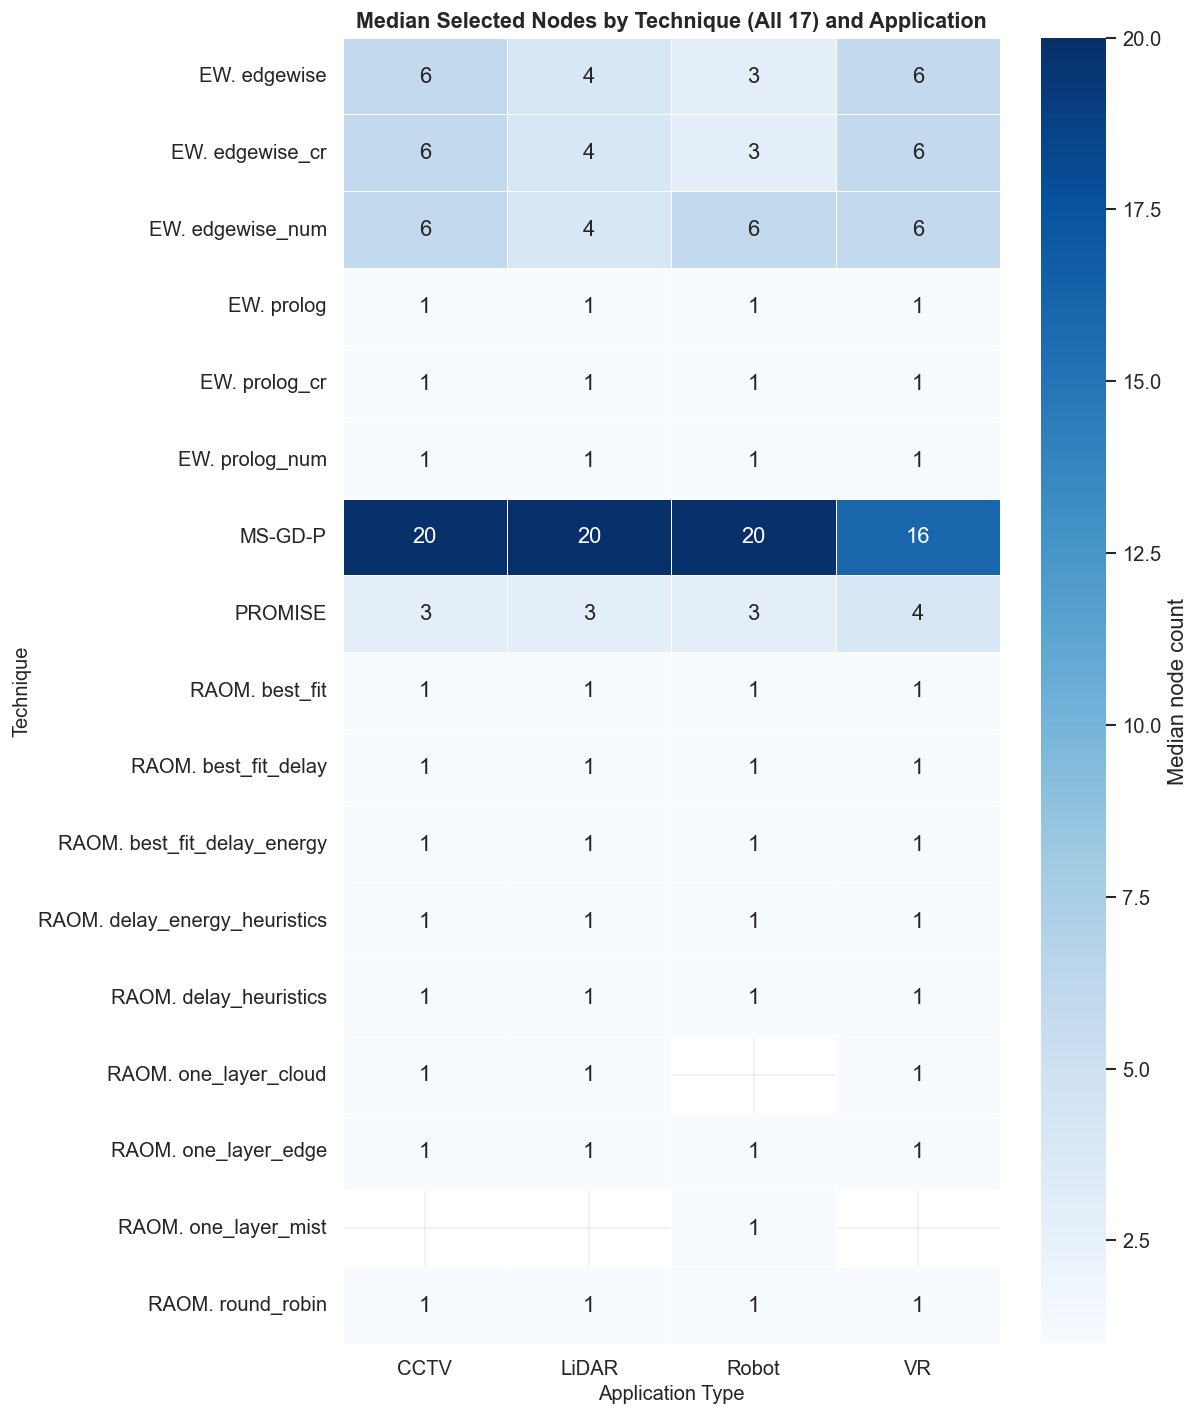

In [57]:
# Ungrouped node count heatmap - all 17 techniques
nodes_pivot_ungrouped = (feasible_data.groupby(['technique', 'app_name'])['nodes'].median()
                         .unstack('app_name'))
nodes_pivot_ungrouped = nodes_pivot_ungrouped[[APP_NAMES[a] for a in APP_ORDER]]
nodes_pivot_ungrouped.index = [short_tech(t) for t in nodes_pivot_ungrouped.index]
nodes_pivot_ungrouped = nodes_pivot_ungrouped.sort_index()

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(nodes_pivot_ungrouped, annot=True, fmt='.0f', cmap='Blues',
            ax=ax, cbar_kws={'label': 'Median node count'},
            linewidths=0.5, linecolor='white')
ax.set_title('Median Selected Nodes by Technique (All 17) and Application', fontsize=13, fontweight='bold')
ax.set_xlabel('Application Type', fontsize=12)
ax.set_ylabel('Technique', fontsize=12)
plt.tight_layout()
plt.savefig('results/figures/ungrouped_nodes_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

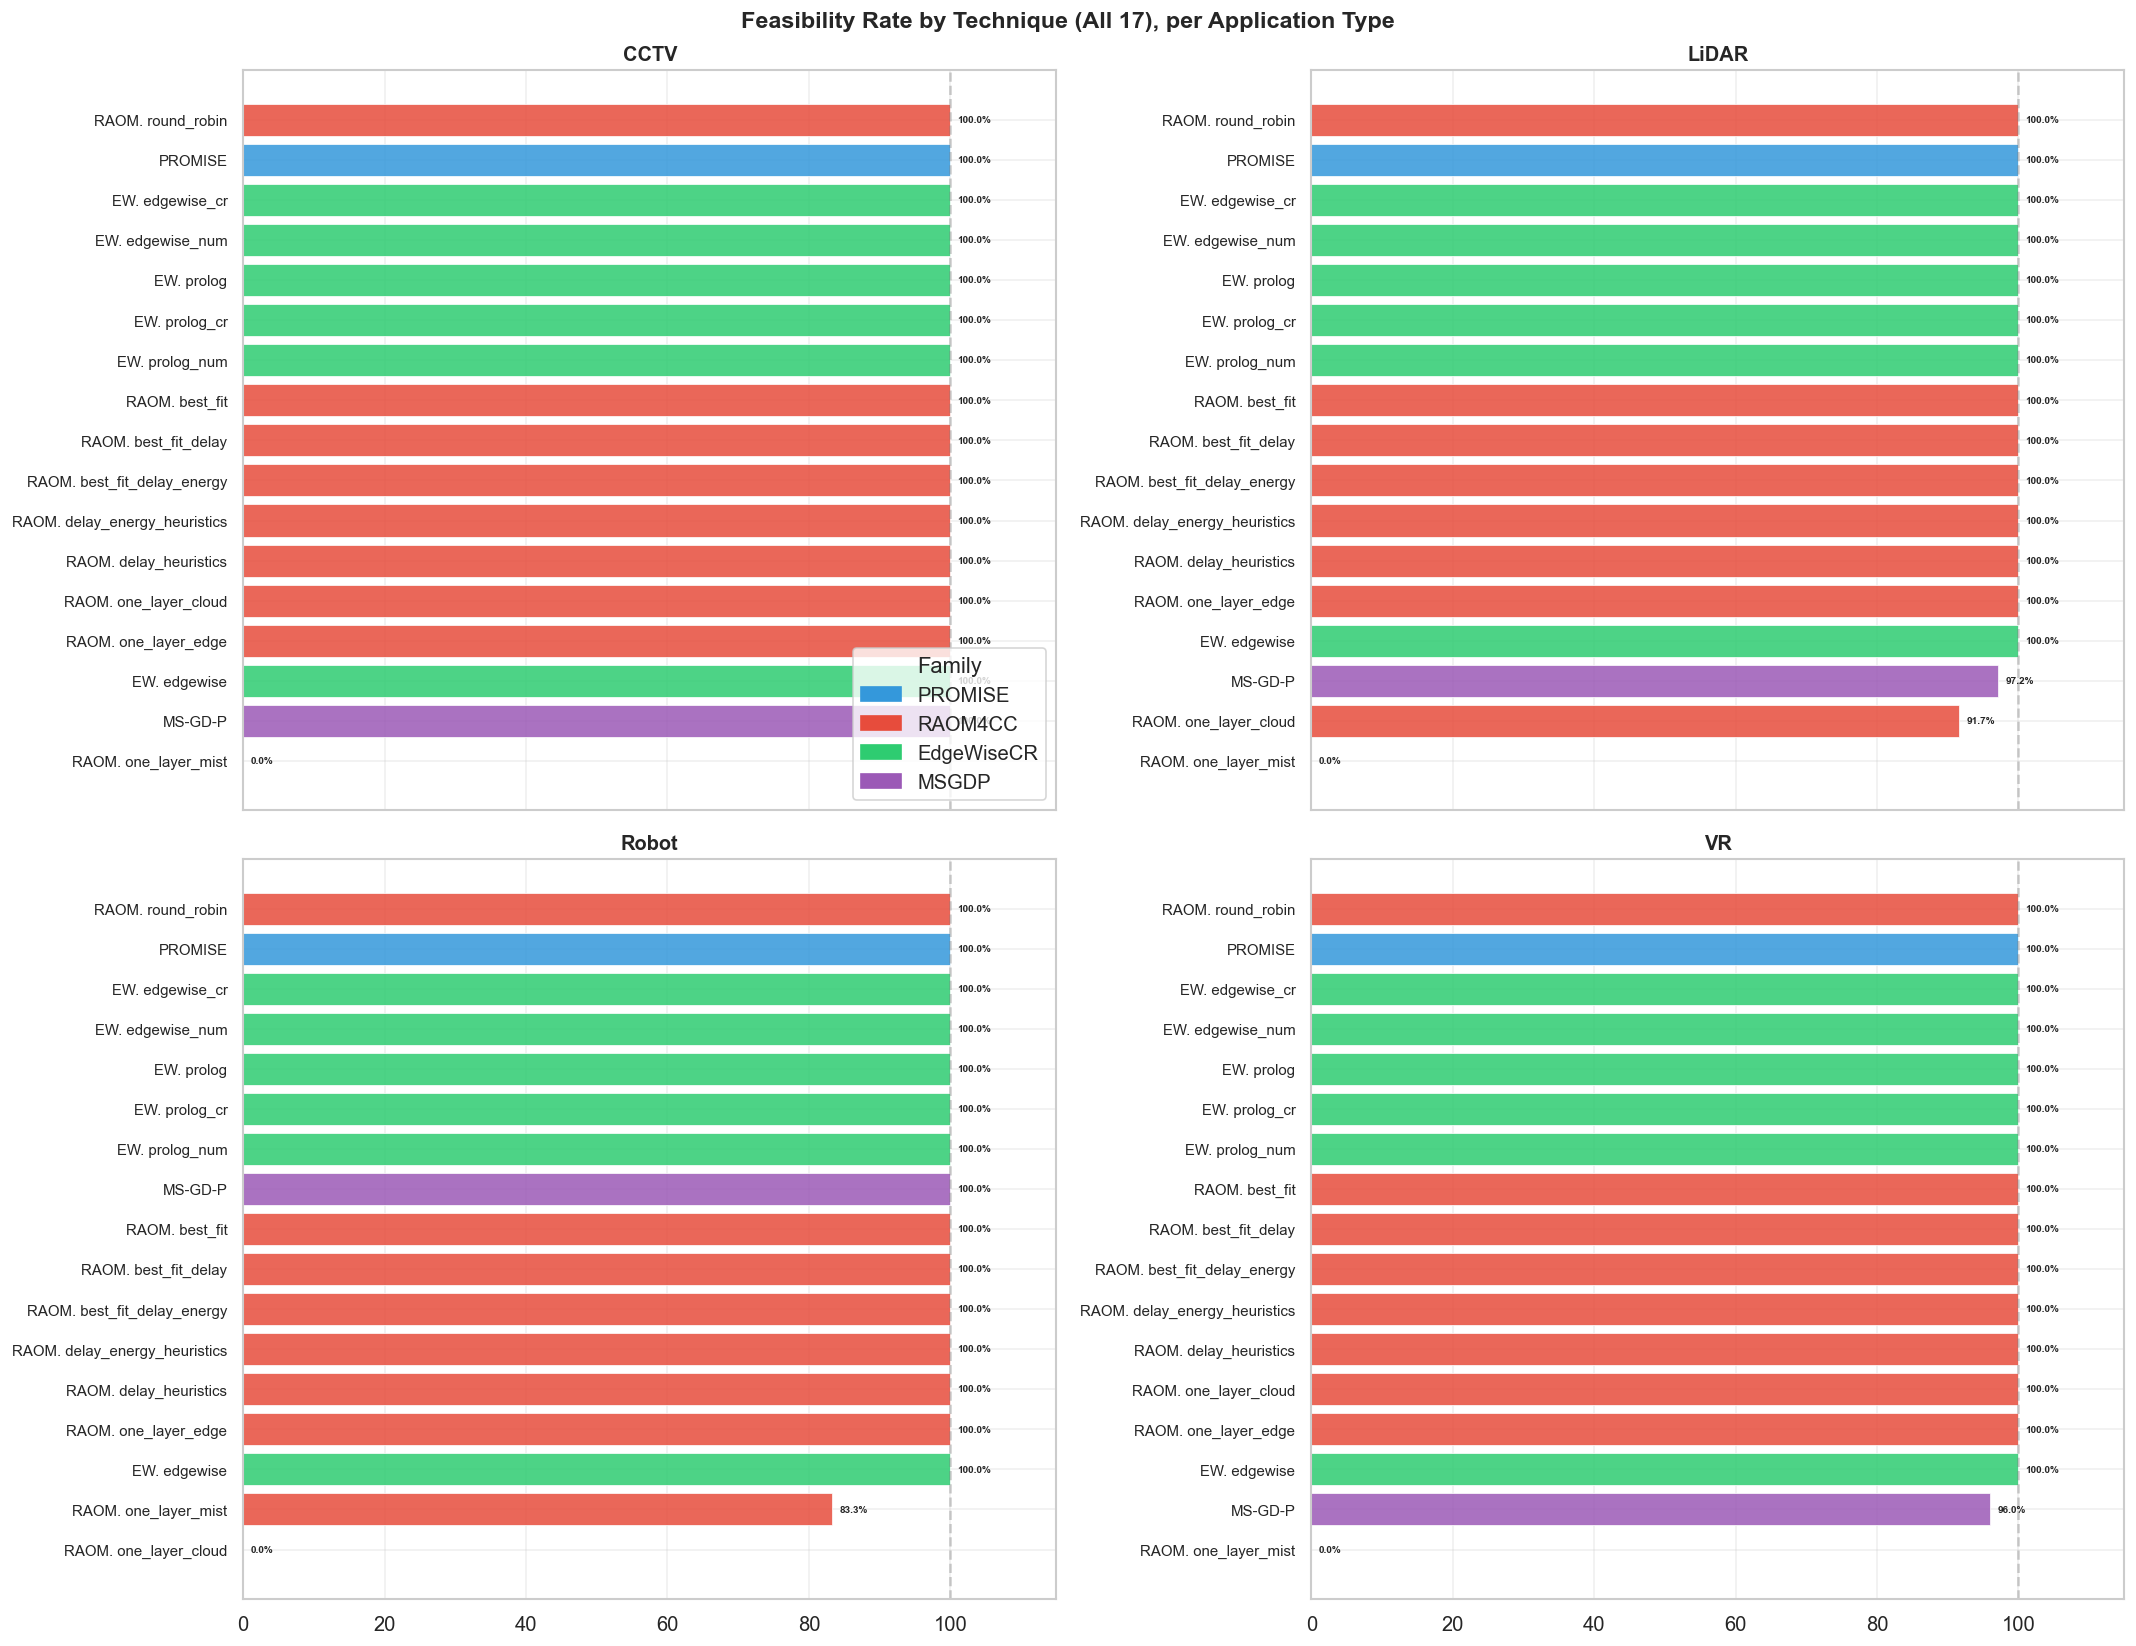

In [58]:
# Ungrouped feasibility bar charts - all 17 techniques
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = all_data[all_data['app'] == app]
    feas = sub.groupby('technique')['feasible'].mean().sort_values() * 100
    colors = [tech_color(t) for t in feas.index]
    ax.barh(range(len(feas)), feas.values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(feas)))
    ax.set_yticklabels([short_tech(t) for t in feas.index], fontsize=9)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    ax.axvline(100, color='grey', ls='--', alpha=0.4)
    ax.set_xlim(0, 115)
    for i, v in enumerate(feas.values):
        ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=6, fontweight='bold')
    if ax == axes[0, 0]:
        patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
        ax.legend(handles=patches, loc='lower right', title='Family')
fig.suptitle('Feasibility Rate by Technique (All 17), per Application Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ungrouped_feasibility_faceted.png', dpi=150, bbox_inches='tight')
plt.show()

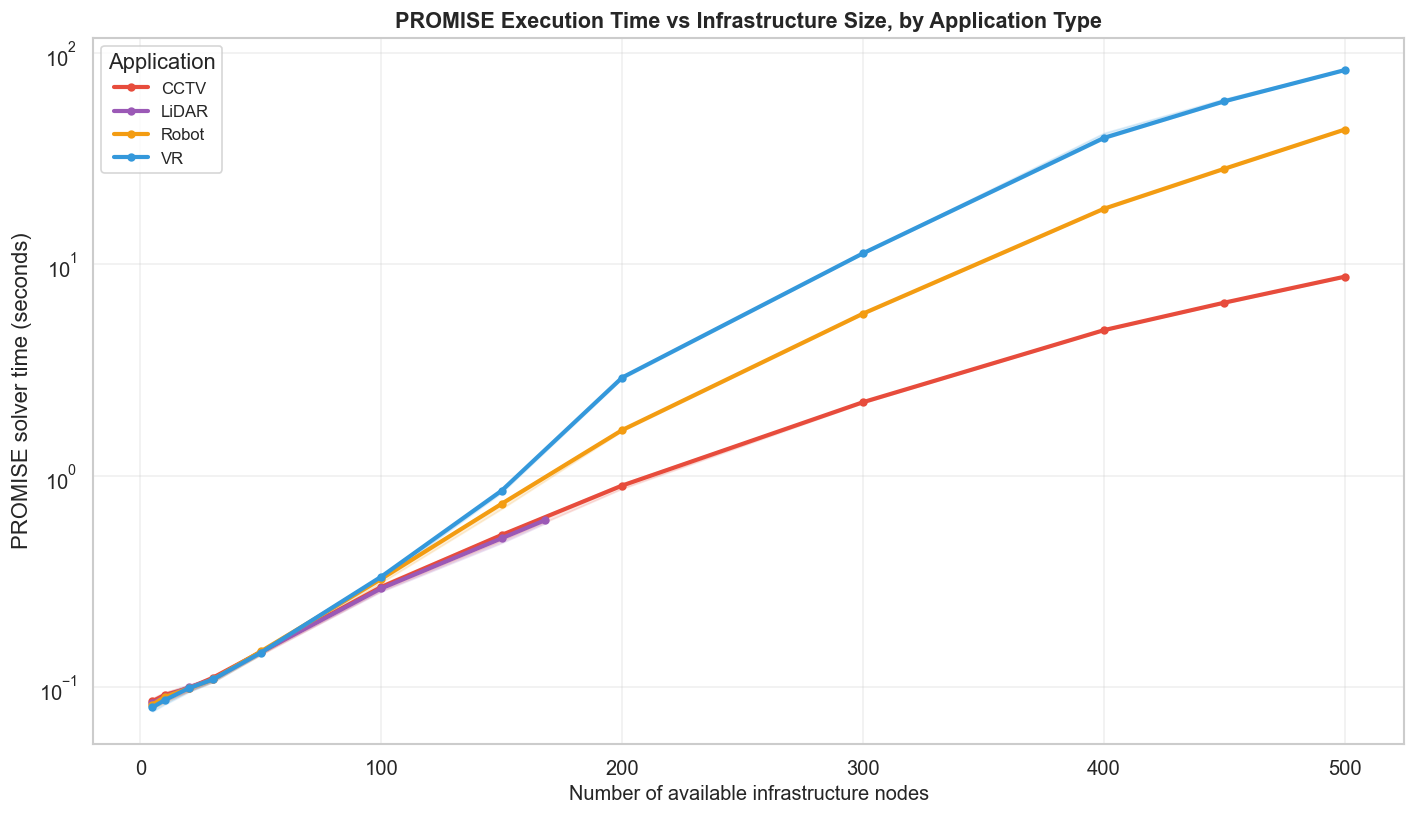

In [59]:
# Ungrouped PROMISE time vs infrastructure size
prime_feas_ungrouped = feasible_data[feasible_data['technique'] == 'PROMISE'].copy()
prime_agg_ungrouped = prime_feas_ungrouped.groupby(['app', 'num_devices']).agg(
    median_time=('time_s', 'median'),
    q25=('time_s', lambda x: x.quantile(0.25)),
    q75=('time_s', lambda x: x.quantile(0.75)),
    n=('time_s', 'count'),
).reset_index()
prime_agg_ungrouped = prime_agg_ungrouped[prime_agg_ungrouped['n'] >= 3]

fig, ax = plt.subplots(figsize=(12, 7))
for app in APP_ORDER:
    subset = prime_agg_ungrouped[prime_agg_ungrouped['app'] == app].sort_values('num_devices')
    c = APP_COLORS[app]
    ax.fill_between(subset['num_devices'], subset['q25'], subset['q75'],
                    alpha=0.15, color=c)
    ax.plot(subset['num_devices'], subset['median_time'],
            marker='o', markersize=4, linewidth=2.5, color=c, label=APP_NAMES[app])

ax.set_xlabel('Number of available infrastructure nodes', fontsize=12)
ax.set_ylabel('PROMISE solver time (seconds)')
ax.set_yscale('log')
ax.set_title('PROMISE Execution Time vs Infrastructure Size, by Application Type',
             fontsize=13, fontweight='bold')
ax.legend(title='Application', fontsize=10)
plt.tight_layout()
plt.savefig('results/figures/ungrouped_prime_time_vs_devices_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

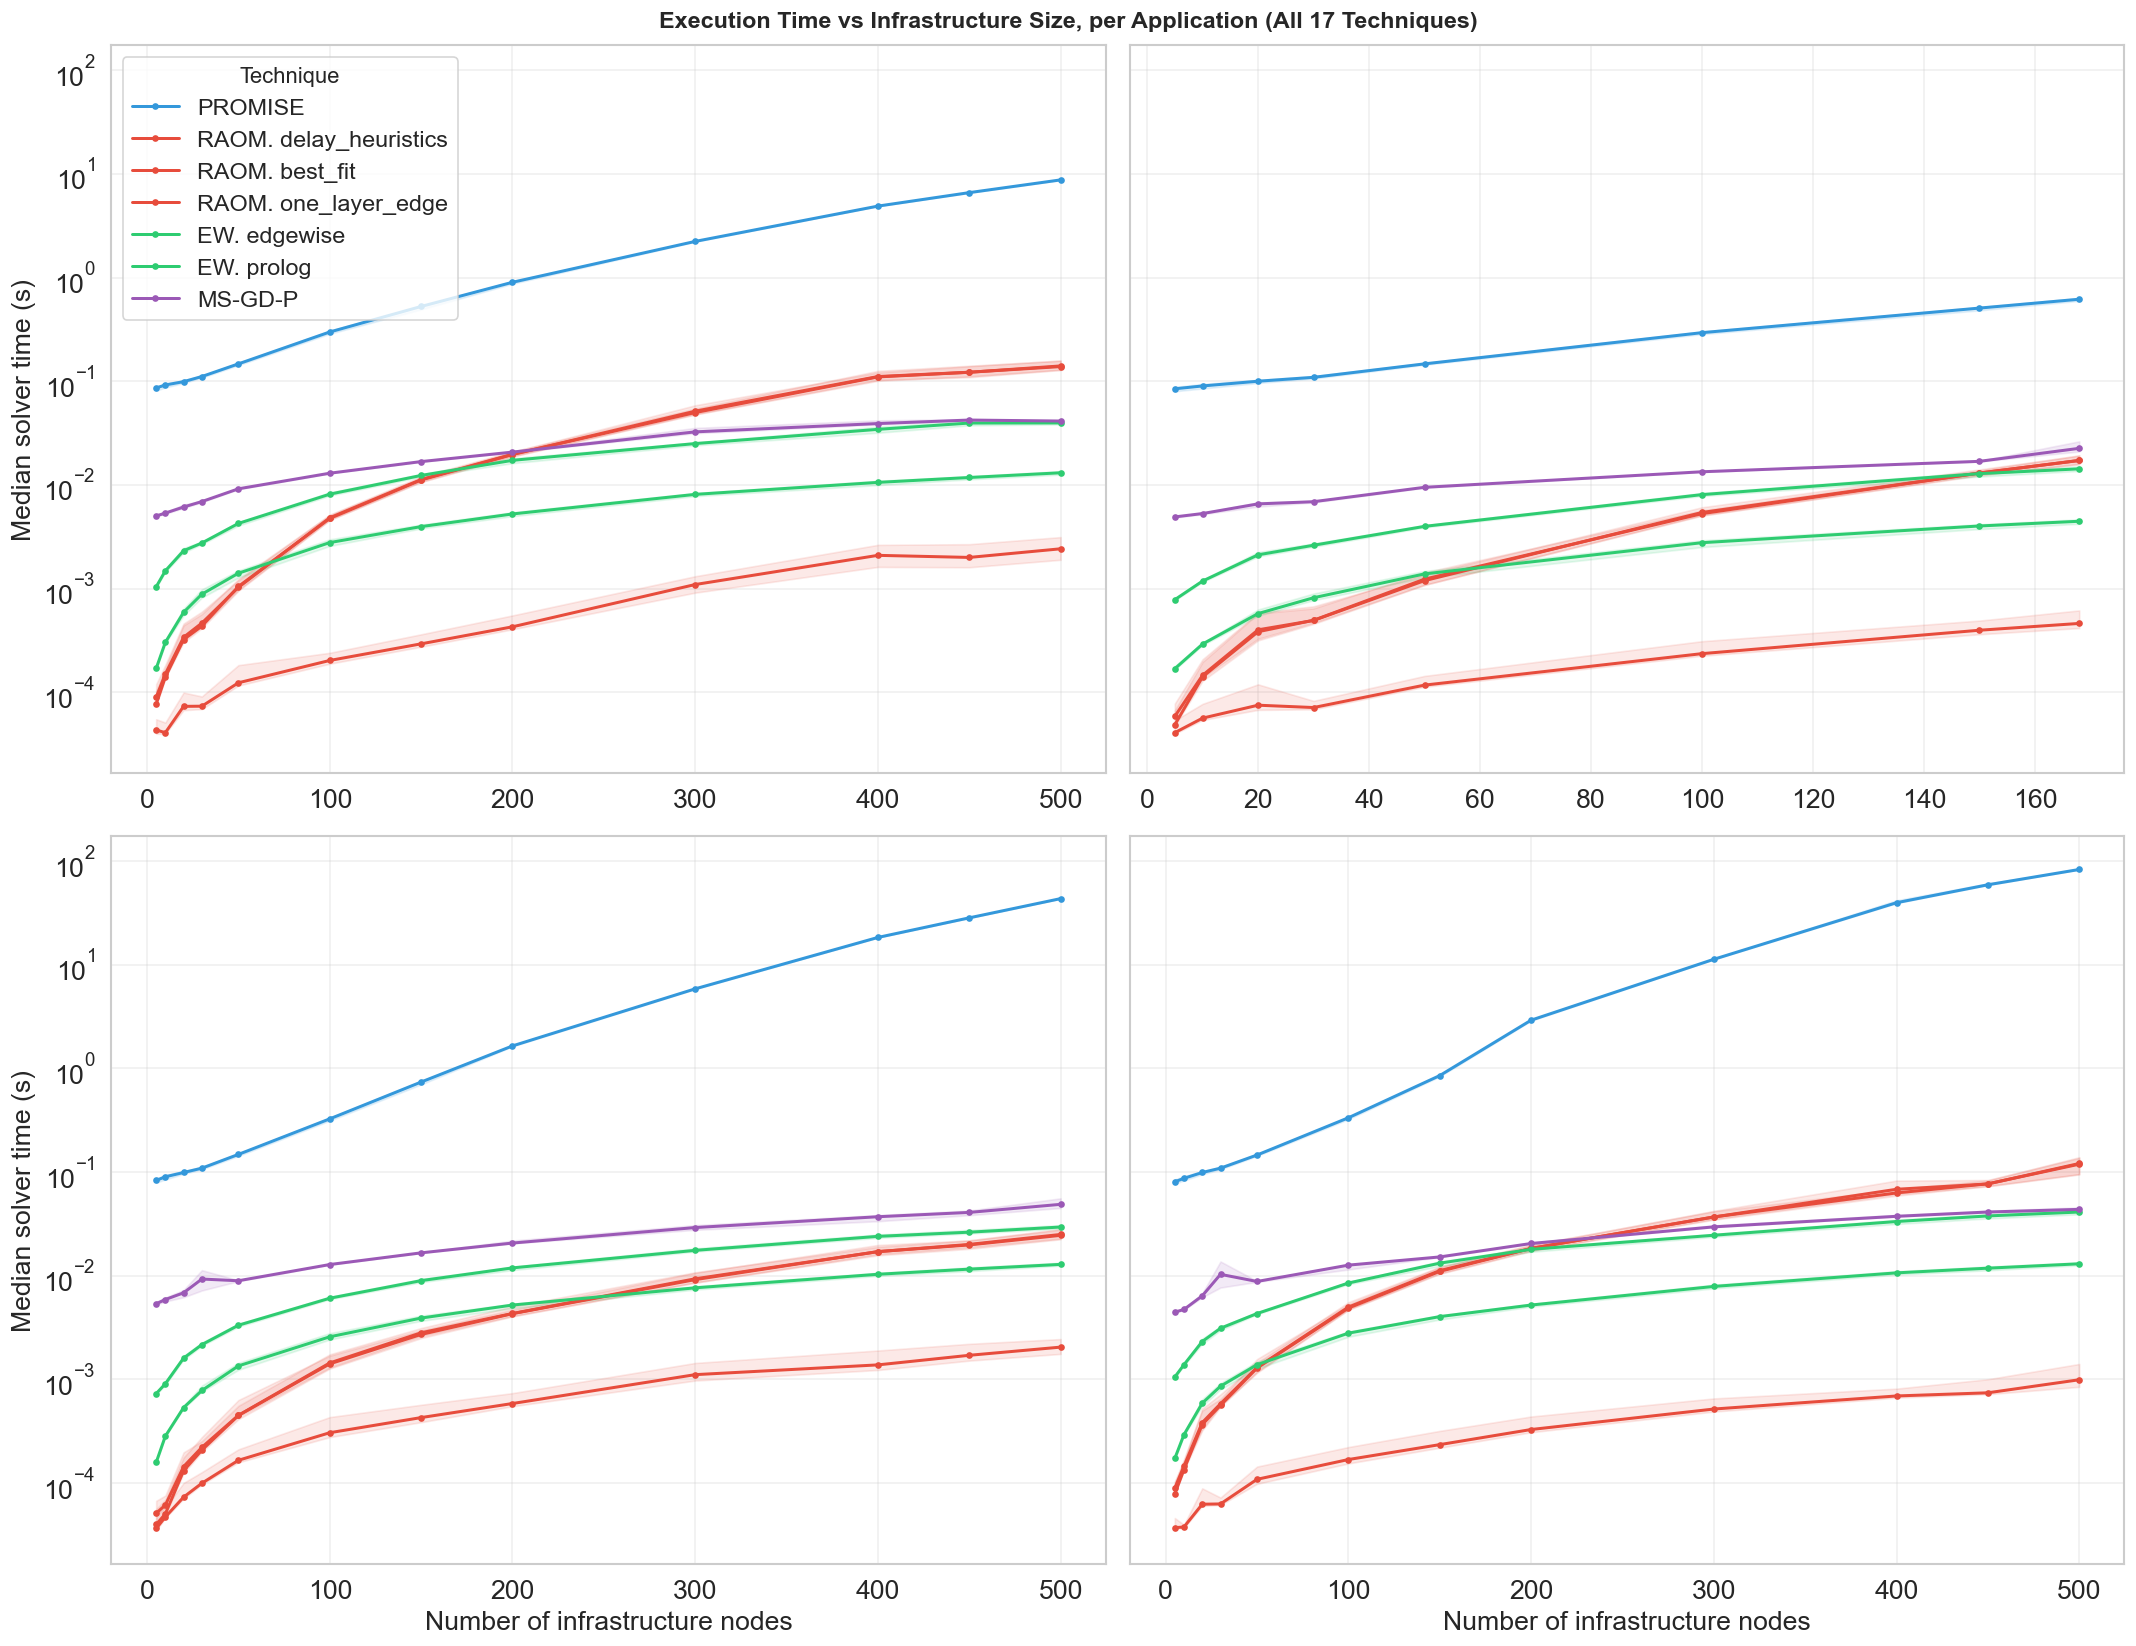

In [66]:
# Ungrouped time vs infrastructure size - all 17 techniques
key_techs_ungrouped = ['PROMISE', 'RAOM4CC_delay_heuristics', 'RAOM4CC_best_fit',
                       'RAOM4CC_one_layer_edge', 'EdgeWiseCR_edgewise', 'EdgeWiseCR_prolog', 'MSGDP']

fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharey=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[(feasible_data['app'] == app) &
                        (feasible_data['technique'].isin(key_techs_ungrouped))]
    agg = sub.groupby(['technique', 'num_devices']).agg(
        median_time=('time_s', 'median'),
        q25=('time_s', lambda x: x.quantile(0.25)),
        q75=('time_s', lambda x: x.quantile(0.75)),
        n=('time_s', 'count'),
    ).reset_index()
    agg = agg[agg['n'] >= 3]
    for tech in key_techs_ungrouped:
        subset = agg[agg['technique'] == tech].sort_values('num_devices')
        if len(subset) == 0:
            continue
        c = tech_color(tech)
        ax.fill_between(subset['num_devices'], subset['q25'], subset['q75'],
                        alpha=0.12, color=c)
        ax.plot(subset['num_devices'], subset['median_time'],
                marker='o', markersize=3, linewidth=1.8, color=c,
                label=short_tech(tech))
    ax.set_yscale('log')
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=16)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Number of infrastructure nodes', fontsize=16)
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Median solver time (s)', fontsize=16)
    if ax == axes[0, 0]:
        ax.legend(title='Technique', fontsize=14, loc='upper left')
fig.suptitle('Execution Time vs Infrastructure Size, per Application (All 17 Techniques)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ungrouped_time_vs_devices_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

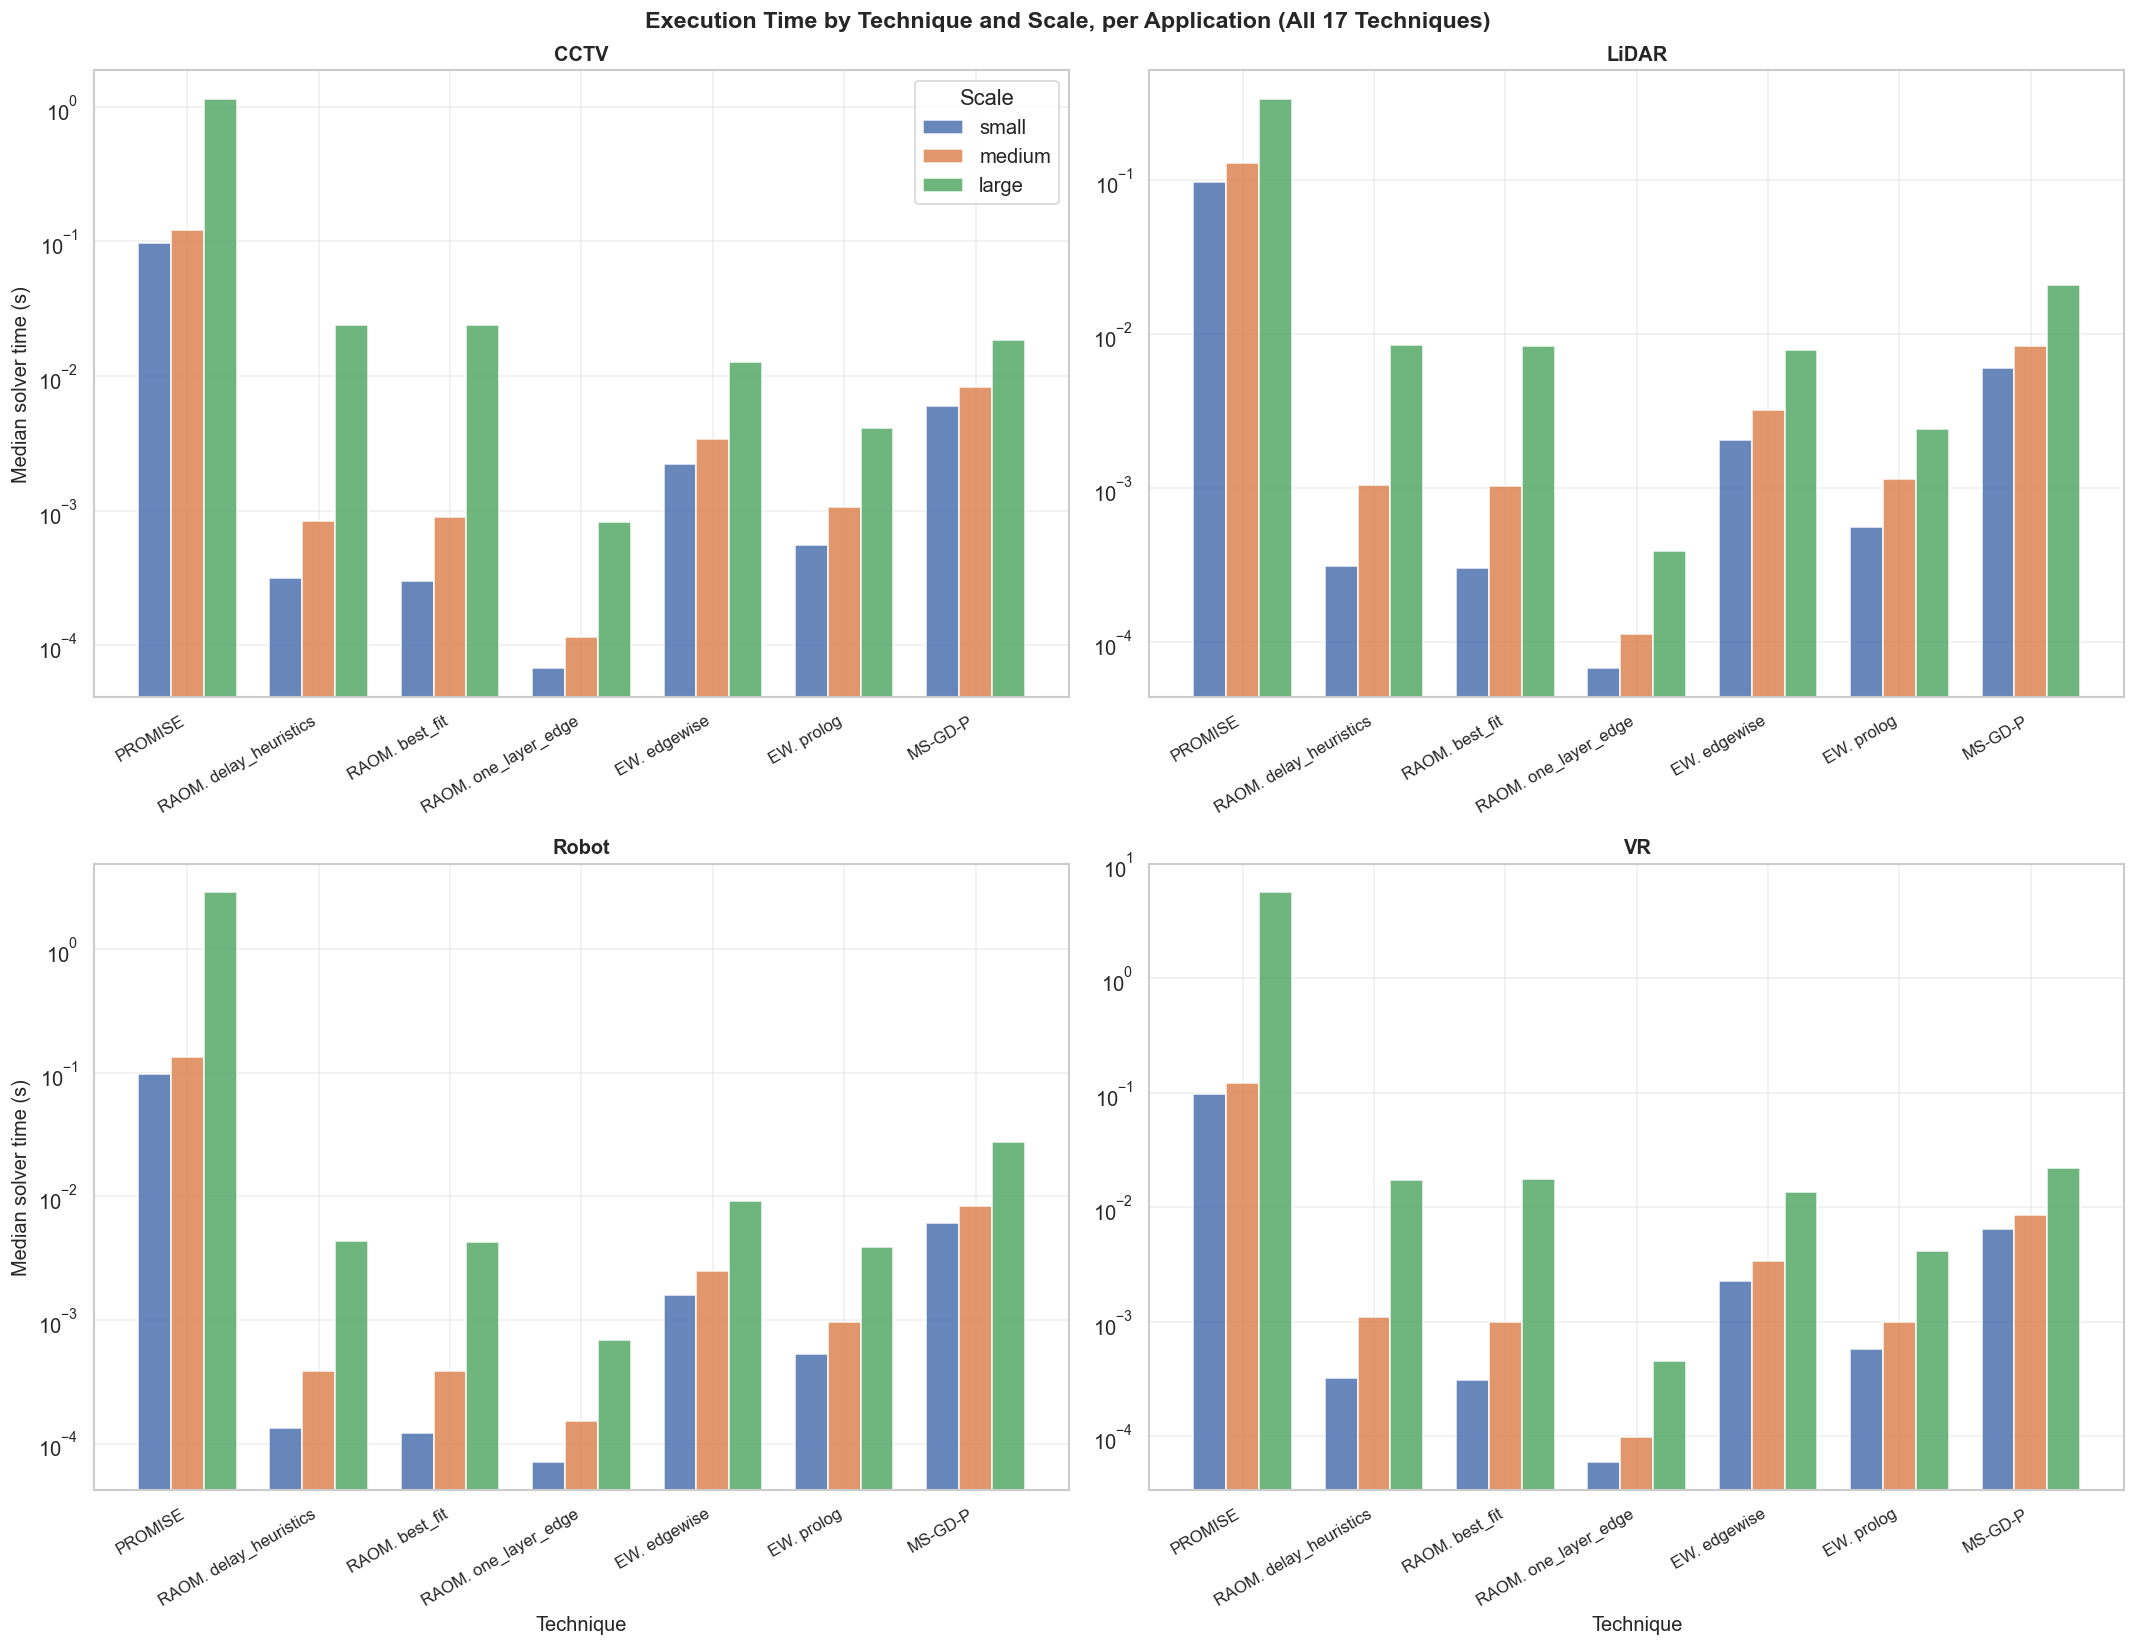

In [61]:
# Ungrouped time by scale - all 17 techniques
scale_order = ['small', 'medium', 'large']
key_techs_scale_ungrouped = ['PROMISE', 'RAOM4CC_delay_heuristics', 'RAOM4CC_best_fit',
                             'RAOM4CC_one_layer_edge', 'EdgeWiseCR_edgewise', 'EdgeWiseCR_prolog', 'MSGDP']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[(feasible_data['app'] == app) &
                        (feasible_data['technique'].isin(key_techs_scale_ungrouped))]
    st = sub.groupby(['technique', 'scale'])['time_s'].median().unstack('scale')
    st = st.reindex(columns=scale_order)
    st = st.loc[[t for t in key_techs_scale_ungrouped if t in st.index]]
    x = np.arange(len(st))
    width = 0.25
    for i, scale in enumerate(scale_order):
        ax.bar(x + i * width, st[scale].values, width, label=scale, alpha=0.85, edgecolor='white')
    ax.set_xticks(x + width)
    ax.set_xticklabels([short_tech(t) for t in st.index], rotation=30, ha='right', fontsize=10)
    ax.set_yscale('log')
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Technique', fontsize=12)
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Median solver time (s)', fontsize=12)
    if ax == axes[0, 0]:
        ax.legend(title='Scale')
fig.suptitle('Execution Time by Technique and Scale, per Application (All 17 Techniques)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ungrouped_time_by_scale_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

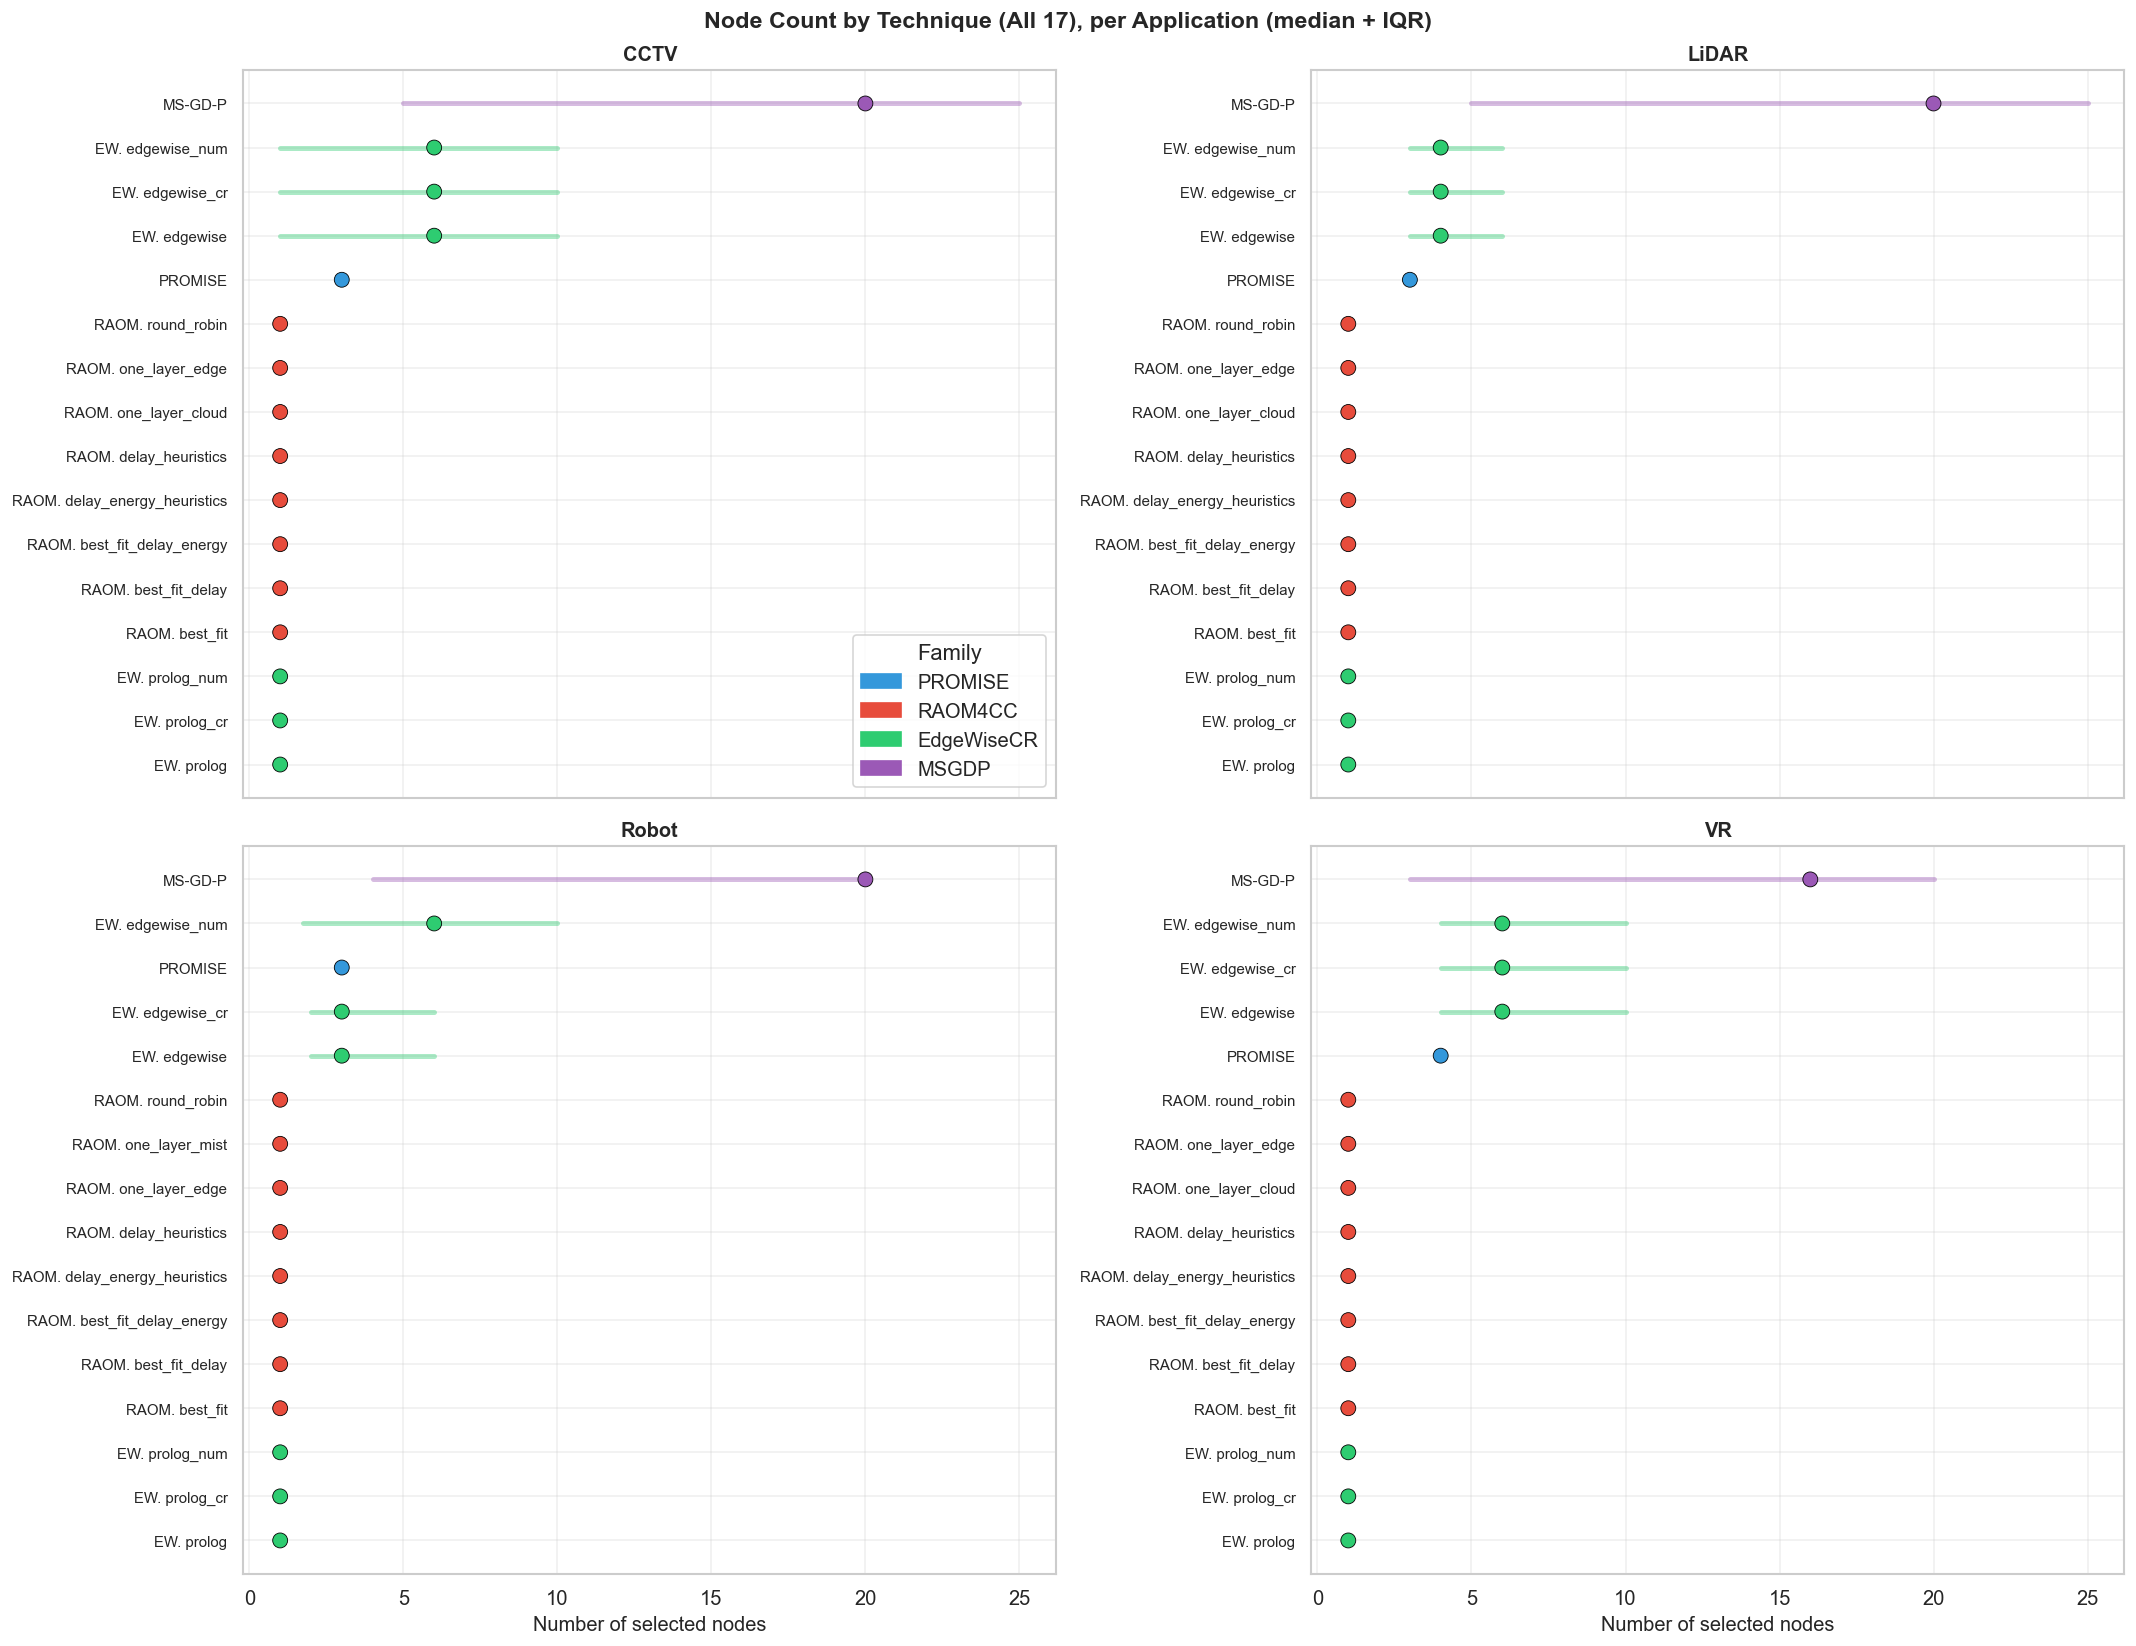

In [62]:
# Ungrouped node count distribution - all 17 techniques
fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[feasible_data['app'] == app]
    ns = sub.groupby('technique').agg(
        median=('nodes', 'median'),
        q25=('nodes', lambda x: x.quantile(0.25)),
        q75=('nodes', lambda x: x.quantile(0.75)),
    ).sort_values('median')
    colors = [tech_color(t) for t in ns.index]
    for i, (tech, row) in enumerate(ns.iterrows()):
        ax.plot([row['q25'], row['q75']], [i, i], color=colors[i], linewidth=3, alpha=0.4)
    ax.scatter(ns['median'], range(len(ns)), c=colors, s=80, zorder=5,
               edgecolors='black', linewidth=0.5)
    ax.set_yticks(range(len(ns)))
    ax.set_yticklabels([short_tech(t) for t in ns.index], fontsize=9)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Number of selected nodes', fontsize=12)
    if ax == axes[0, 0]:
        patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
        ax.legend(handles=patches, loc='lower right', title='Family')
fig.suptitle('Node Count by Technique (All 17), per Application (median + IQR)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ungrouped_nodes_distribution_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

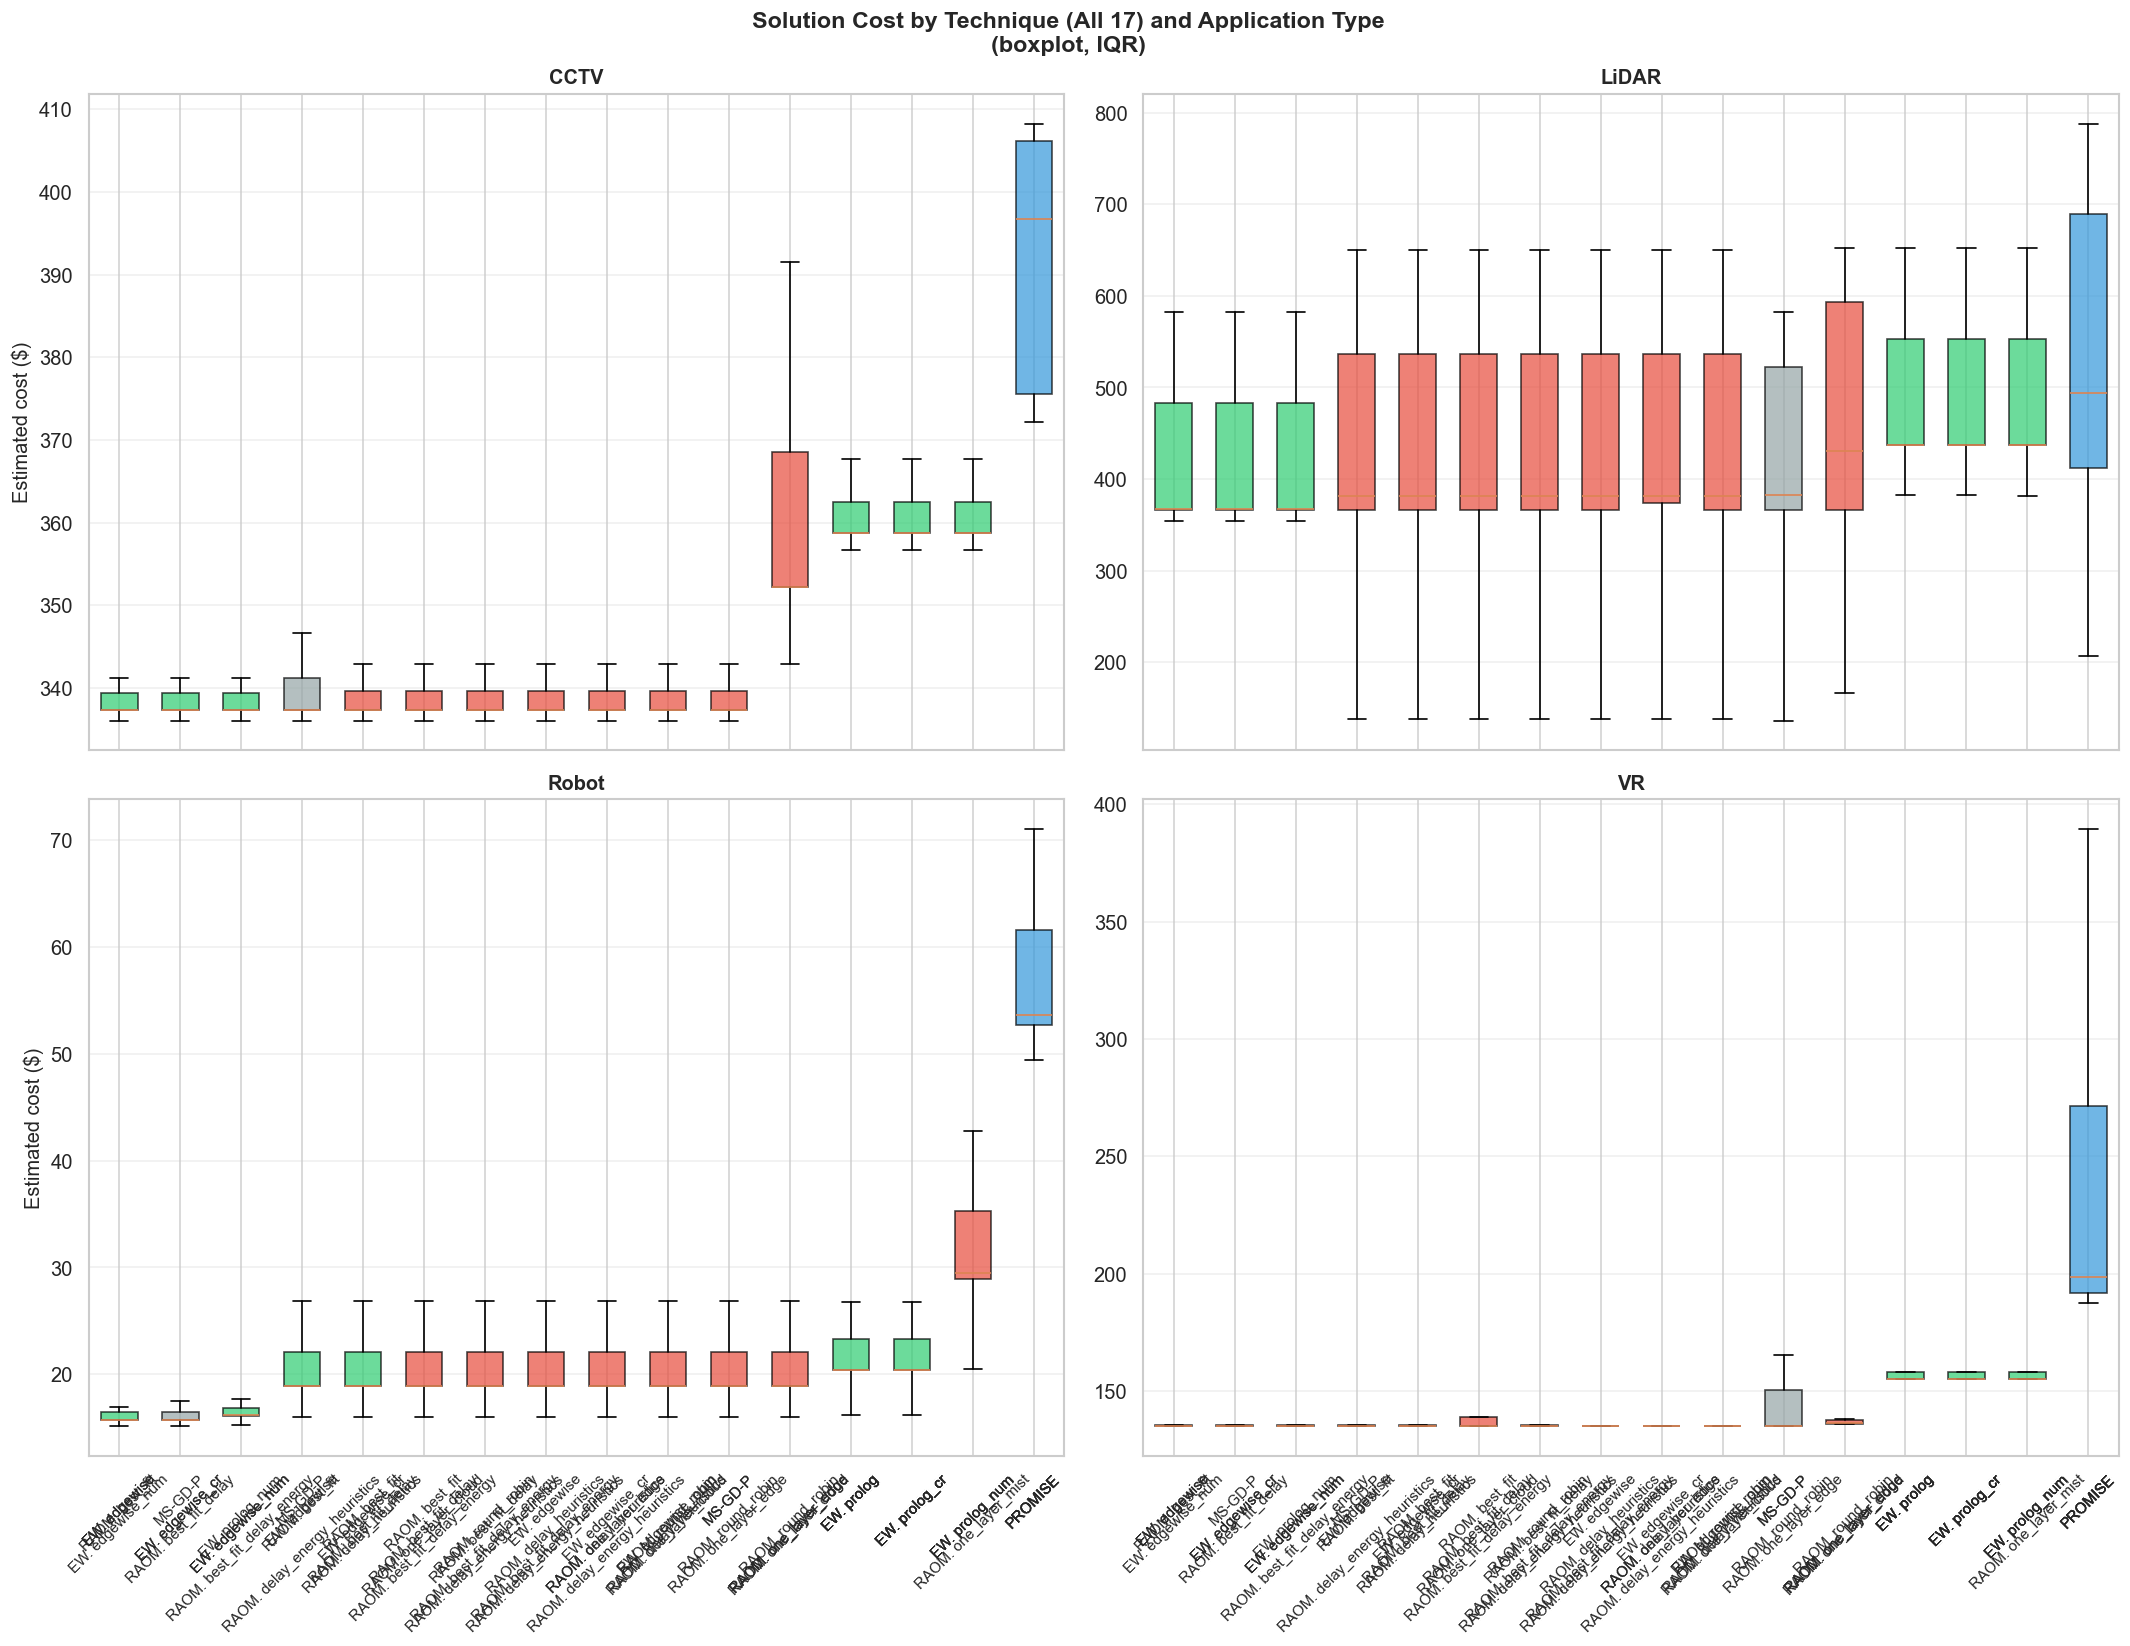

In [63]:
# Ungrouped cost by technique - all 17 techniques
# Build unified cost dataframe with MS-GD-P
prime_raw_local = prime_raw.copy()
prime_raw_local['cost_num'] = prime_raw_local['cost'].astype(str).str.replace(' $', '').astype(float)
raom_raw_local = raom_raw.copy()
raom_raw_local['cost_num'] = raom_raw_local['estimated_cost'].astype(float)
ew_raw_local = ew_raw.copy()
ew_raw_local['cost_num'] = ew_raw_local['estimated_cost'].astype(float)
msgdp_raw_local = msgdp_raw.copy()
msgdp_raw_local['cost_num'] = msgdp_raw_local['estimated_cost'].astype(float)

rows_cost = []
for _, r in prime_raw_local[prime_raw_local['status'] == 'COMPLETED'].iterrows():
    rows_cost.append({'app': r['scenario_id'].split('_')[2], 'technique': 'PROMISE',
                      'cost': r['cost_num'],
                      'nodes': len(ast.literal_eval(r['add_ons'])) if pd.notna(r['add_ons']) else 0})
for _, r in raom_raw_local[raom_raw_local['feasible'].astype(str) == 'True'].iterrows():
    rows_cost.append({'app': r['scenario_id'].split('_')[2], 'technique': 'RAOM4CC_' + r['algorithm'],
                      'cost': r['cost_num'],
                      'nodes': len(ast.literal_eval(r['selected_node'])) if pd.notna(r['selected_node']) else 0})
for _, r in ew_raw_local[ew_raw_local['feasible'].astype(str) == 'True'].iterrows():
    rows_cost.append({'app': r['scenario_id'].split('_')[2], 'technique': 'EdgeWiseCR_' + r['algorithm'],
                      'cost': r['cost_num'], 'nodes': r['bins']})
for _, r in msgdp_raw_local[msgdp_raw_local['feasible'].astype(str) == 'True'].iterrows():
    rows_cost.append({'app': r['scenario_id'].split('_')[2], 'technique': 'MS-GD-P',
                      'cost': r['cost_num'],
                      'nodes': len(ast.literal_eval(r['selected_nodes'])) if pd.notna(r['selected_nodes']) else 0})

cost_df_ungrouped = pd.DataFrame(rows_cost)

fig, axes = plt.subplots(2, 2, figsize=(18, 14), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = cost_df_ungrouped[cost_df_ungrouped['app'] == app]
    techs_sorted = sub.groupby('technique')['cost'].median().sort_values().index
    box_data = [sub[sub['technique'] == t]['cost'].values for t in techs_sorted]
    bp = ax.boxplot(box_data, tick_labels=[short_tech(t) for t in techs_sorted],
                    patch_artist=True, showfliers=False, widths=0.6)
    for patch, t in zip(bp['boxes'], techs_sorted):
        patch.set_facecolor(tech_color(t))
        patch.set_alpha(0.7)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    ax.tick_params(axis='x', labelsize=9, rotation=45)
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Estimated cost ($)', fontsize=12)
fig.suptitle('Solution Cost by Technique (All 17) and Application Type\n(boxplot, IQR)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ungrouped_cost_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

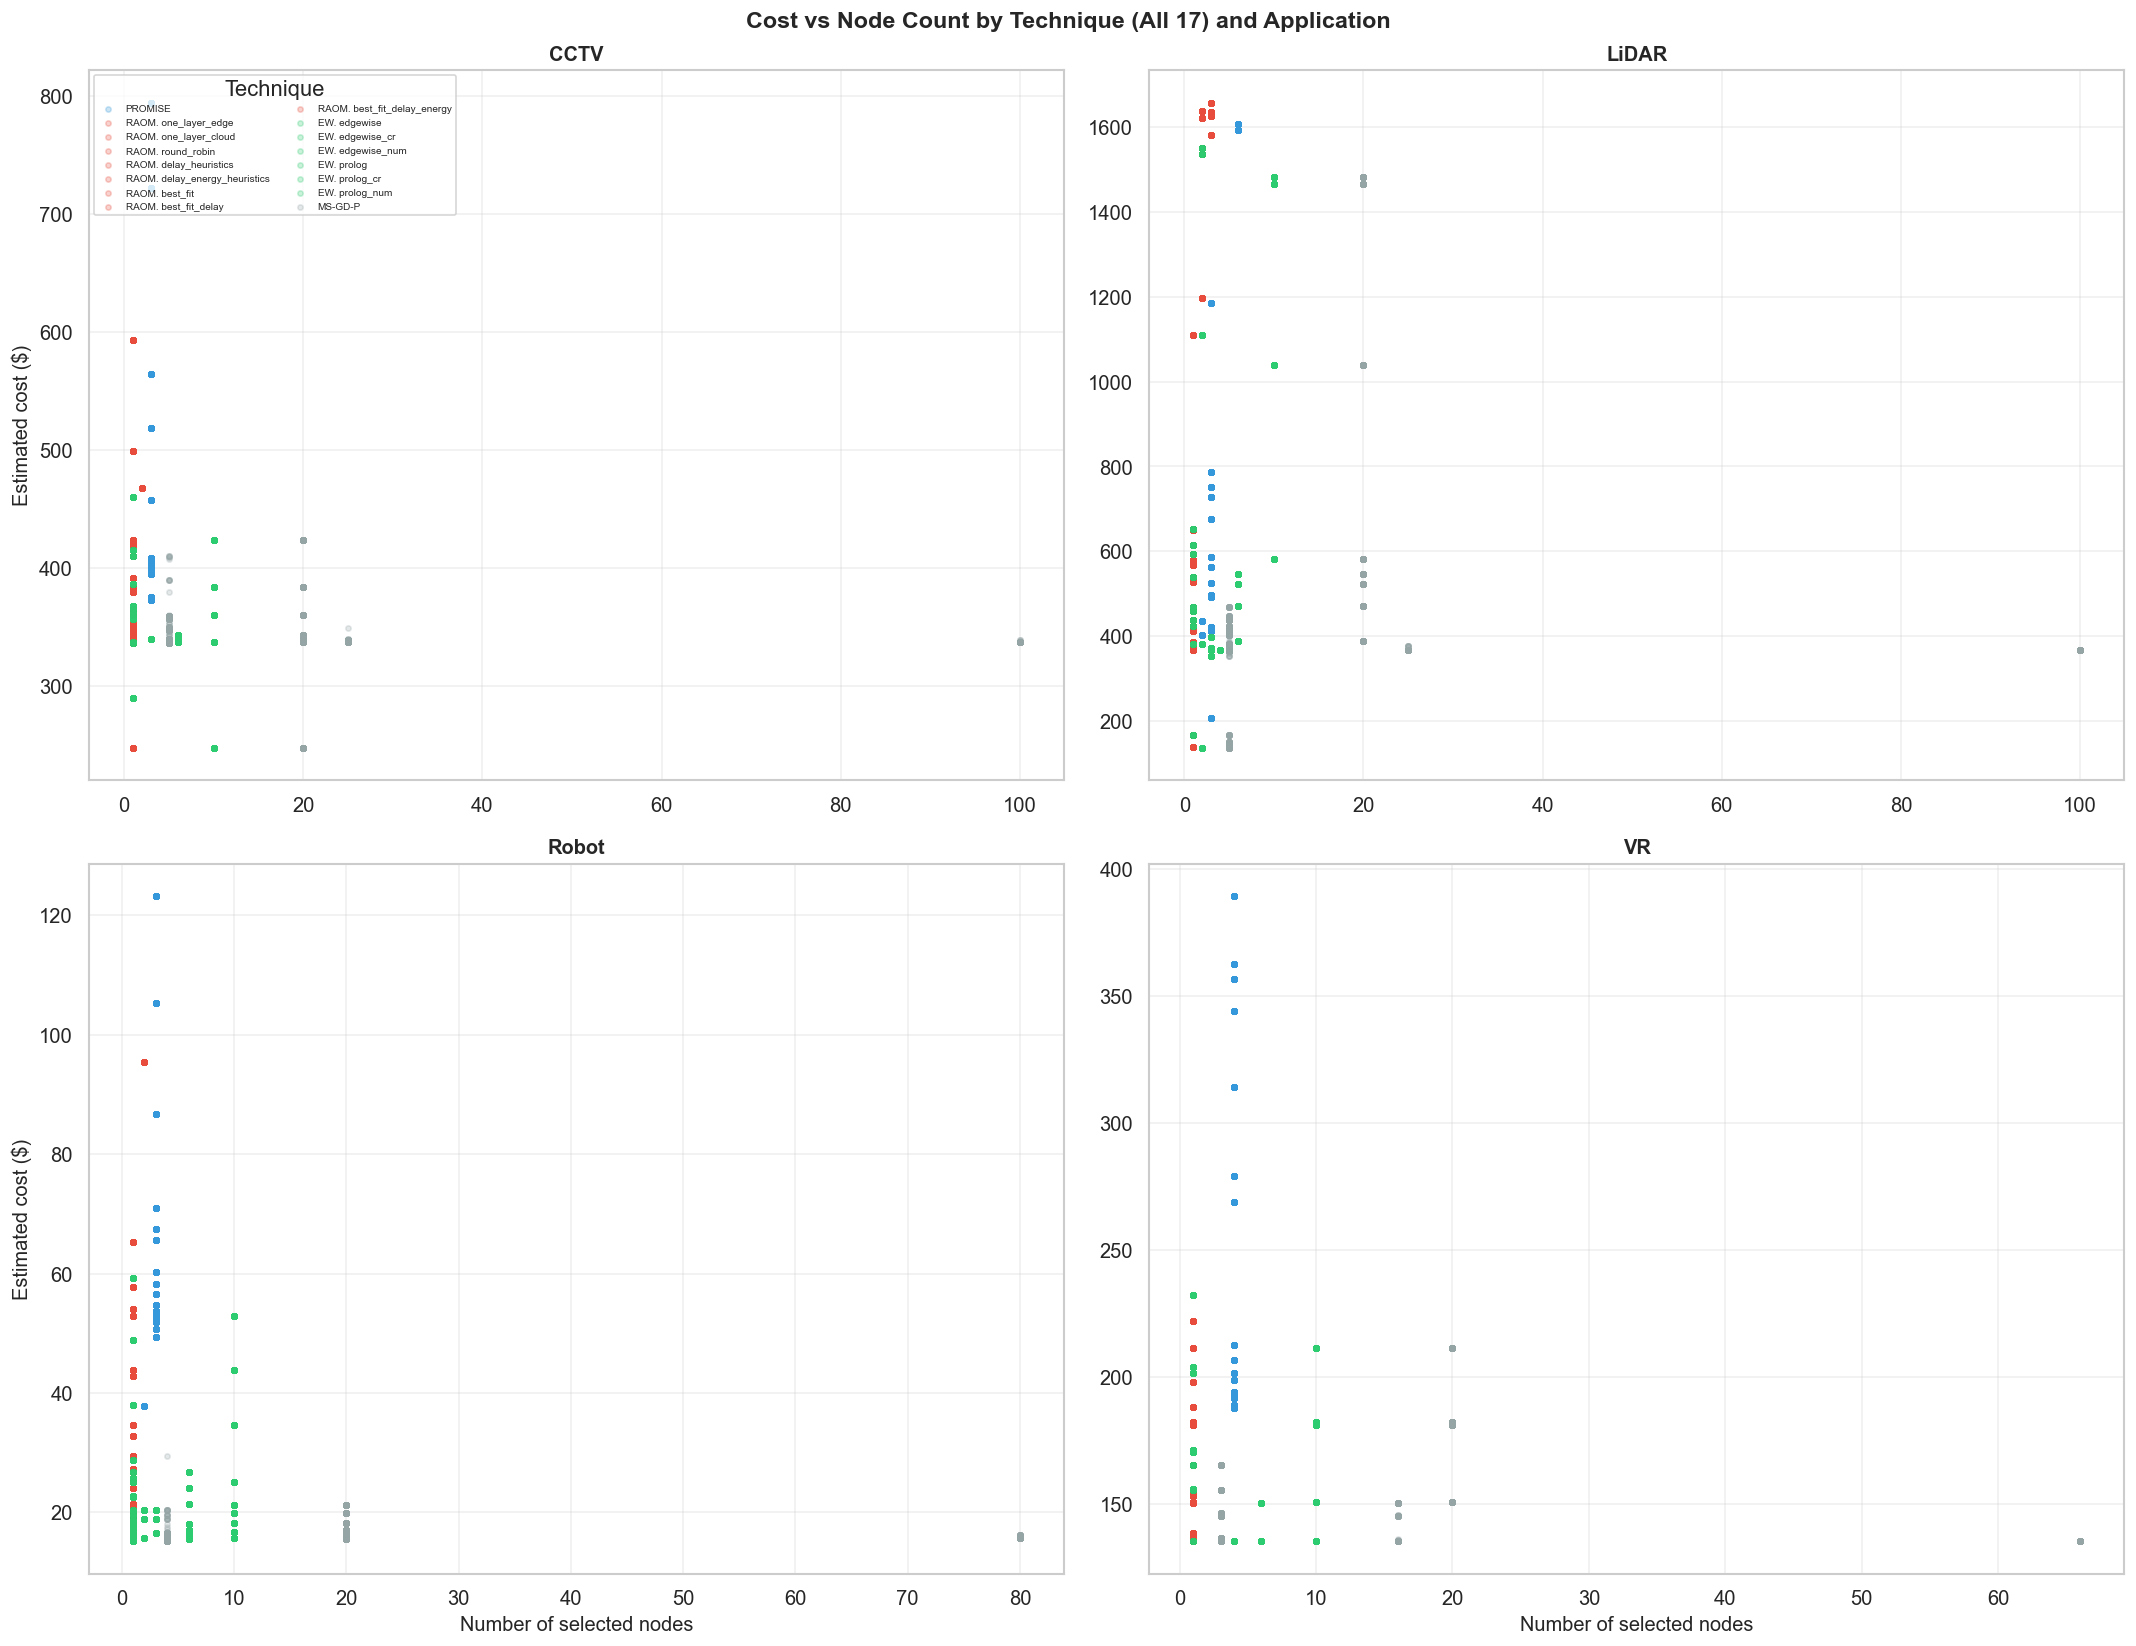

In [64]:
# Ungrouped cost vs node count - all 17 techniques
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, app in zip(axes.flat, APP_ORDER):
    sub = cost_df_ungrouped[cost_df_ungrouped['app'] == app]
    for tech in sub['technique'].unique():
        tsub = sub[sub['technique'] == tech]
        if len(tsub) == 0:
            continue
        ax.scatter(tsub['nodes'], tsub['cost'], c=tech_color(tech), alpha=0.25, s=10, label=short_tech(tech))
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Number of selected nodes', fontsize=12)
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Estimated cost ($)', fontsize=12)
    if ax == axes[0, 0]:
        ax.legend(title='Technique', fontsize=6, loc='upper left', ncol=2)
fig.suptitle('Cost vs Node Count by Technique (All 17) and Application',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ungrouped_cost_vs_nodes_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

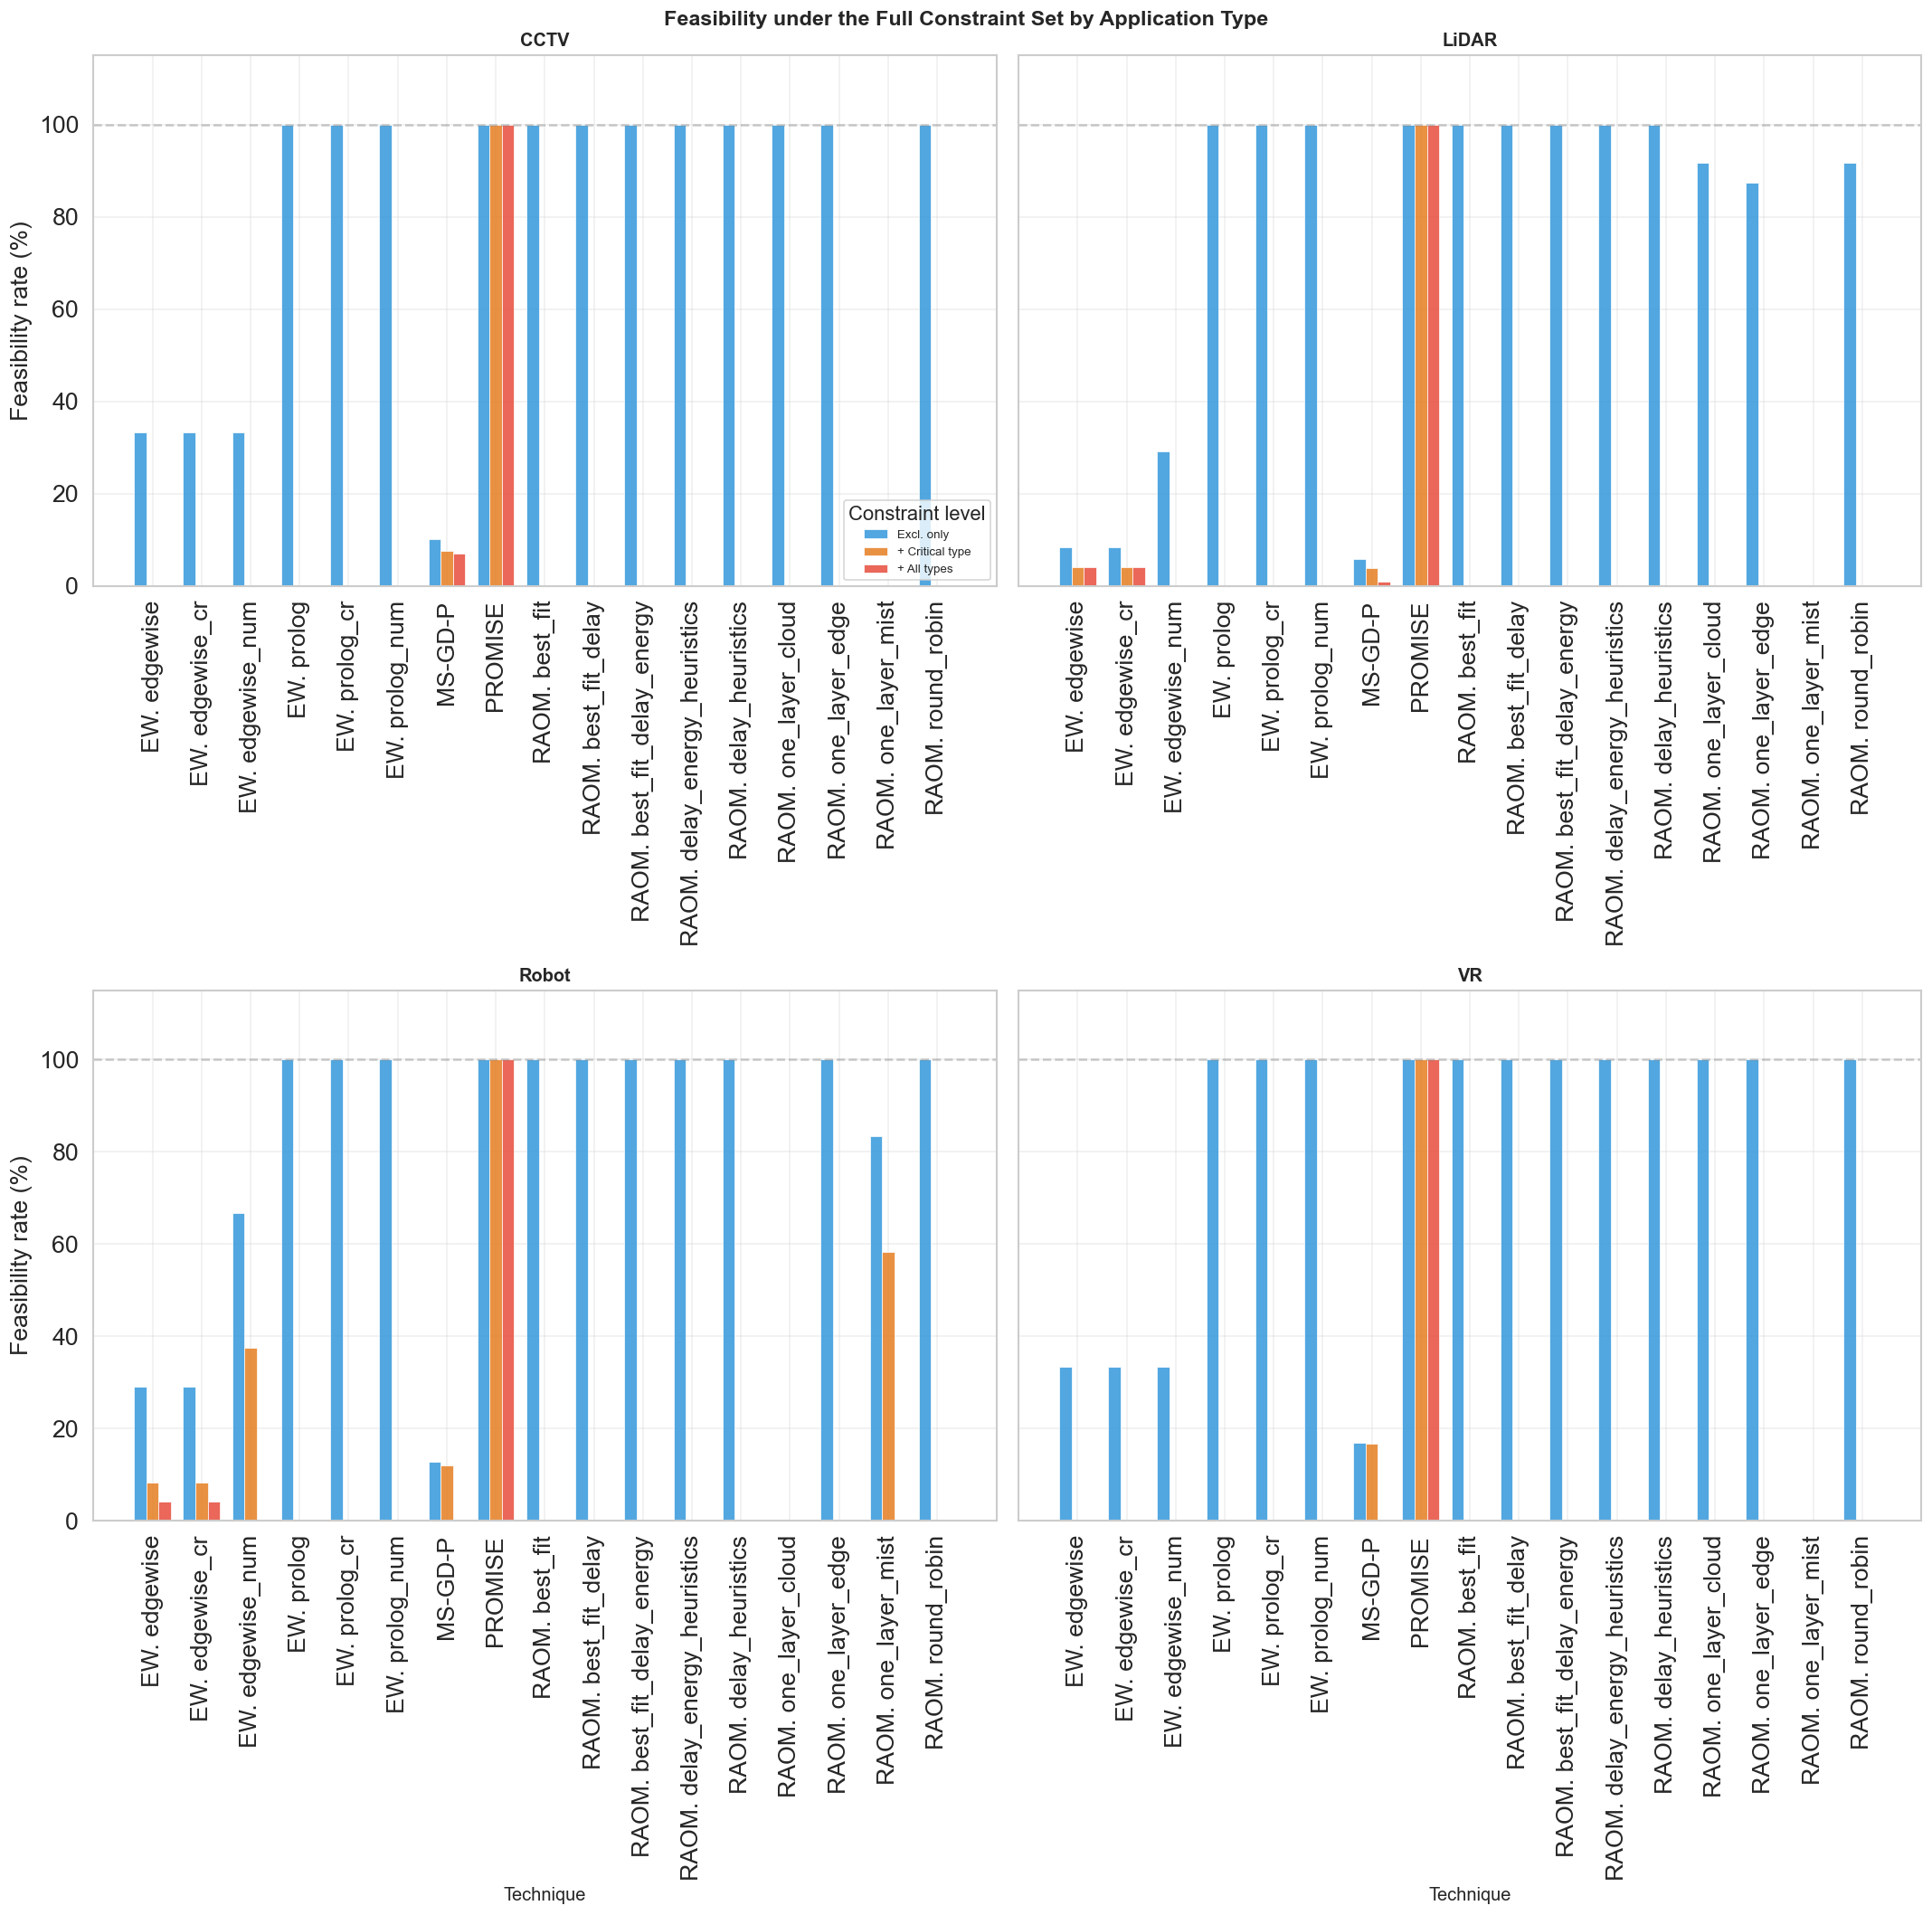

In [65]:
# Ungrouped feasibility under true constraint set - faceted by application
constraint_levels = ['feas_excl', 'feas_crit', 'feas_all']
level_labels = ['Excl. only', '+ Critical type', '+ All types']
level_colors = ['#3498db', '#e67e22', '#e74c3c']

feas_true = all_re.groupby(['technique', 'app'])[constraint_levels].mean() * 100
feas_true = feas_true.reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 18), sharey=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feas_true[feas_true['app'] == app].set_index('technique').sort_index()
    techniques = sub.index.tolist()
    x = np.arange(len(techniques))
    width = 0.25
    for i, (level, label, color) in enumerate(zip(constraint_levels, level_labels, level_colors)):
        vals = sub[level].values
        ax.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x + width)
    ax.set_xticklabels([short_tech(t) for t in techniques], rotation=90, fontsize=16)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    ax.set_ylim(0, 115)
    ax.axhline(100, color='grey', ls='--', alpha=0.4)
    ax.tick_params(axis='y', labelsize=16)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Technique', fontsize=12)
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Feasibility rate (%)', fontsize=16)
    if ax == axes[0, 0]:
        ax.legend(title='Constraint level', fontsize=8, loc='lower right')
fig.suptitle('Feasibility under the Full Constraint Set by Application Type',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/ungrouped_feasibility_true_faceted.png', dpi=150, bbox_inches='tight')
plt.show()